# Adversarial examples - Blind spot in representation spaces
### Author: Pietro Gori

As for all TP, answer all questions and fill the code where you see **XXXXXXXXX**

**Deadline**: please verify on the Moodle/Ecampus/web site the deadline

In [5]:
import numpy as np
import random

# pytorch libraries
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import DataLoader,Dataset, TensorDataset

# torchvision
from torchvision import models,transforms
import torchvision.datasets as Data

import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
%matplotlib inline

import time




import itertools

import pandas as pd

In this practical session, you will produce adversarial examples using two strategies to analyse the quality and smoothness of a representation space. We will use the Mnist dataset and a simple network (with 97% accuracy on test though...) so that you can train and test on your own laptop. Same conclusions can be drawn by using larger architectures and more complex datasets (You can try if you want).

Let's start with the first method. Please read first the article [1], in particular from Sectioon 4. 

`[1] Szegedy, Christian, Zaremba, Wojciech, Sutskever, Ilya, Bruna, Joan, Erhan, Dumitru, Goodfellow, Ian J.,
and Fergus, Rob. Intriguing properties of neural networks. ICLR, 2014`

We first check if you are using a computer with GPU, CUDA (Nvidia) or MPS (MacBook), or only CPU. 

In [6]:
print("Using torch", torch.__version__)

if torch.backends.mps.is_available():
    device = torch.device("mps")
    x = torch.ones(1, device=device)
    print(x)    
    print ("MPS (MacBook) device found.")
    print('Number of MPS cards: ', torch.mps.device_count())
    print('Total MPS memory {0:.2f} GB'.format(torch.mps.recommended_max_memory()/pow(10,9)))
elif torch.backends.cuda.is_built():
    device = torch.device("cuda")
    x = torch.ones(1, device=device)
    print(x) 
    print ("CUDA device found.")
    print('Number of GPU cards: ', torch.cuda.device_count(), '\nWhich card GPU?', torch.cuda.get_device_name(0))
    print('Total GPU memory {1:.2f} GB. Free GPU memory {0:.2f} GB'.format(torch.cuda.mem_get_info()[0]/pow(10,9),torch.cuda.mem_get_info()[1]/pow(10,9)))
else:
   device = torch.device("cpu")
   x = torch.ones(1, device=device)
   print(x) 
   print('No MPS or CUDA has been found. PyTorch will use CPU.')

Using torch 2.5.1+cu121
tensor([1.], device='cuda:0')
CUDA device found.
Number of GPU cards:  1 
Which card GPU? Tesla P100-PCIE-16GB
Total GPU memory 17.06 GB. Free GPU memory 16.76 GB


Here we fix the different seeds to make your algorithm reproducible and we set the hyper-parameters for the classification model we are going to train. You can modify them if you want, but I suggest you keep them like that for now and modify them only AFTER having trained for a first time the model. 

In [99]:
# to make the results reproducible
np.random.seed(10)
torch.manual_seed(10)
torch.cuda.manual_seed(10)
torch.mps.manual_seed(10)
random.seed(10)


# Parameters for training model
weight_decay = 1e-05
num_epochs = 10
batch_size=256 # adapted to the Google Colab GPU
learning_rate=0.001
loss_model=nn.CrossEntropyLoss()

We will use the MNIST dataset. Download it from torchvision.

In [8]:
mnist_train = Data.MNIST(root='data/',
                            train=True,
                            transform=transforms.ToTensor(),
                            download=False)

train_loader  = DataLoader(dataset=mnist_train,
                                          batch_size=batch_size,
                                          shuffle=True)

mnist_test = Data.MNIST(root='data/',
                          train=False,
                          transform=transforms.ToTensor(),
                          download=False)

test_loader  = DataLoader(dataset=mnist_test,
                                          batch_size=10000,
                                          shuffle=False)

We analyse the data to check the number of samples and their size.

In [9]:
# Print infomration
print("There are ", len (mnist_train), "training images and ", len(mnist_test), "test images")
image_size=list(mnist_train[0][0].squeeze().shape)
print(f"Each image is of shape: {image_size}")  # [28, 28]


There are  60000 training images and  10000 test images
Each image is of shape: [28, 28]


Here we code the model proposed in the article. 

**Question**: complete the code so that you can create *A simple fully connected network with one or more hidden layers and a Softmax classifier. We refer to this network as “FC”*. Please code it so that the input_size of the model (i.e. size of the input images), the number and size of hidden layers (e.g., [100,100]) and the output size (i.e., number of possible classes) are parameters of the model. 

In [260]:
class FullyConnectedNet(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size):

        super(FullyConnectedNet, self).__init__()
        
        # Create a list to store all layer sizes (input, hidden, output)
        layer_sizes = [input_size] + hidden_sizes + [output_size]
        
        # Create the layers dynamically
        layers = []
        for i in range(len(layer_sizes) - 1):
            # Add linear layer
            layers.append(nn.Linear(layer_sizes[i], layer_sizes[i + 1]))
            
            # Add ReLU activation for all but the last layer
            if i < len(layer_sizes) - 2:
                layers.append(nn.ReLU())
        
        # Combine all layers into a sequential model
        self.layers = nn.Sequential(*layers)
        
  
    
    def forward(self, x):

        # Flatten the input if it's not already flat
        x = x.view(x.size(0), -1)
        
        # Forward pass through the layers
        x = self.layers(x)
        
        
        
        return x

**Question**: Create one of the model proposed in the article.

In [264]:
input_size = 28*28
hidden_sizes = [100,100]
output_size = 10

# Model
model = FullyConnectedNet(input_size, hidden_sizes, output_size).to(device)
# Optimizer
optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Print the model
print(model)

FullyConnectedNet(
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=200, bias=True)
    (1): ReLU()
    (2): Linear(in_features=200, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=10, bias=True)
  )
)


Here we code the training procedure, as commonly done with Pytorch. Please note that we use the Adam optimizer.

In [265]:
def training(model, train_loader, optimizer, num_epochs, loss_model):
  for epoch in range(num_epochs):
    model.train()
    for i, (images, labels) in enumerate(train_loader):

        # Put images to GPU
        X = images.to(device)
        Y = labels.to(device)

        # Forward pass
        outputs = model(X)
        # print(outputs.shape)
        loss = loss_model(outputs, Y)

        # Backward and optimize
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        if (i + 1) % 100 == 0:
            print(f'Epoch [{epoch+1}/{num_epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}')

And we evaluate it.

In [266]:
def evaluation(model, test_loader):
  model.eval()

  correct = 0
  total = 0

  for images, labels in test_loader:

      X  = images.to(device)
      Y  = labels.to(device)

      outputs = model(X) # array of size [num test images, num classes]

      predicted_class = torch.argmax(outputs.data, dim=1) # faster

      total += len(Y)
      correct += (predicted_class == Y).sum()

  print('Accuracy of test images: %f %%' % (100 * float(correct) / total))

In [267]:
# Training loop
training(model, train_loader, optimizer, num_epochs, loss_model)

Epoch [1/10], Step [100/235], Loss: 0.4186
Epoch [1/10], Step [200/235], Loss: 0.3346
Epoch [2/10], Step [100/235], Loss: 0.1999
Epoch [2/10], Step [200/235], Loss: 0.1692
Epoch [3/10], Step [100/235], Loss: 0.1335
Epoch [3/10], Step [200/235], Loss: 0.1759
Epoch [4/10], Step [100/235], Loss: 0.0834
Epoch [4/10], Step [200/235], Loss: 0.1015
Epoch [5/10], Step [100/235], Loss: 0.1132
Epoch [5/10], Step [200/235], Loss: 0.0623
Epoch [6/10], Step [100/235], Loss: 0.1050
Epoch [6/10], Step [200/235], Loss: 0.0703
Epoch [7/10], Step [100/235], Loss: 0.0346
Epoch [7/10], Step [200/235], Loss: 0.0478
Epoch [8/10], Step [100/235], Loss: 0.0517
Epoch [8/10], Step [200/235], Loss: 0.0465
Epoch [9/10], Step [100/235], Loss: 0.0368
Epoch [9/10], Step [200/235], Loss: 0.0155
Epoch [10/10], Step [100/235], Loss: 0.0149
Epoch [10/10], Step [200/235], Loss: 0.0309


In [268]:
evaluation(model, test_loader)

Accuracy of test images: 97.570000 %


**Question**: Is the performance good ? Test different architectures (number and size of hidden layers). You can also try different hyper-parameters (weight decay, number of epochs, etc.). Use the "Occam's razor principle" to choose and justify your final model. 


In [248]:
def test_architectures(train_loader, test_loader, device, architectures, hyperparams):
    best_model = None
    best_accuracy = 0
    best_config = None

    results = []

    for arch, hp in itertools.product(architectures, hyperparams):
        input_size, hidden_sizes, output_size = arch
        learning_rate, weight_decay, num_epochs = hp

        # Define model
        model = FullyConnectedNet(input_size, hidden_sizes, output_size).to(device)

        # Define optimizer and loss function
        optimizer = optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)
        loss_model = nn.CrossEntropyLoss()

        # Training
        for epoch in range(num_epochs):
            model.train()
            for images, labels in train_loader:
                X = images.to(device)
                Y = labels.to(device)

                outputs = model(X)
                loss = loss_model(outputs, Y)

                optimizer.zero_grad()
                loss.backward()
                optimizer.step()

        # Evaluation
        model.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for images, labels in test_loader:
                X = images.to(device)
                Y = labels.to(device)

                outputs = model(X)
                predicted_class = torch.argmax(outputs, dim=1)

                total += len(Y)
                correct += (predicted_class == Y).sum().item()

        accuracy = 100 * correct / total
        results.append((arch, hp, accuracy))

        print(f"Architecture: {arch}, Hyperparameters: {hp}, Accuracy: {accuracy:.2f}%")

        # Update best model if accuracy improves
        if accuracy > best_accuracy:
            best_model = model
            best_accuracy = accuracy
            best_config = (arch, hp)

    # Print summary
    print("\nBest Configuration:")
    print(f"Architecture: {best_config[0]}, Hyperparameters: {best_config[1]}, Accuracy: {best_accuracy:.2f}%")
    
    return best_model, best_accuracy, best_config, results

# Define architectures and hyperparameters to test
architectures = [
    (28*28, [50], 10),
    (28*28, [100], 10),
    (28*28, [100, 50], 10),
    (28*28, [100, 100], 10),
    (28*28, [200, 100], 10)
]

hyperparams = [
    (0.001, 1e-4, 5),  # (learning_rate, weight_decay, num_epochs)
    (0.001, 1e-5, 10),
    (0.0005, 1e-4, 10),
    
]

# Run the tests
best_model, best_accuracy, best_config, results = test_architectures(
    train_loader, test_loader, device, architectures, hyperparams
)


df_results = pd.DataFrame(results, columns=["Architecture", "Hyperparameters", "Accuracy"])
df_results.to_csv("architecture_results.csv", index=False)


Architecture: (784, [50], 10), Hyperparameters: (0.001, 0.0001, 5), Accuracy: 94.79%
Architecture: (784, [50], 10), Hyperparameters: (0.001, 1e-05, 10), Accuracy: 96.23%
Architecture: (784, [50], 10), Hyperparameters: (0.0005, 0.0001, 10), Accuracy: 95.15%
Architecture: (784, [100], 10), Hyperparameters: (0.001, 0.0001, 5), Accuracy: 96.16%
Architecture: (784, [100], 10), Hyperparameters: (0.001, 1e-05, 10), Accuracy: 97.26%
Architecture: (784, [100], 10), Hyperparameters: (0.0005, 0.0001, 10), Accuracy: 96.41%
Architecture: (784, [100, 50], 10), Hyperparameters: (0.001, 0.0001, 5), Accuracy: 96.49%
Architecture: (784, [100, 50], 10), Hyperparameters: (0.001, 1e-05, 10), Accuracy: 97.35%
Architecture: (784, [100, 50], 10), Hyperparameters: (0.0005, 0.0001, 10), Accuracy: 96.35%
Architecture: (784, [100, 100], 10), Hyperparameters: (0.001, 0.0001, 5), Accuracy: 96.85%
Architecture: (784, [100, 100], 10), Hyperparameters: (0.001, 1e-05, 10), Accuracy: 97.35%
Architecture: (784, [100, 100

> the (784, [100, 50], 10) architecture offers an excellent trade-off between high performance (97.35% accuracy), manageable number of parameters, and reasonable training time. It’s likely to be more efficient in terms of both computational resources and time compared to the larger models.

Here, you will code the method proposed in Sec. 4.1 of [1]. I copy/paste it here:

We denote by $f : R^m \rightarrow {1 . . . k}$ a classifier mapping image pixel value vectors to a discrete label set. We also assume that $f$ has an associated continuous loss function denoted by $\text{loss}_f : R^m × {1 . . . k} \rightarrow R^+$. For a given $x \in R^m$ image and target label $l \in {1 . . . k}$, we aim to solve the following box-constrained optimization problem:

• Minimize $||r||_2$ subject to:
1. $f(x + r) = l$
2. $x + r \in [0, 1]^m$


The minimizer $r$ might not be unique, but we denote one such $x + r$ for an arbitrarily chosen minimizer by $D(x, l)$. Informally, $x + r$ is the closest image to $x$ classified as $l$ by $f$. Obviously, $D(x, f(x)) = f(x)$, so this task is non-trivial only if $f(x) \neq l$. In general, the exact computation
of $D(x, l)$ is a hard problem, so we approximate it by using a box-constrained L-BFGS. Concretely, we find an approximation of $D(x, l)$ by performing line-search to find the minimum $c > 0$ for which the minimizer $r$ of the following problem satisfies $f(x + r) = l$.

• Minimize $c|r| + \text{loss}_f (x + r, l)$ subject to $x + r \in [0, 1]^m$

This penalty function method would yield the exact solution for $D(X, l)$ in the case of convex losses, however neural networks are non-convex in general, so we end up with an approximation in this case.

We start by setting the hyper-parameters of the L-BFGS method. Keep them like that for now. You will come back later to change them.

In [244]:
# Parameters adversarial example
index=666 # index test image to use

max_iter_search=300
initial_c = 0.000001  # Initial value of c
max_c = 0.01  # Upper limit for c
mult_c = 1.03 # Multiplicative update of c at each iter c *= mult_c

epsilon_LBFGS = 1e-6  # Small value for line search stopping criterion
max_iter_LBFGS = 100  # Maximum iterations for L-BFGS
lr_LBFGS = 0.5  # Learning rate for L-BFGS

We can plot the chosen image

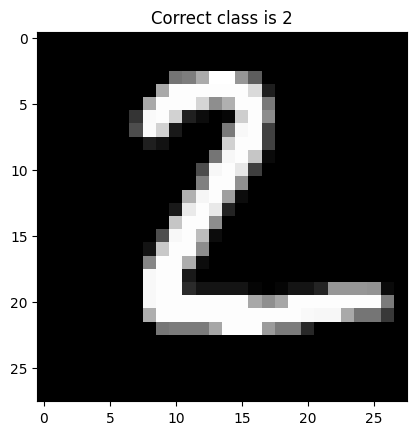

In [233]:
testI, testY = mnist_test.__getitem__(index)
fig = plt.imshow(testI.squeeze(), interpolation='nearest', cmap=plt.cm.gray)
plt.title(f"Correct class is {testY}")
plt.show()

I have written a code to plot the original image $x$, the modified image $x+r$ and the residual added $r$.

In [230]:
def plot_results(X, r, Xr, Y, l, fail=True):

    
    fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(25, 7))
    im1 = axes[0].imshow(X.squeeze().cpu().detach().numpy(), interpolation='nearest', cmap=plt.cm.gray)
    axes[0].set_title(f"Original Image. Correct class is {Y}",fontsize=22)

    im3=axes[2].imshow(r.squeeze().cpu().detach().numpy(), interpolation='nearest', cmap=plt.cm.gray)
    axes[2].set_title(f"Residual added",fontsize=22)

    if fail:
        im2=axes[1].imshow(Xr.squeeze().cpu().detach().numpy(), interpolation='nearest', cmap=plt.cm.gray)    
        axes[1].set_title(f"Modified Image, FAILED to predict class {l.item()}",fontsize=22)
    else:
        im2=axes[1].imshow(Xr.squeeze().cpu().detach().numpy(), interpolation='nearest', cmap=plt.cm.gray)    
        axes[1].set_title(f"Modified Image, PREDICTED class {l.item()}",fontsize=22)

    # Add a single colorbar for all subplots
    cbar = fig.colorbar(im3, ax=axes, orientation='vertical', fraction=0.02, pad=0.04)
    cbar.set_label('Intensity (0 to 1)')

    # Show the plots
    plt.show()

## L-BFGS

Here we will code the proposed method. Complete the code where you see `XXXXXXX`.

Please be advised that the `torch.optim.LBFGS` optimizer is designed to work with a `closure` for computing the loss and gradients multiple times during optimization, which is essential for second-order methods.

The closure is a callable function passed to LBFGS that recomputes the loss and its gradients multiple times during a single optimization step.
To work correctly, we need to call `optimizer.zero_grad()` to clear old gradients before calculating new ones.

Please note that SGD or Adam don't require a closure because they update the parameters based on the current gradient in a single step.

More info here: https://pytorch.org/docs/stable/optim.html

### Done on (784, [200, 100], 10) architecture

The true class is 2, the new class will be 0
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 1 iterations
Norm Perturbation |r|: 55.14925003051758


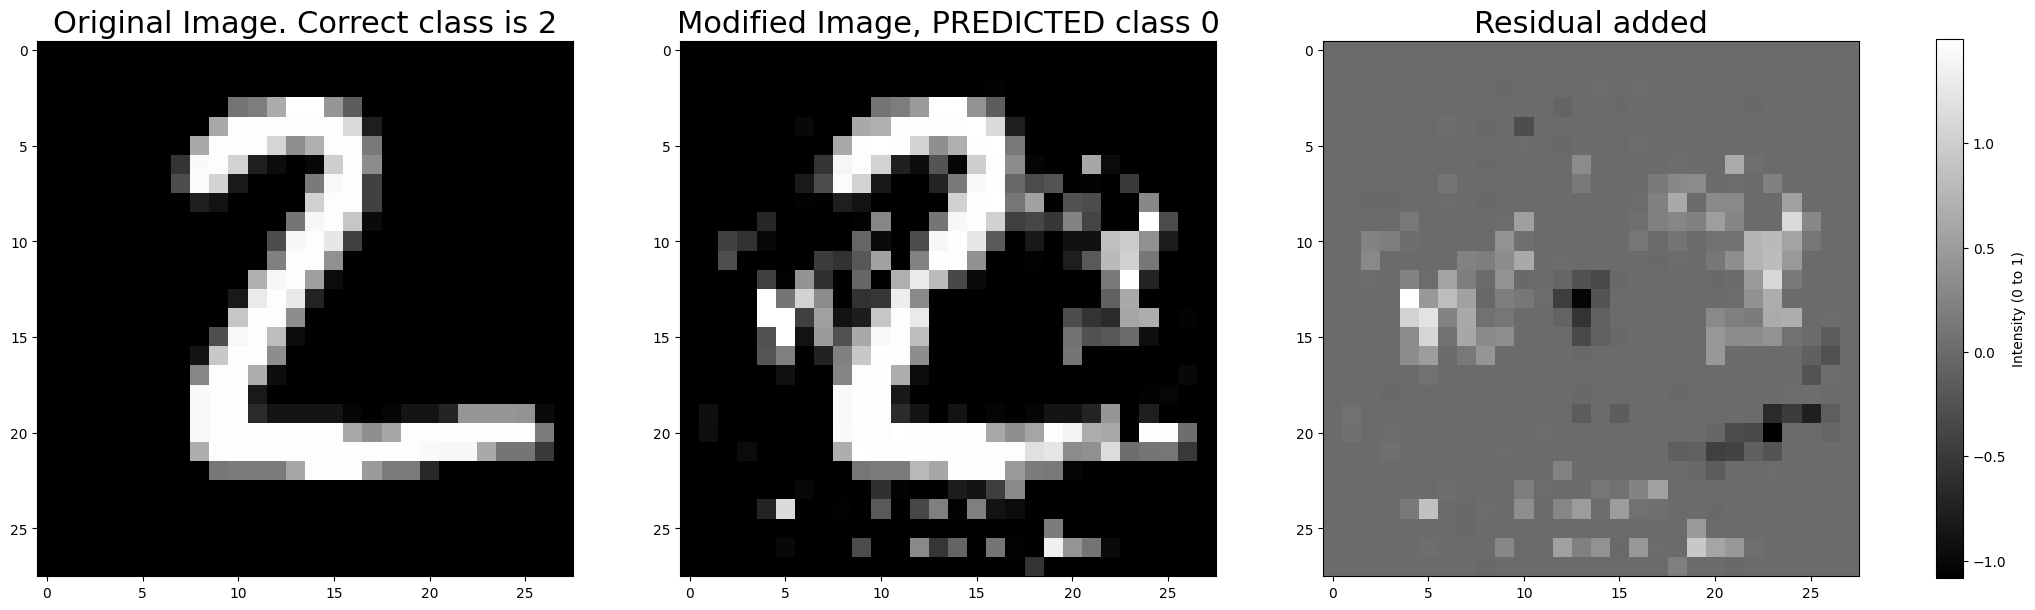

The true class is 2, the new class will be 1
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 1 iterations
Norm Perturbation |r|: 48.15448760986328


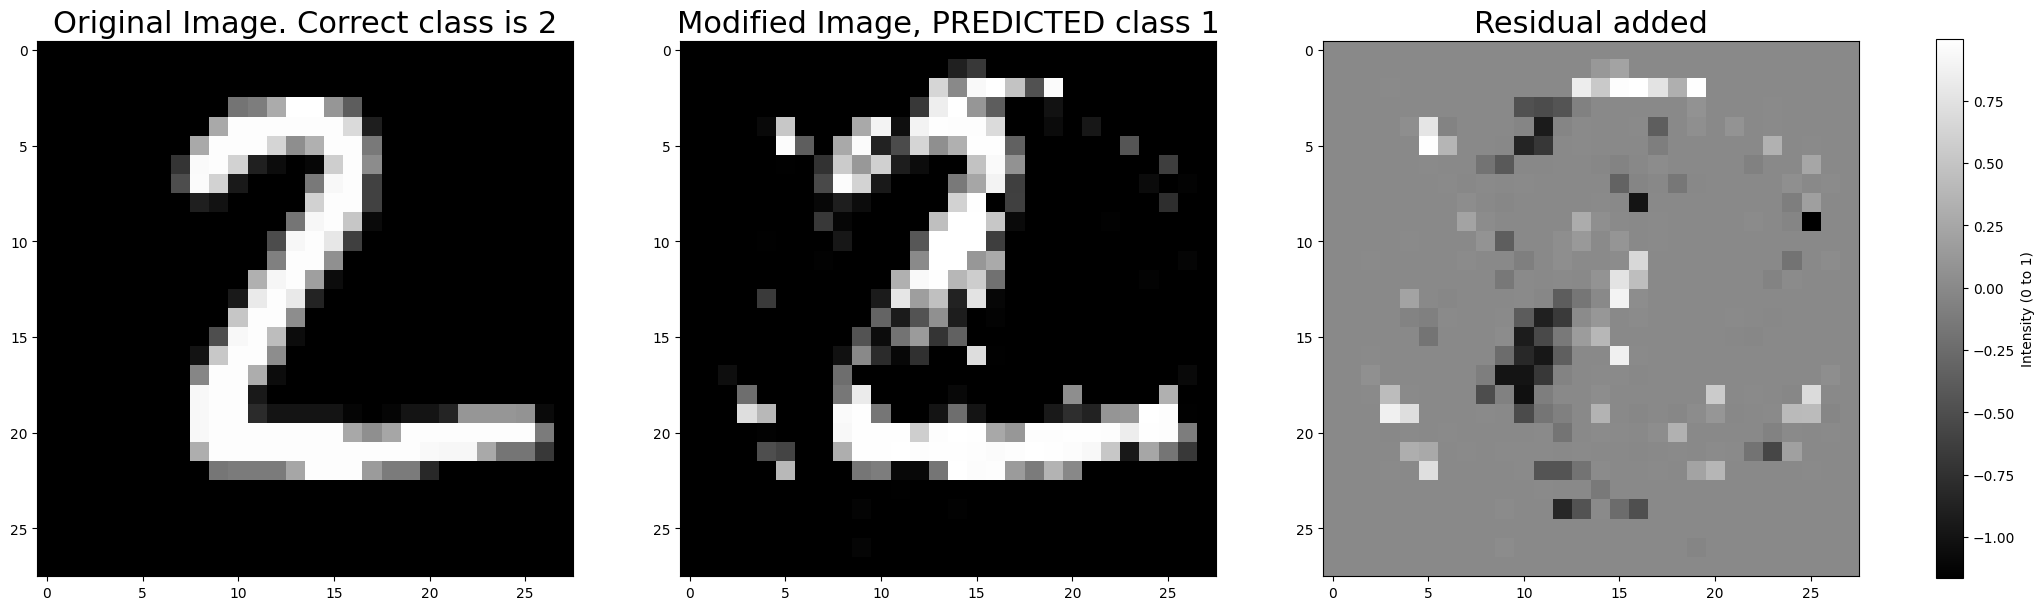

The true class is 2, the new class will be 2
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 1 iterations
Norm Perturbation |r|: 82.8830337524414


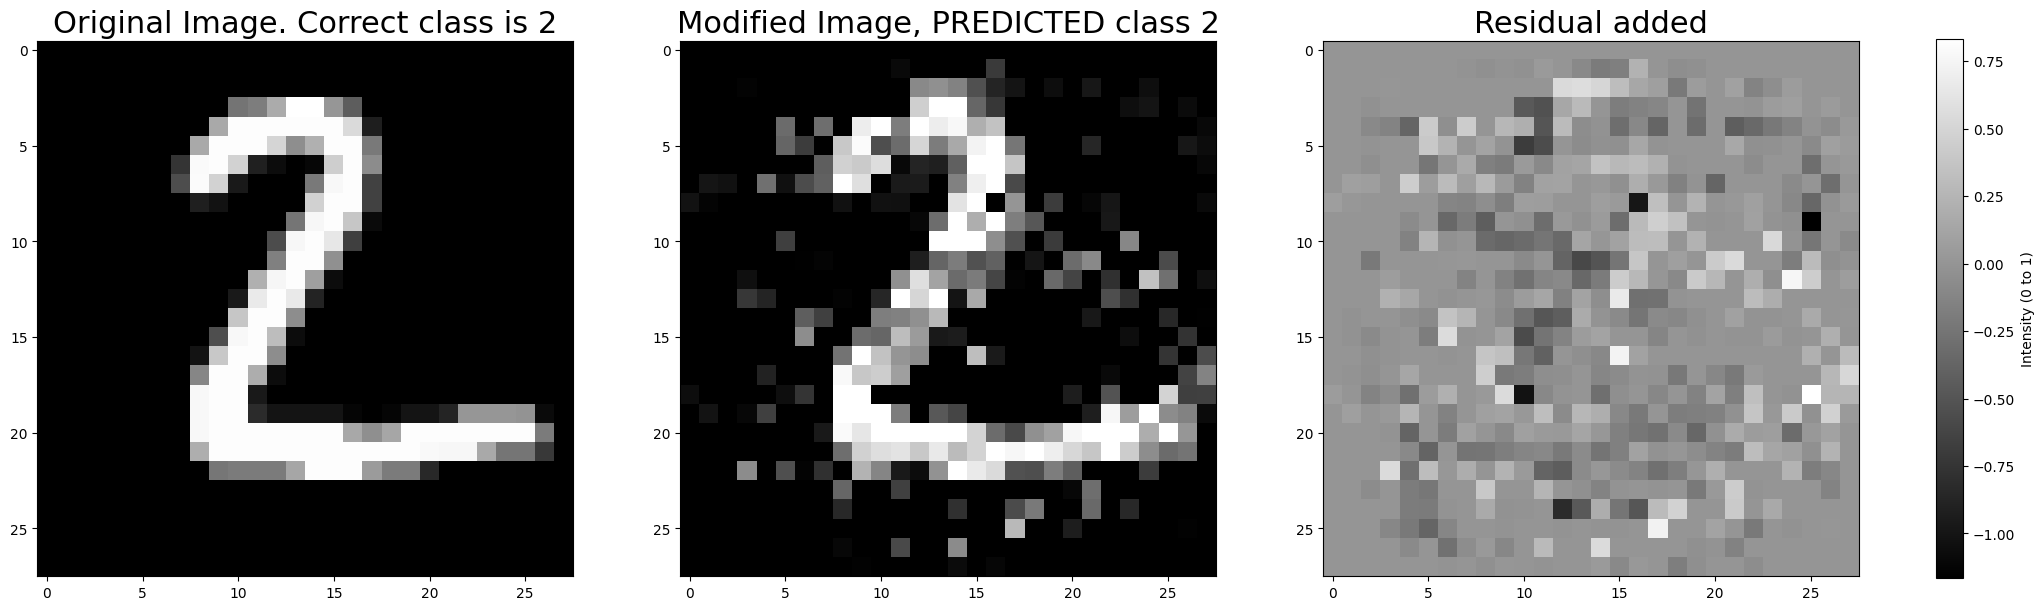

The true class is 2, the new class will be 3
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 1 iterations
Norm Perturbation |r|: 27.12564468383789


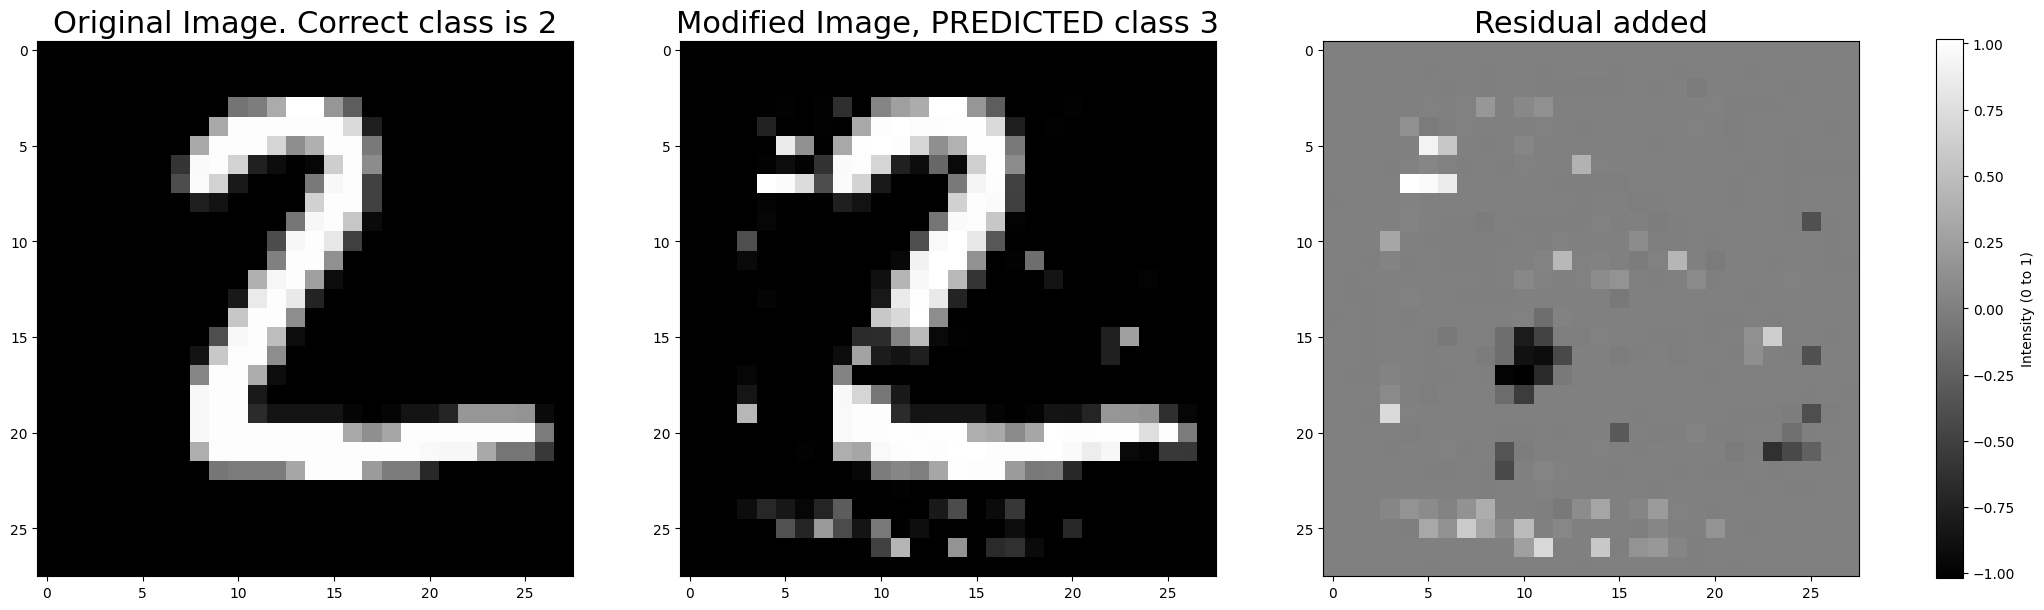

The true class is 2, the new class will be 4
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 1 iterations
Norm Perturbation |r|: 74.87081909179688


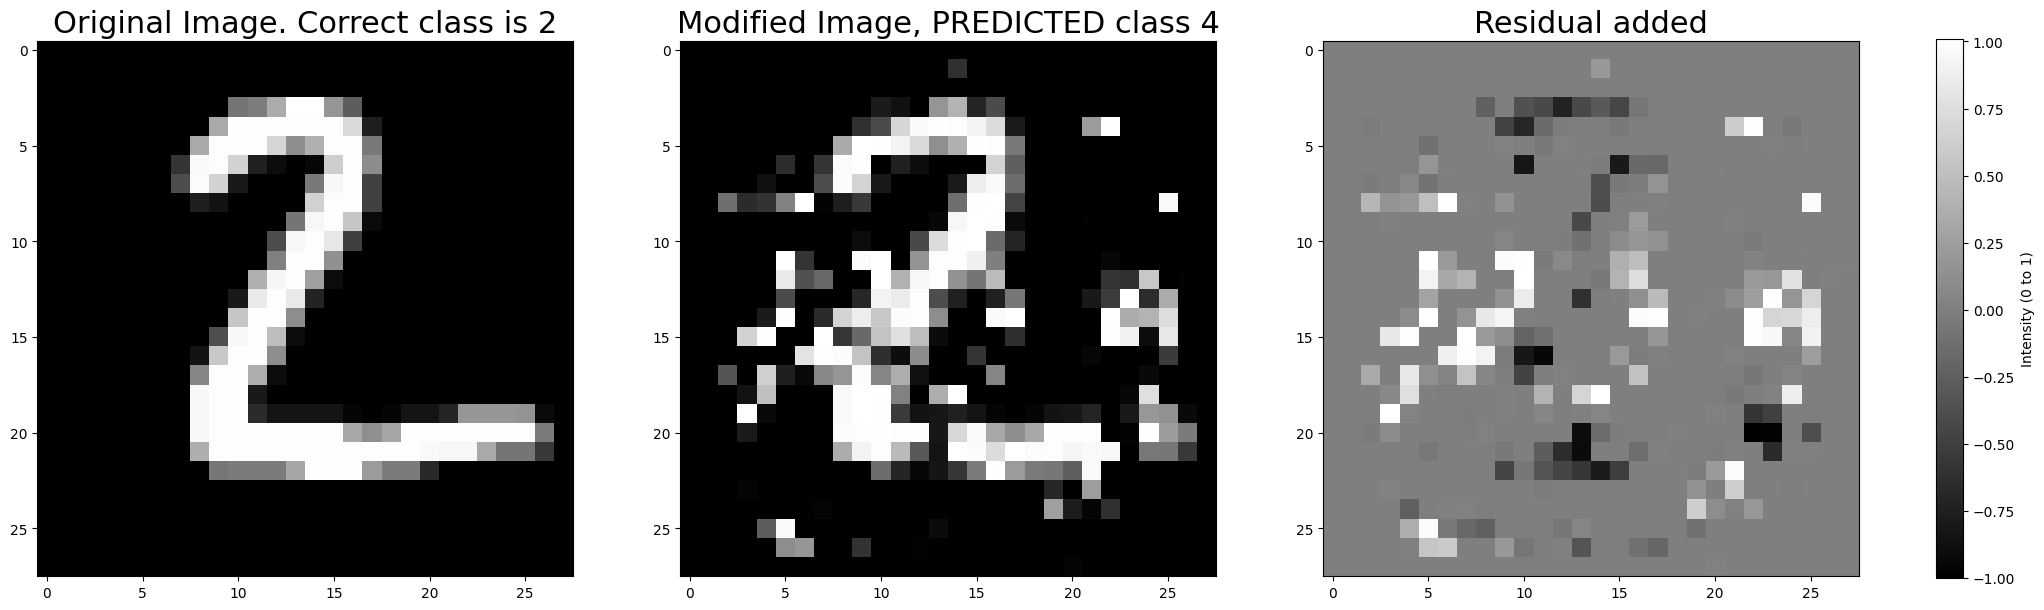

The true class is 2, the new class will be 5
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 1 iterations
Norm Perturbation |r|: 39.868080139160156


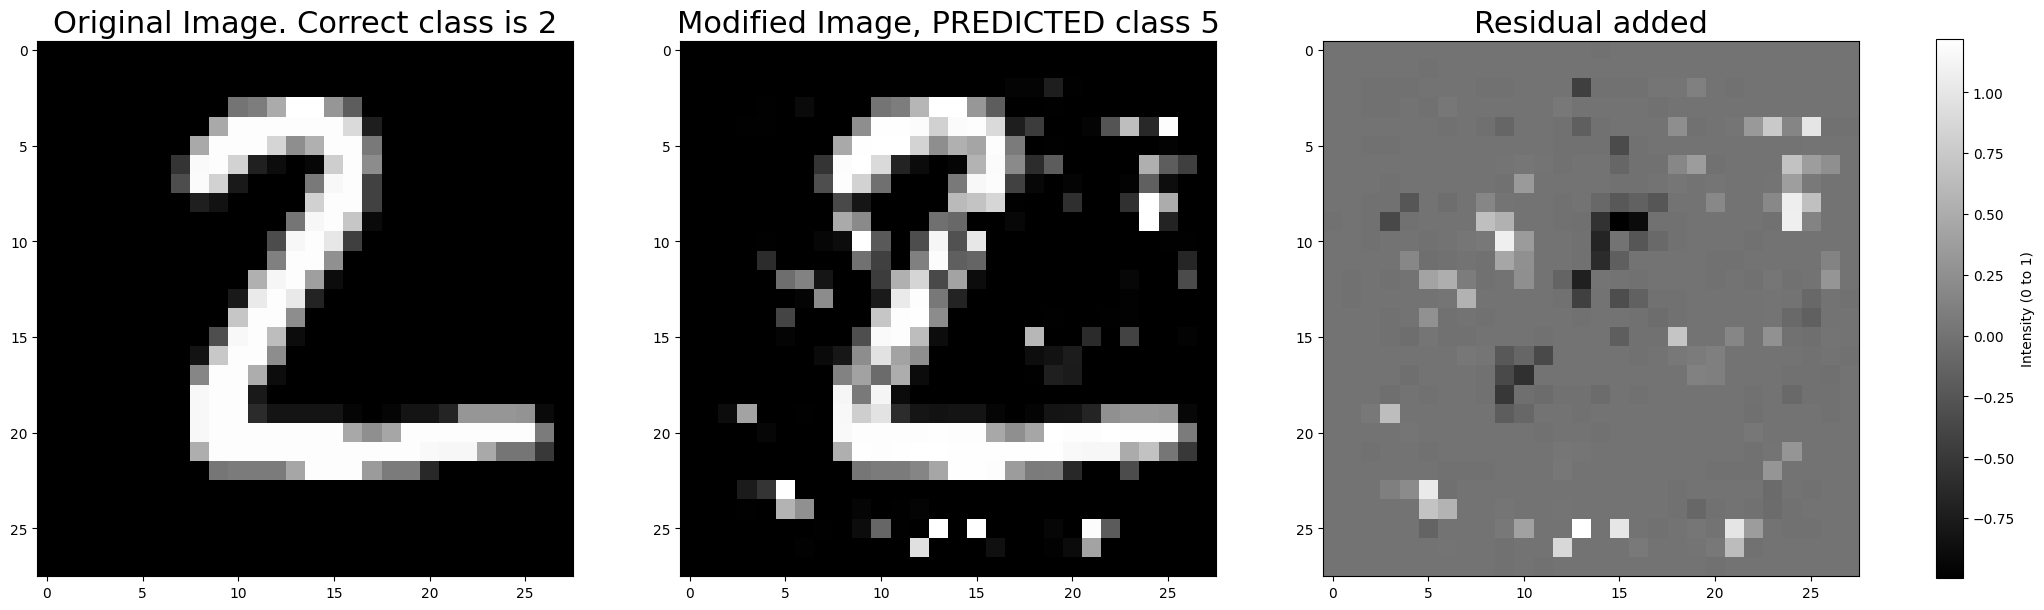

The true class is 2, the new class will be 6
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 1 iterations
Norm Perturbation |r|: 41.104400634765625


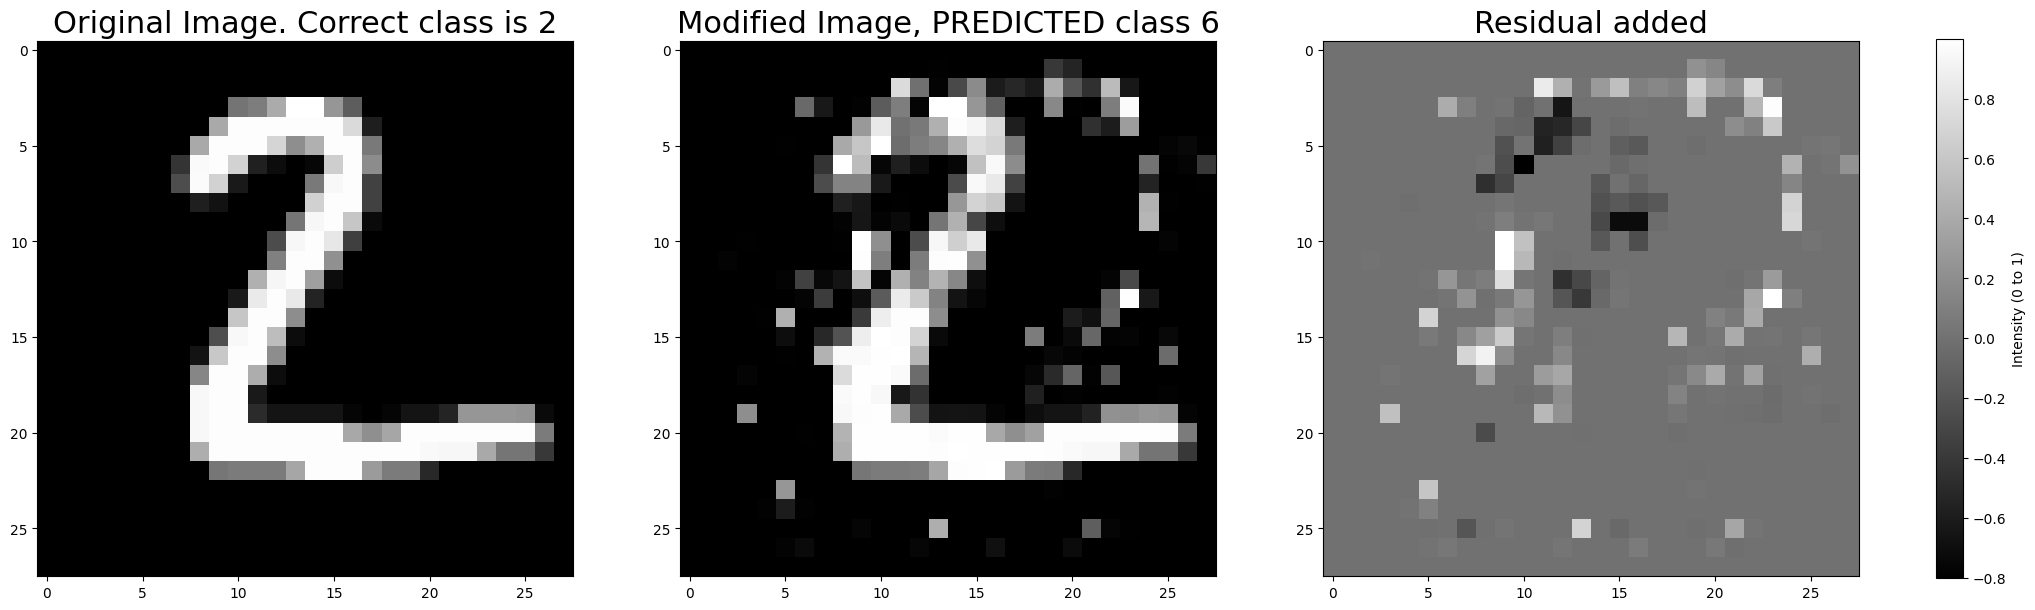

The true class is 2, the new class will be 7
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 1 iterations
Norm Perturbation |r|: 87.52986907958984


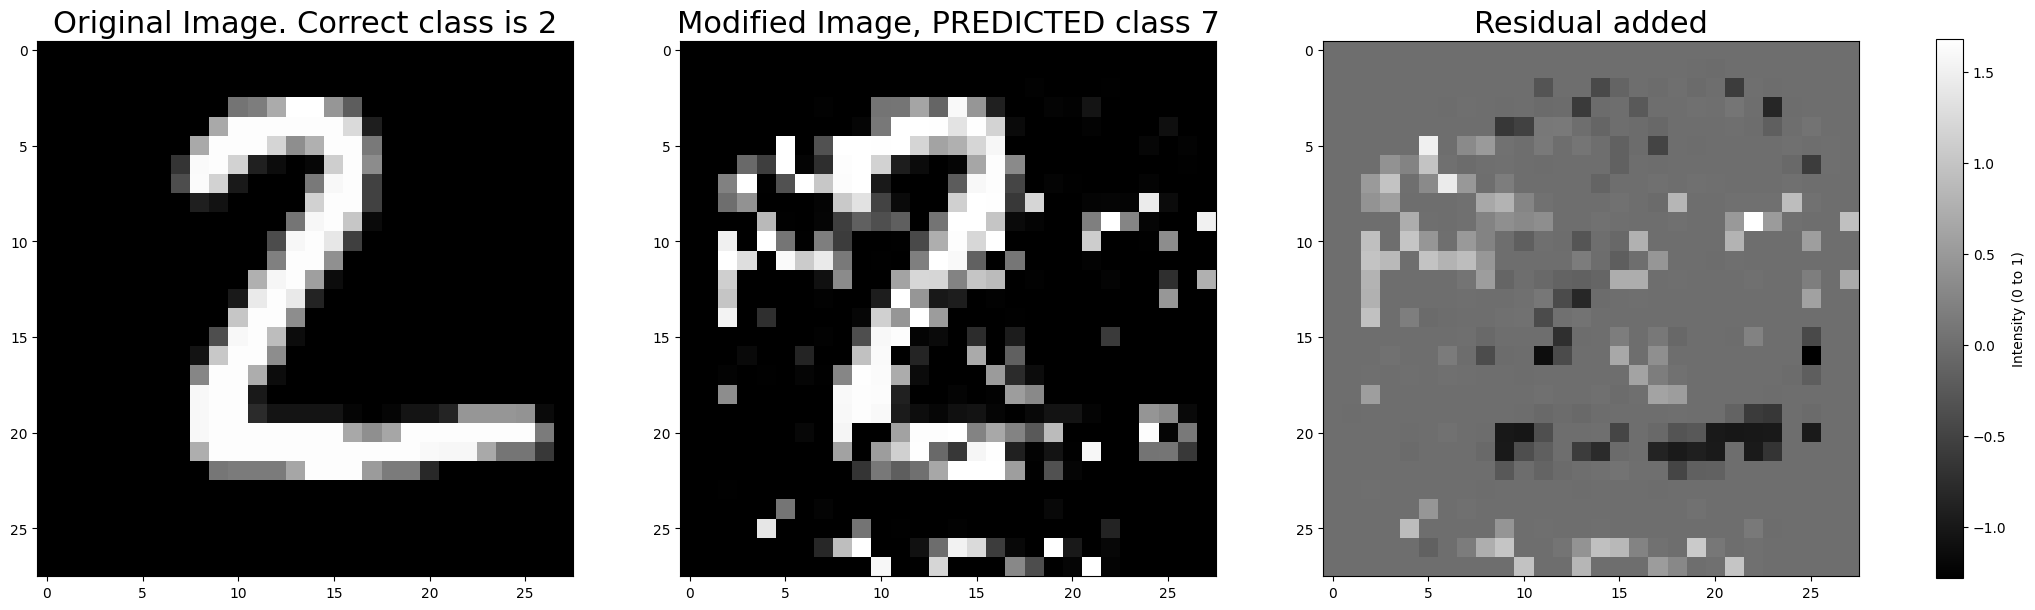

The true class is 2, the new class will be 8
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 1 iterations
Norm Perturbation |r|: 32.22309494018555


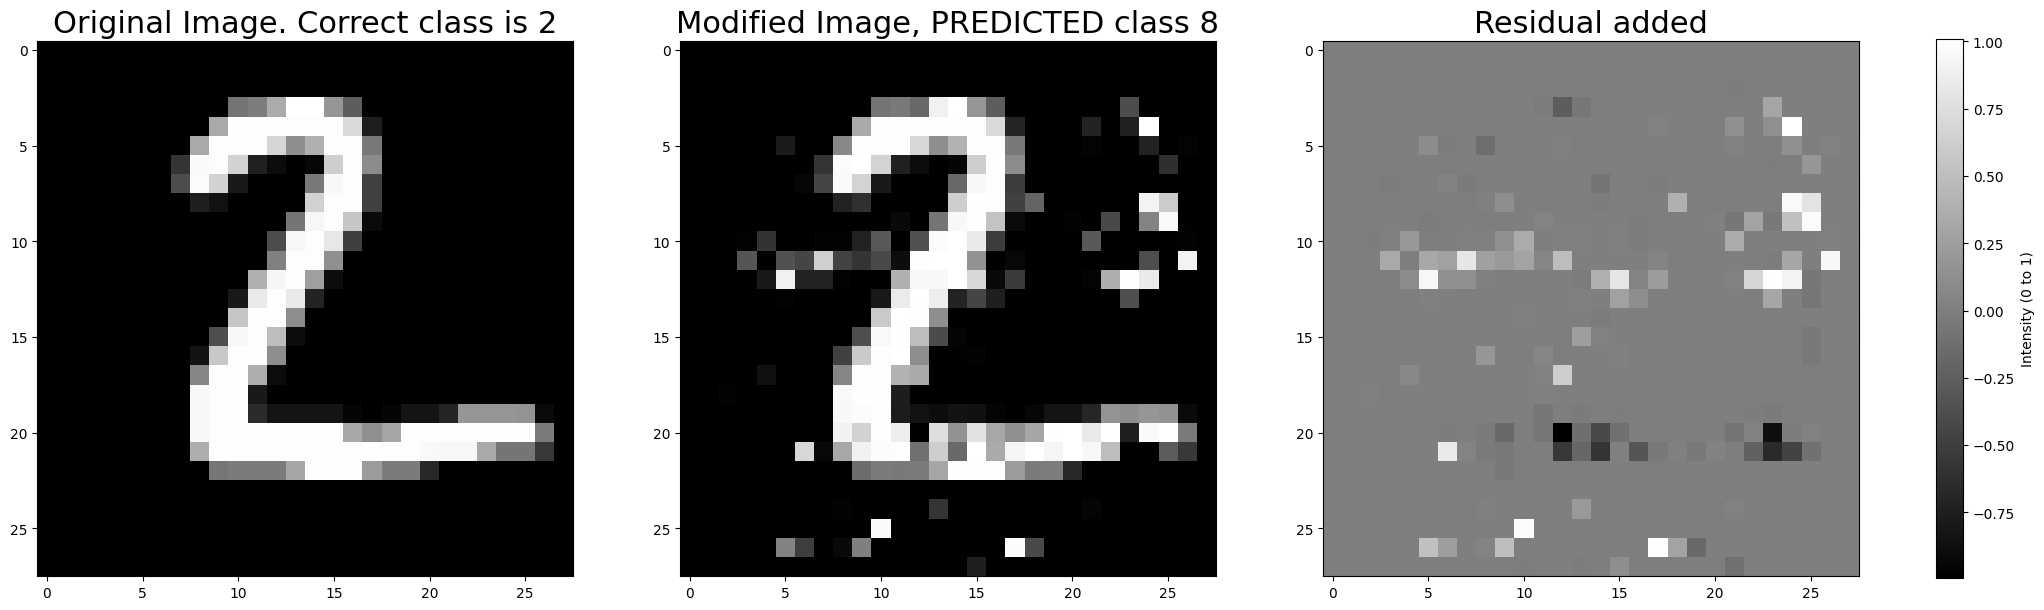

The true class is 2, the new class will be 9
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 1 iterations
Norm Perturbation |r|: 90.93860626220703


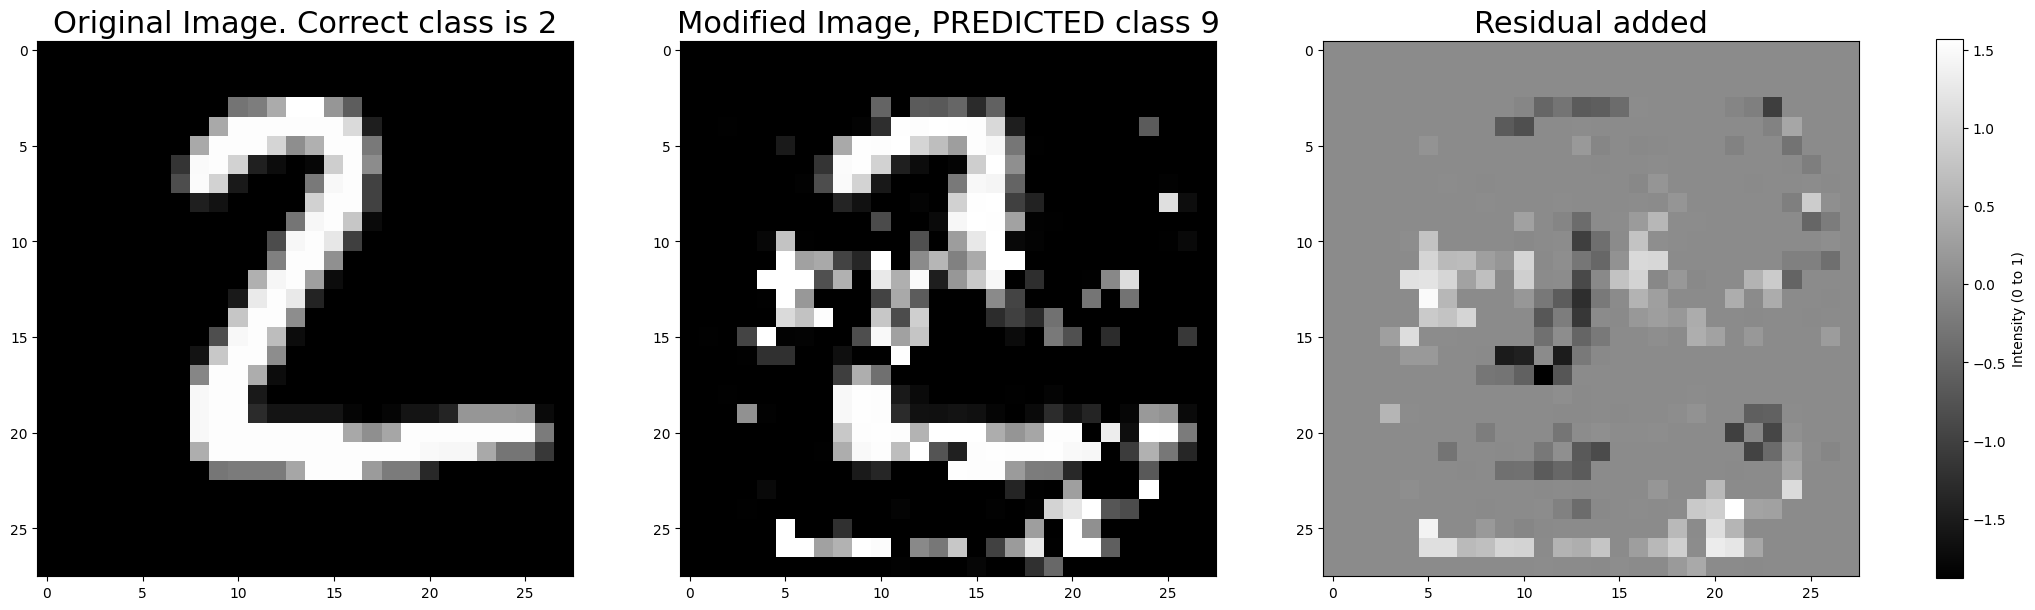

In [249]:
testI=testI.to(device)
r = torch.zeros_like(testI, requires_grad=True, device=device)  # Initialize r as zero
for o in [0,1,2,3,4,5,6,7,8,9]:
    label=o # manually chosen target class label different from true one
    l = torch.tensor([label]).to(device)  
    l=l.to(device)
    l = l.view(1) # to have a batch size equal to 1 and work with CrossEntropy loss
    print(f"The true class is {testY}, the new class will be {l[0]}")
    
    
    # Define the loss function
    def objective(c, r, x, l):
        # Compute the perturbed image
        x_r = torch.clamp(x + r, 0, 1)  # Ensure x + r ∈ [0, 1]^m
    
        # Compute the prediction for the perturbed image
        pred = model(x_r)
    
        # Compute the loss
        loss = loss_model(pred, l) + c * torch.norm(r, p=1)
    
        return loss
    
    
    # Line search to find the minimum c > 0
    c = initial_c
    iter=0
    while (c <= max_c) and (iter <= max_iter_search):    
        # Define the optimizer (Box-Constrained L-BFGS)
        optimizerLBFGS = optim.LBFGS([r], lr=lr_LBFGS, max_iter=max_iter_LBFGS, line_search_fn='strong_wolfe')
    
        def closure():
          optimizerLBFGS.zero_grad()
          loss = objective(c, r, testI, l)
          loss.backward()
          return loss
    
        # Perform optimization
        optimizerLBFGS.step(closure)
    
    
        # Evaluate the condition f(x + r) = l
        with torch.no_grad():
            x_r = torch.clamp(testI + r, 0, 1)  # Ensure x + r ∈ [0, 1]^m
            pred = model(x_r)
            predicted_label = torch.argmax(pred, dim=1)
    
        # Check if the condition f(x + r) = l is satisfied
        if predicted_label == l:
            print(f"Found c = {c:.6f} satisfying f(x + r) = l")
            iter=iter+1
            break
        else:
            iter=iter+1
    
        # If not satisfied, increase c
        # Adjust step size for line search
        c *= mult_c
        if (iter) % 20 == 0:
            print(f'Iter {iter}/{max_iter_search}, Value of c: {c:.6f}')
    
    if (c > max_c) or (iter > max_iter_search):
        print("Failed to find c satisfying f(x + r) = l within the maximum limit of c and max number of iter.")
        #print(f"Perturbation r: {r}")
        print(f"Norm Perturbation |r|: {torch.norm(r, p=1)}")
    
        plot_results(testI, r, x_r, testY, l, fail=True)
    
    else:
        print(f"Optimization succeeded with c = {c:.6f} in {iter} iterations")
        #print(f"Perturbation r: {r}")
        print(f"Norm Perturbation |r|: {torch.norm(r, p=1)}")
    
        plot_results(testI, r, x_r, testY, l, fail=False)

**QUESTION** Try with different images and different predicted classes (l), does the algorithm always converge ? You can test with different hyper-parameters for c. When it converges, are the images semantically similar to the original one ? Visually, would you say that they should belong to the original or new class ? What's the average distortion (norm of r) ?

> I conducted experiments using various images and predicted labels, and I did not encounter any instances where the algorithm failed to converge. I adjusted the learning rate of the optimizer. Although the images generated upon convergence are not always identical to the original images, they visually resemble the original labels. For instance, we examined the case where the original label was '2', and we attempted to use all other digits as target labels to deceive the model. The results indicated that the model struggled more significantly when attempting to predict '2' as '9' compared to when it predicted '2' as '0', with the average distortion being around 50. As I mentioned, there are some examples where the model struggles.

**Question** What if you try with different networks ? Test with al least another network (i.e., change hidden_sizes) and see if the previous conclusions are still confirmed. 

Furthermore, check the cross-network performance. This means:
- produce a set of adversarial instances for a given network (samples that are visually similar to the original class but recognised by the network as belonging to a different class)
- check if these adversarial examples are also wrongly classified by the other network

Which conclusions can you draw from these results ? Please comment on that.

### Another network (784, [100, 50], 10) architecture

The true class is 2, the new class will be 0
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 1 iterations
Norm Perturbation |r|: 54.77895736694336


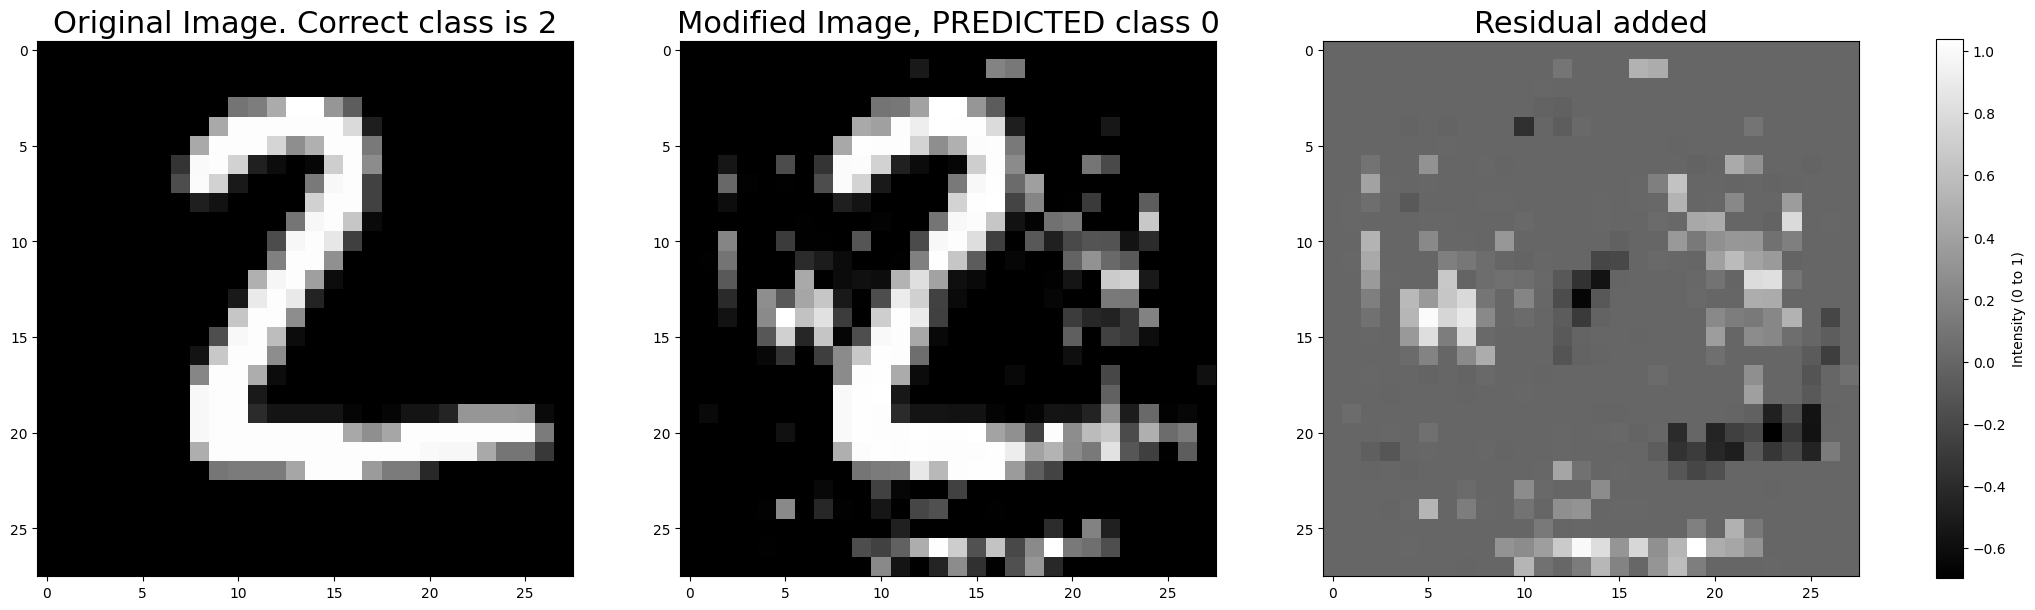

The true class is 2, the new class will be 1
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 1 iterations
Norm Perturbation |r|: 47.688720703125


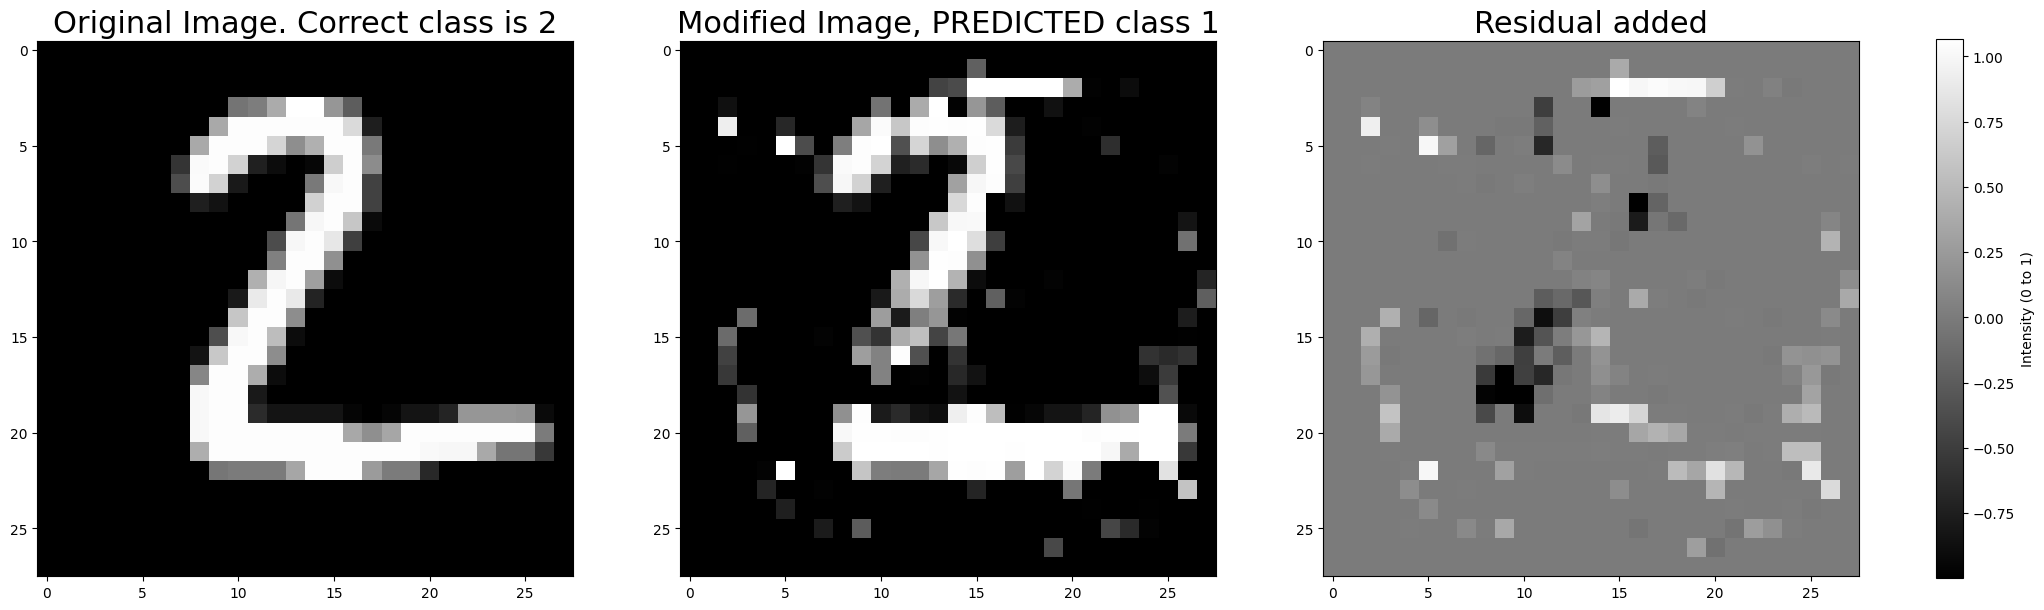

The true class is 2, the new class will be 2
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 1 iterations
Norm Perturbation |r|: 31.054466247558594


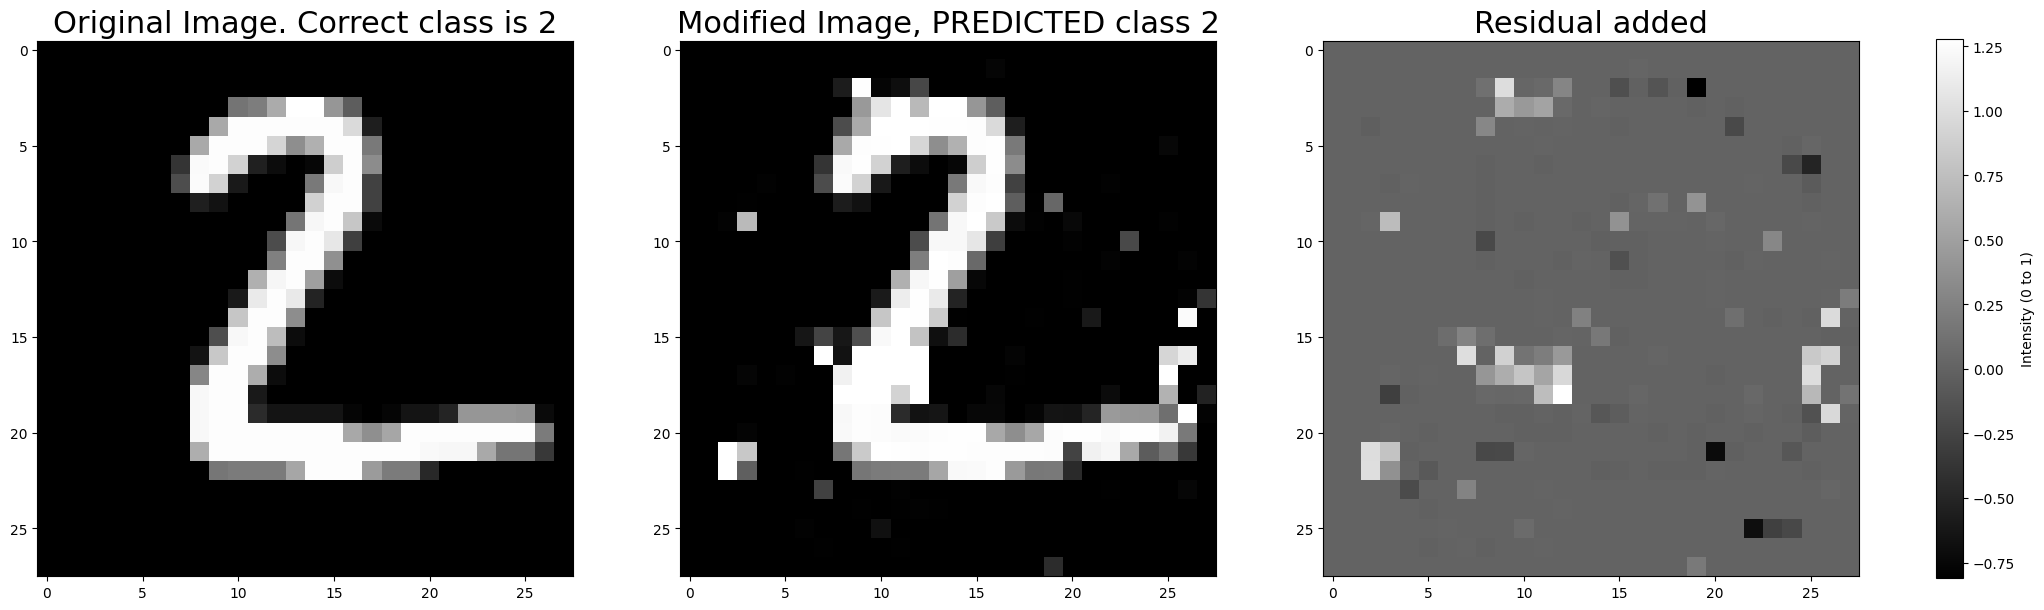

The true class is 2, the new class will be 3
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 1 iterations
Norm Perturbation |r|: 36.104618072509766


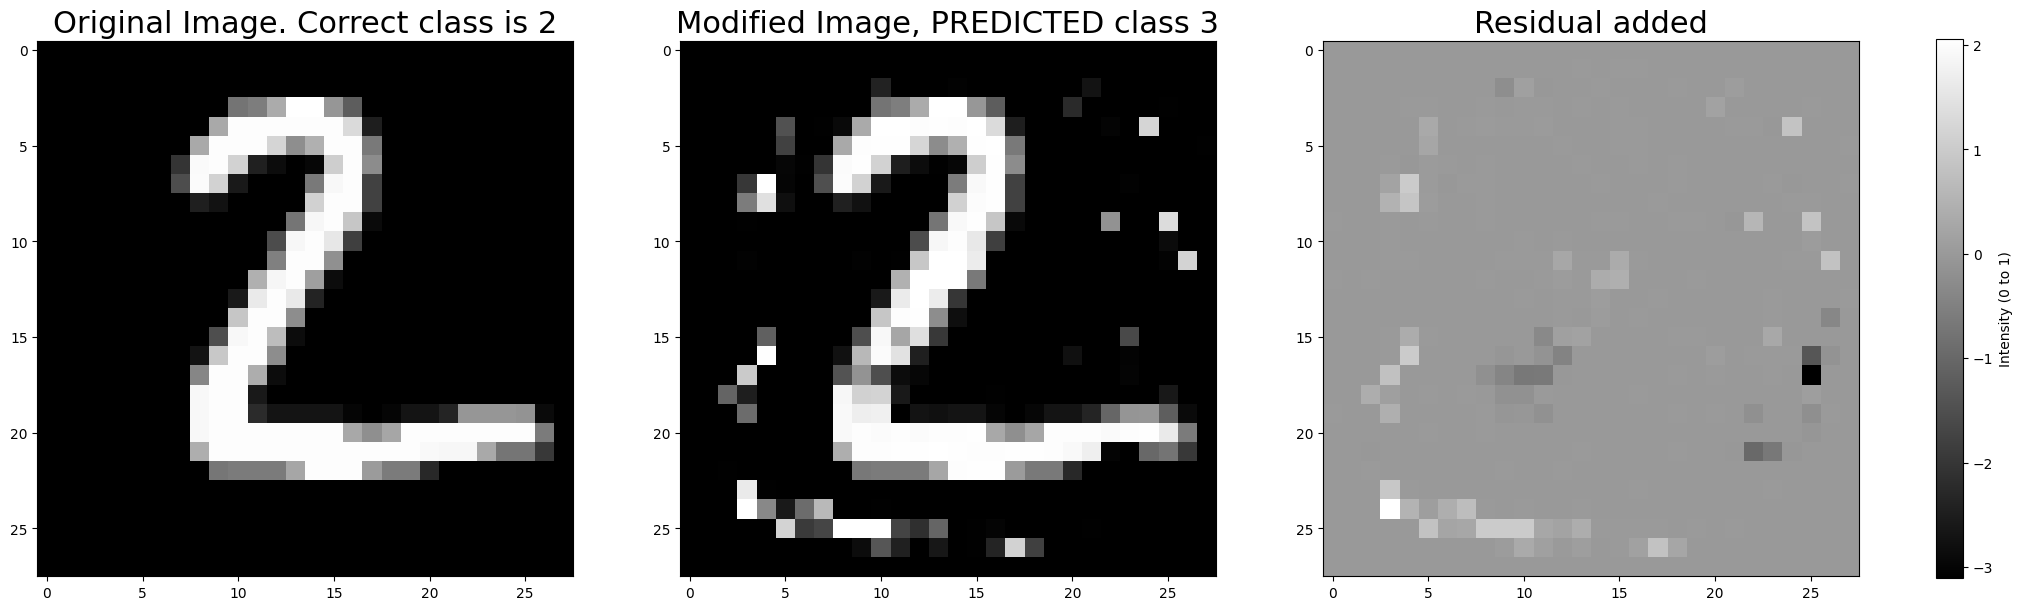

The true class is 2, the new class will be 4
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 1 iterations
Norm Perturbation |r|: 137.55728149414062


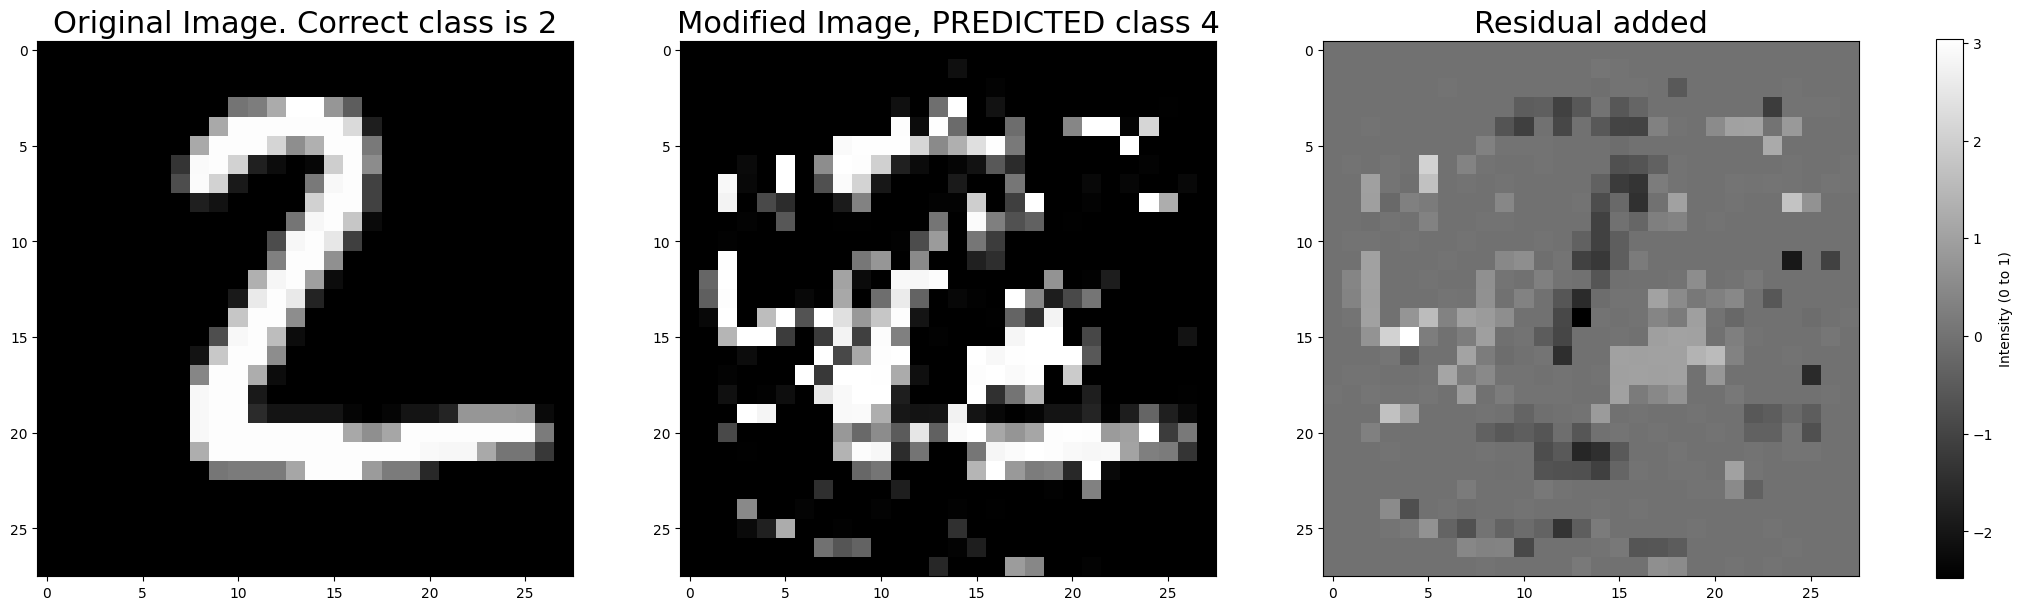

The true class is 2, the new class will be 5
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 1 iterations
Norm Perturbation |r|: 41.753787994384766


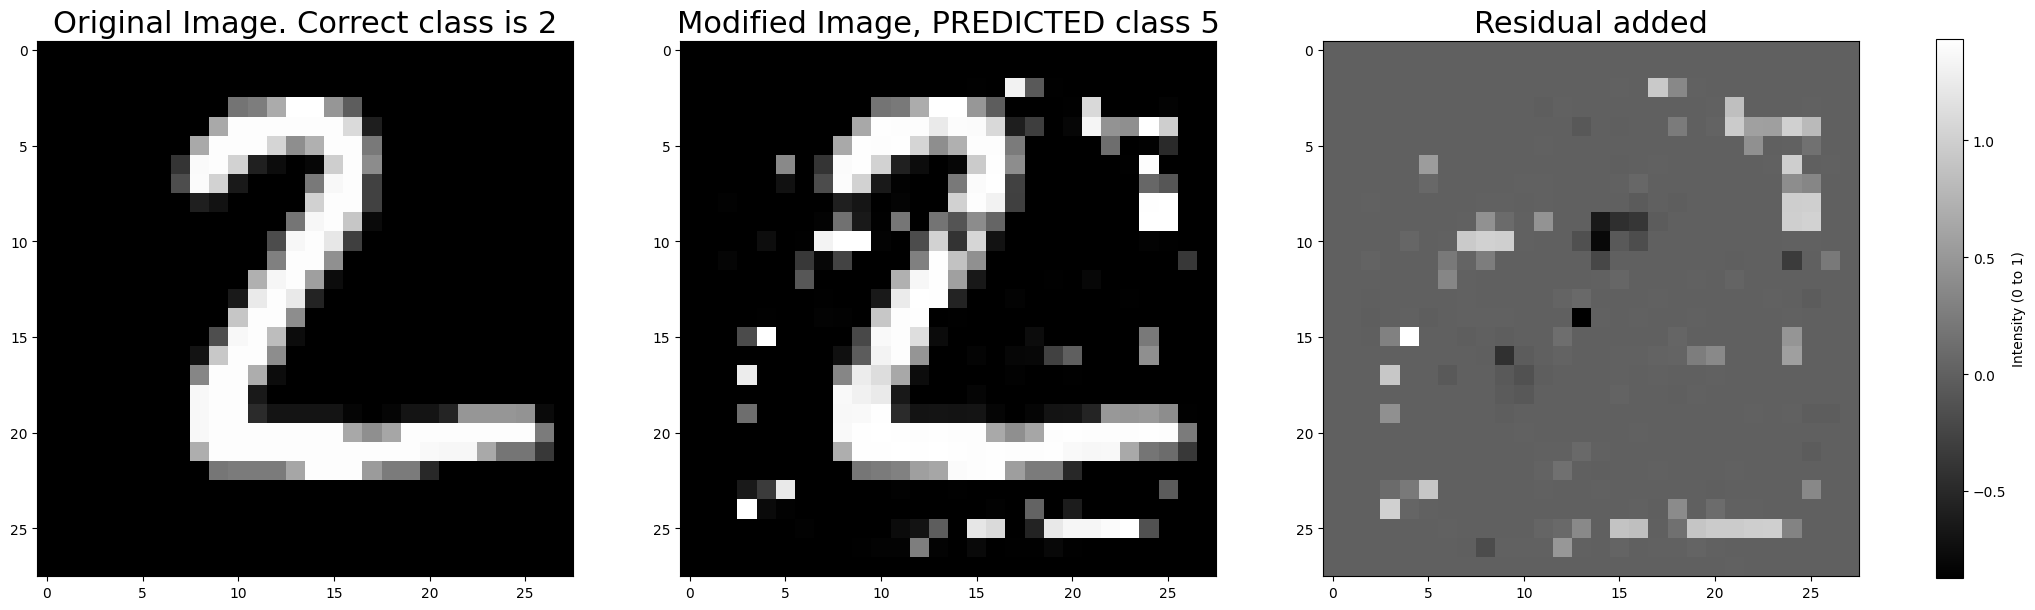

The true class is 2, the new class will be 6
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 1 iterations
Norm Perturbation |r|: 47.591915130615234


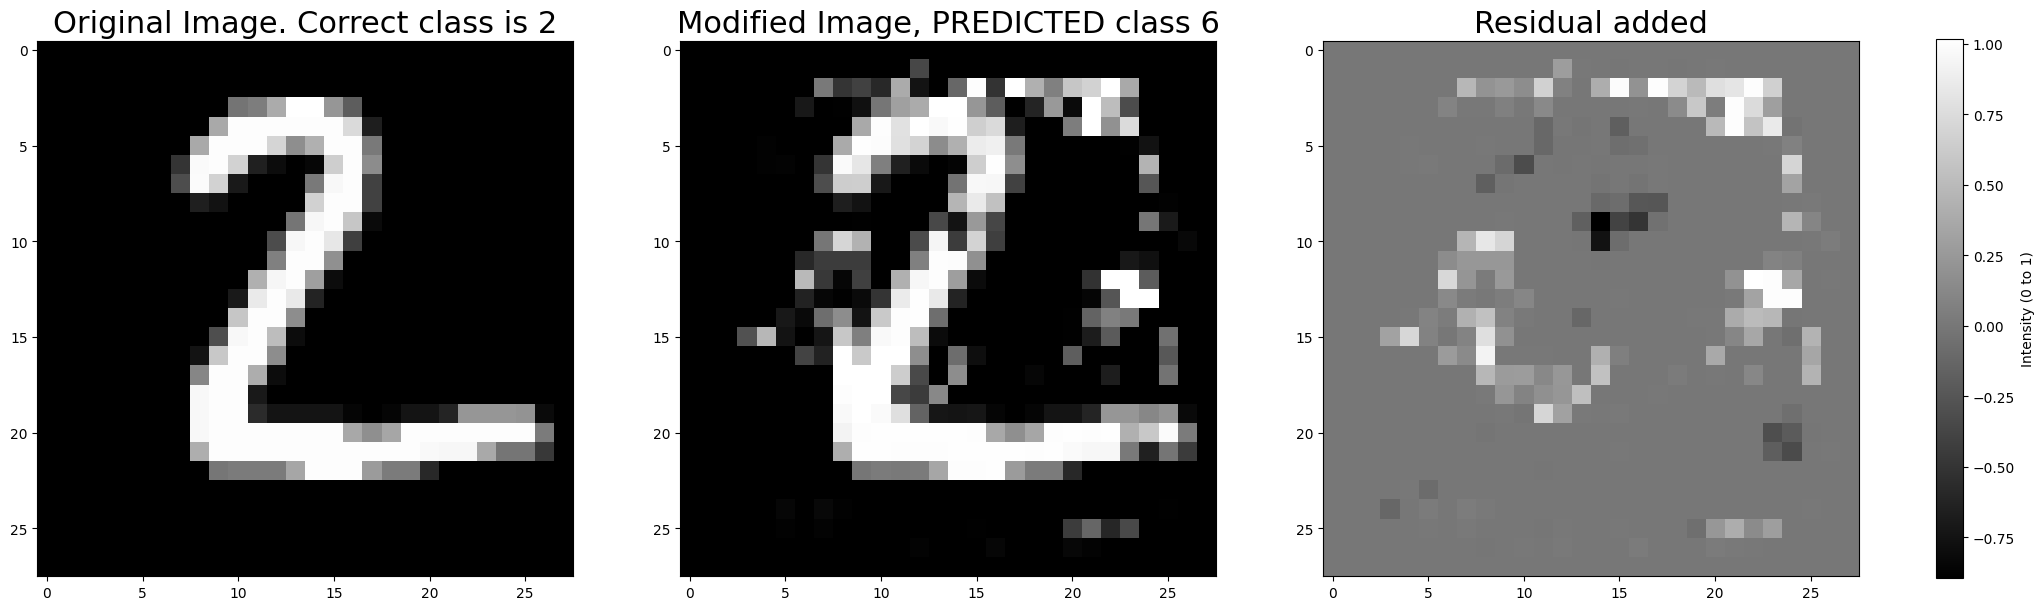

The true class is 2, the new class will be 7
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 1 iterations
Norm Perturbation |r|: 77.45877075195312


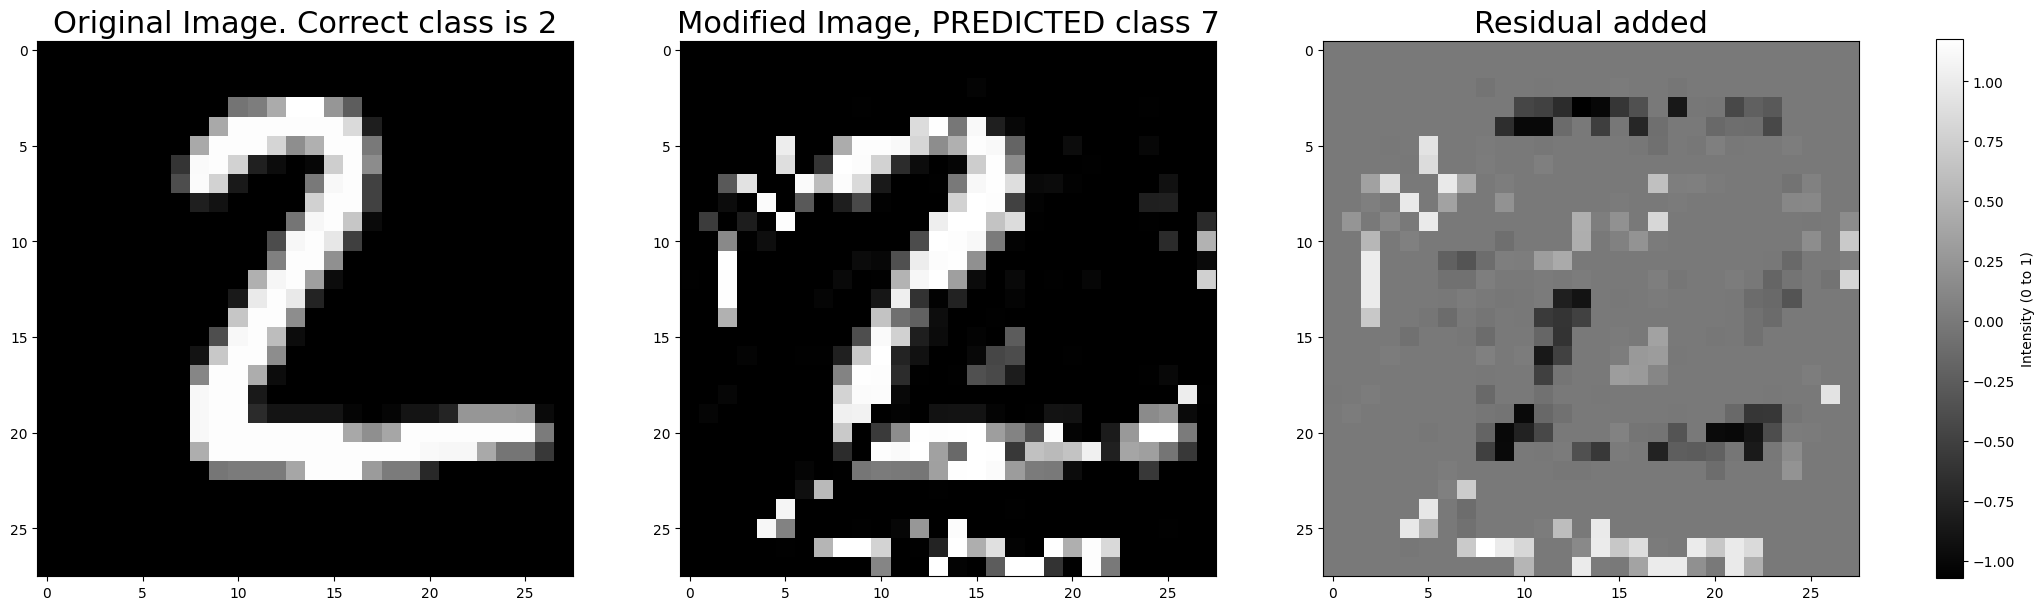

The true class is 2, the new class will be 8
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 1 iterations
Norm Perturbation |r|: 50.512691497802734


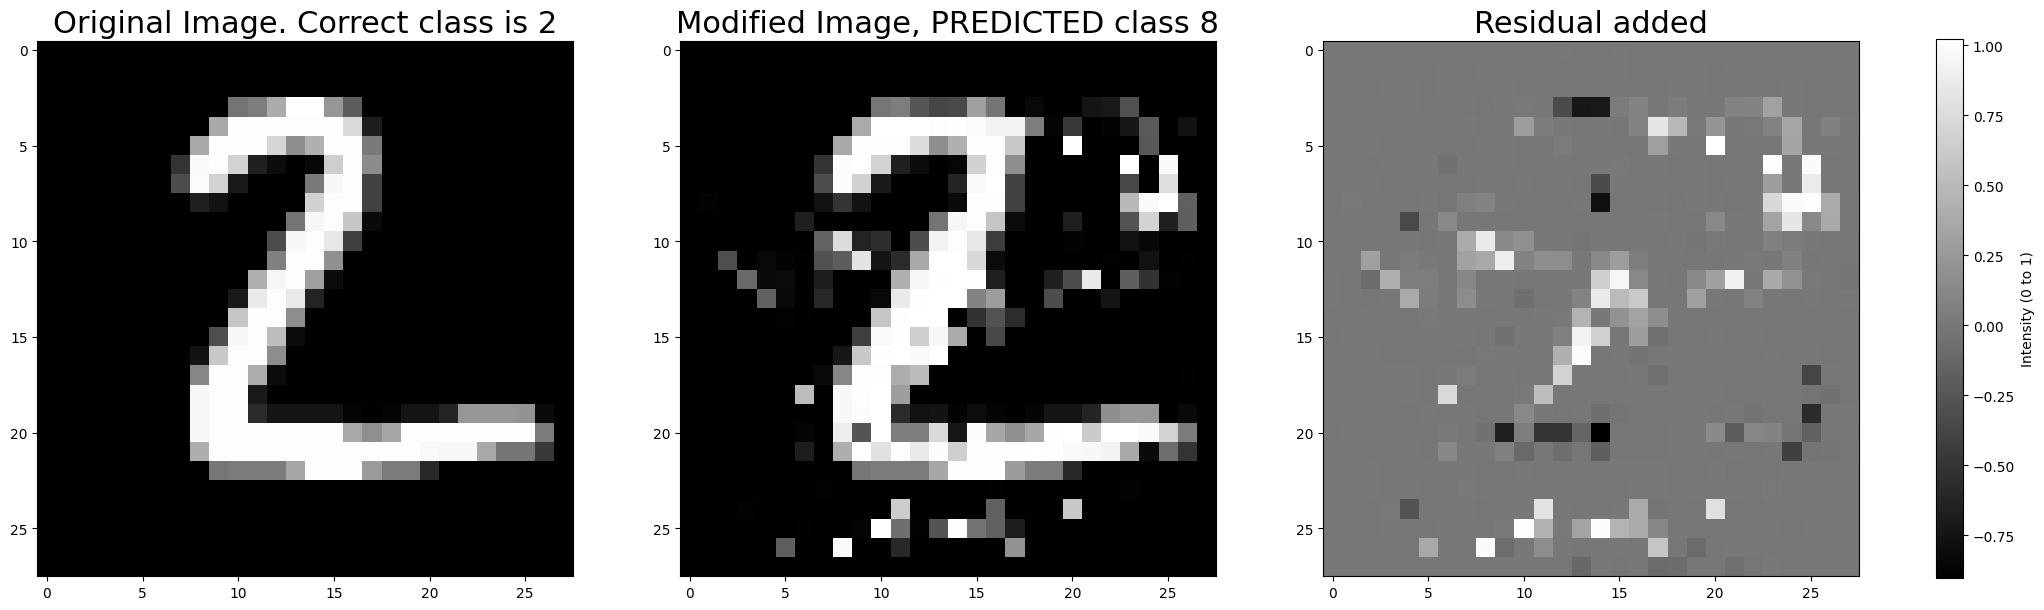

The true class is 2, the new class will be 9
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 1 iterations
Norm Perturbation |r|: 82.80281066894531


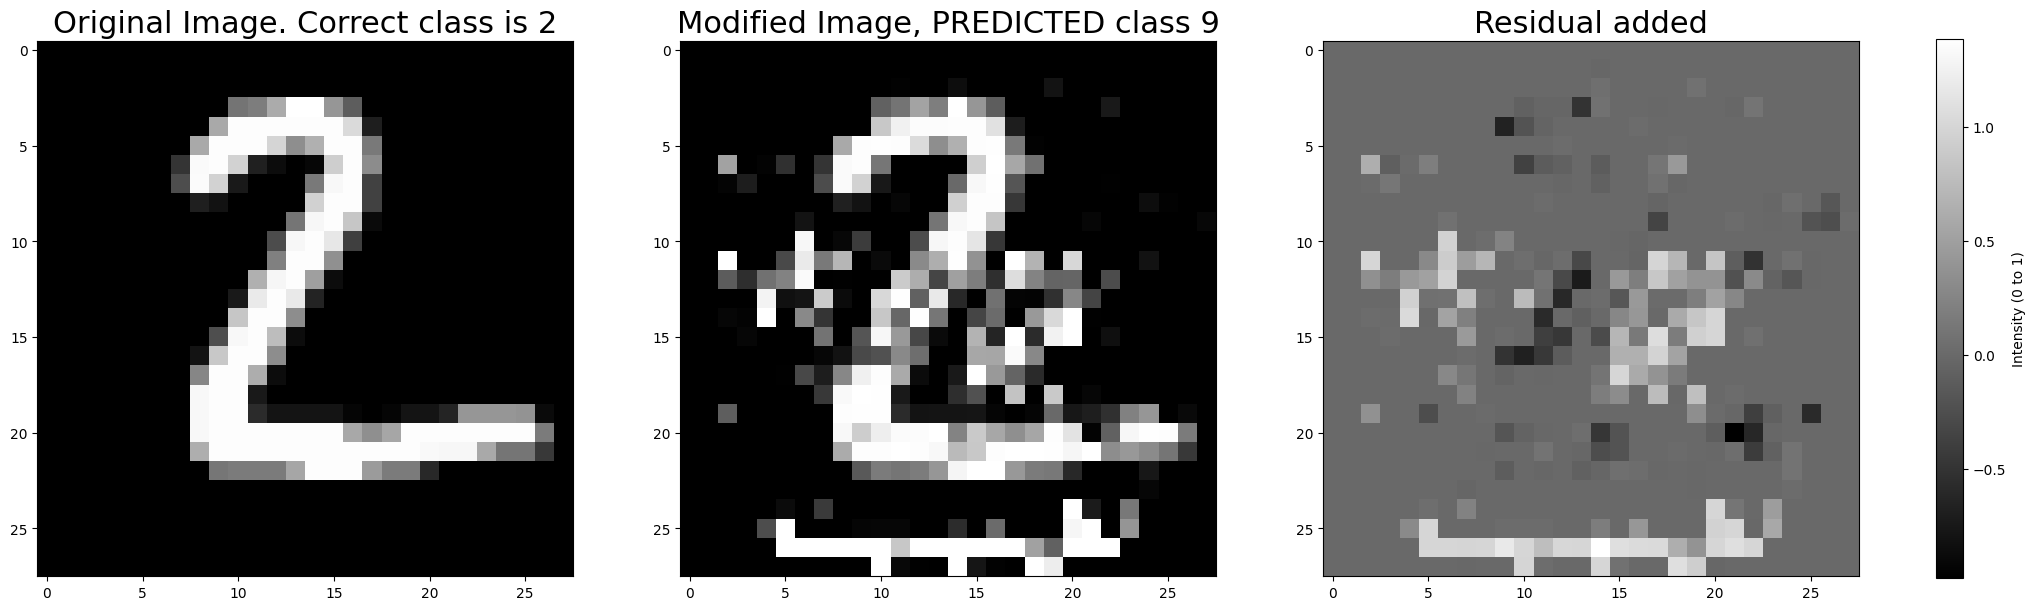

In [258]:
testI=testI.to(device)
r = torch.zeros_like(testI, requires_grad=True, device=device)  # Initialize r as zero
for o in [0,1,2,3,4,5,6,7,8,9]:
    label=o # manually chosen target class label different from true one
    l = torch.tensor([label]).to(device)  
    l=l.to(device)
    l = l.view(1) # to have a batch size equal to 1 and work with CrossEntropy loss
    print(f"The true class is {testY}, the new class will be {l[0]}")
    
    
    # Define the loss function
    def objective(c, r, x, l):
        # Compute the perturbed image
        x_r = torch.clamp(x + r, 0, 1)  # Ensure x + r ∈ [0, 1]^m
    
        # Compute the prediction for the perturbed image
        pred = model(x_r)
    
        # Compute the loss
        loss = loss_model(pred, l) + c * torch.norm(r, p=1)
    
        return loss
    
    
    # Line search to find the minimum c > 0
    c = initial_c
    iter=0
    while (c <= max_c) and (iter <= max_iter_search):    
        # Define the optimizer (Box-Constrained L-BFGS)
        optimizerLBFGS = optim.LBFGS([r], lr=lr_LBFGS, max_iter=max_iter_LBFGS, line_search_fn='strong_wolfe')
    
        def closure():
          optimizerLBFGS.zero_grad()
          loss = objective(c, r, testI, l)
          loss.backward()
          return loss
    
        # Perform optimization
        optimizerLBFGS.step(closure)
    
    
        # Evaluate the condition f(x + r) = l
        with torch.no_grad():
            x_r = torch.clamp(testI + r, 0, 1)  # Ensure x + r ∈ [0, 1]^m
            pred = model(x_r)
            predicted_label = torch.argmax(pred, dim=1)
    
        # Check if the condition f(x + r) = l is satisfied
        if predicted_label == l:
            print(f"Found c = {c:.6f} satisfying f(x + r) = l")
            iter=iter+1
            break
        else:
            iter=iter+1
    
        # If not satisfied, increase c
        # Adjust step size for line search
        c *= mult_c
        if (iter) % 20 == 0:
            print(f'Iter {iter}/{max_iter_search}, Value of c: {c:.6f}')
    
    if (c > max_c) or (iter > max_iter_search):
        print("Failed to find c satisfying f(x + r) = l within the maximum limit of c and max number of iter.")
        #print(f"Perturbation r: {r}")
        print(f"Norm Perturbation |r|: {torch.norm(r, p=1)}")
    
        plot_results(testI, r, x_r, testY, l, fail=True)
    
    else:
        print(f"Optimization succeeded with c = {c:.6f} in {iter} iterations")
        #print(f"Perturbation r: {r}")
        print(f"Norm Perturbation |r|: {torch.norm(r, p=1)}")
    
        plot_results(testI, r, x_r, testY, l, fail=False)

> We can observe that it also succeeded in deceiving another model.

### Cross-network performance

In [270]:

print (model1)

FullyConnectedNet(
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=100, bias=True)
    (1): ReLU()
    (2): Linear(in_features=100, out_features=50, bias=True)
    (3): ReLU()
    (4): Linear(in_features=50, out_features=10, bias=True)
  )
)


In [271]:
print(model2)

FullyConnectedNet(
  (layers): Sequential(
    (0): Linear(in_features=784, out_features=200, bias=True)
    (1): ReLU()
    (2): Linear(in_features=200, out_features=100, bias=True)
    (3): ReLU()
    (4): Linear(in_features=100, out_features=10, bias=True)
  )
)


####  Adversarial instance for model 1 [100,50]

The true class is 2, the new class will be 3
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 1 iterations
Norm Perturbation |r|: 55.1562614440918


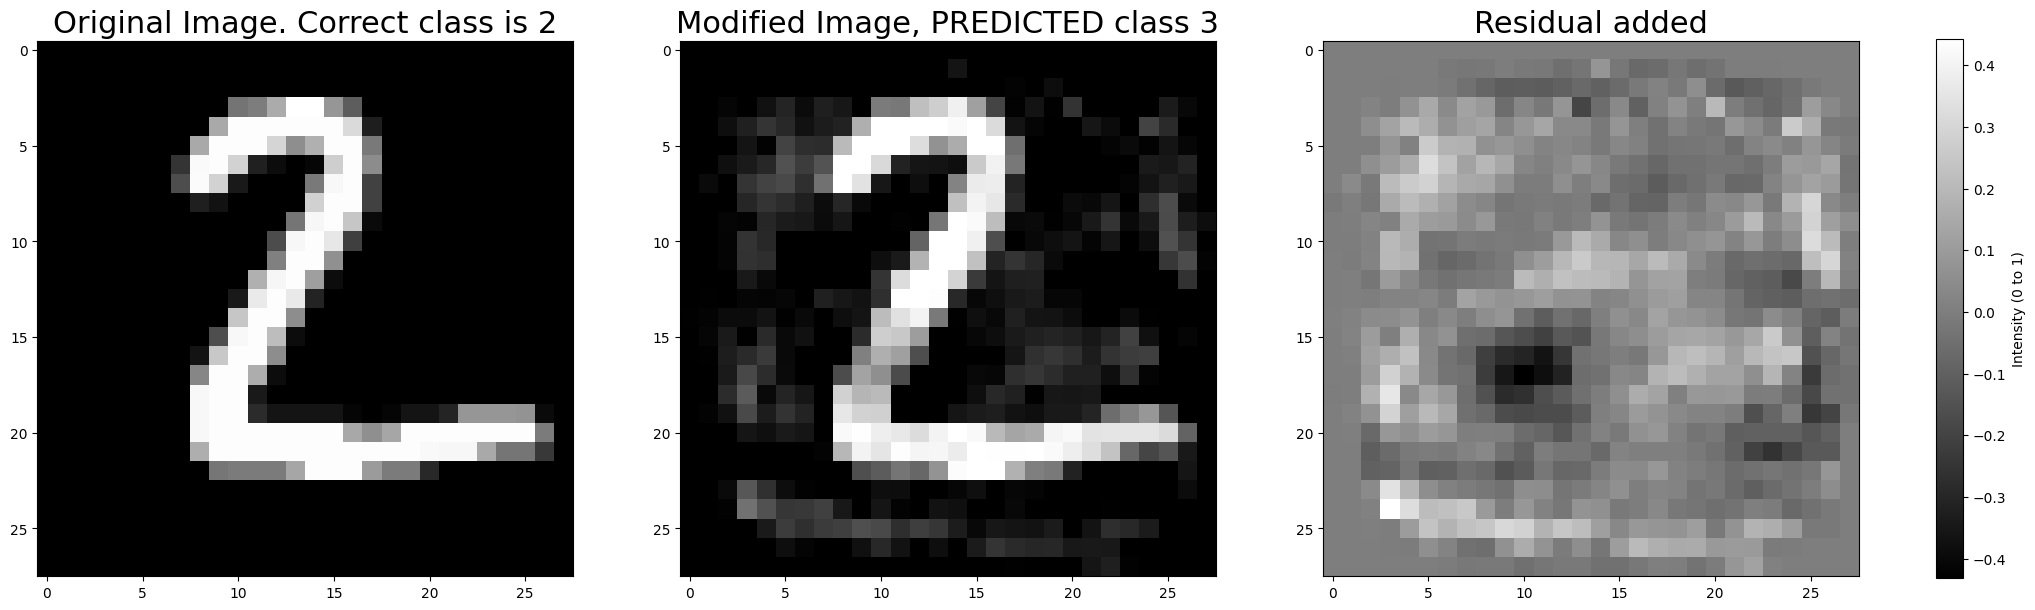

Model1 Prediction: 3
Model2 Prediction: 3


In [273]:
testI = testI.to(device)
r = torch.zeros_like(testI, requires_grad=True, device=device)  # Initialize r as zero

# Specify the target class label (choose a label different from the true class)
label = 3  # For example, let's choose label 3 as the target class
l = torch.tensor([label]).to(device)  # Target label
l = l.view(1)  # To have a batch size equal to 1 and work with CrossEntropy loss

print(f"The true class is {testY}, the new class will be {l[0]}")

# Define the loss function
def objective(c, r, x, l):
    # Compute the perturbed image
    x_r = torch.clamp(x + r, 0, 1)  # Ensure x + r ∈ [0, 1]^m

    # Compute the prediction for the perturbed image
    pred = model1(x_r)

    # Compute the loss
    loss = loss_model(pred, l) + c * torch.norm(r, p=1)

    return loss

# Line search to find the minimum c > 0
c = initial_c
iter = 0
while (c <= max_c) and (iter <= max_iter_search):    
    # Define the optimizer (Box-Constrained L-BFGS)
    optimizerLBFGS = optim.LBFGS([r], lr=lr_LBFGS, max_iter=max_iter_LBFGS, line_search_fn='strong_wolfe')

    def closure():
        optimizerLBFGS.zero_grad()
        loss = objective(c, r, testI, l)
        loss.backward()
        return loss

    # Perform optimization
    optimizerLBFGS.step(closure)

    # Evaluate the condition f(x + r) = l
    with torch.no_grad():
        x_r = torch.clamp(testI + r, 0, 1)  # Ensure x + r ∈ [0, 1]^m
        pred = model1(x_r)
        predicted_label = torch.argmax(pred, dim=1)

    # Check if the condition f(x + r) = l is satisfied
    if predicted_label == l:
        print(f"Found c = {c:.6f} satisfying f(x + r) = l")
        iter += 1
        break
    else:
        iter += 1

    # If not satisfied, increase c
    c *= mult_c
    if iter % 20 == 0:
        print(f'Iter {iter}/{max_iter_search}, Value of c: {c:.6f}')

if (c > max_c) or (iter > max_iter_search):
    print("Failed to find c satisfying f(x + r) = l within the maximum limit of c and max number of iter.")
    print(f"Norm Perturbation |r|: {torch.norm(r, p=1)}")
    plot_results(testI, r, x_r, testY, l, fail=True)
else:
    print(f"Optimization succeeded with c = {c:.6f} in {iter} iterations")
    print(f"Norm Perturbation |r|: {torch.norm(r, p=1)}")
    plot_results(testI, r, x_r, testY, l, fail=False)

# Evaluate adversarial example on model1 and model2
with torch.no_grad():
    # Evaluate on model1
    x_r = torch.clamp(testI + r, 0, 1)  # Ensure x + r ∈ [0, 1]^m
    pred1 = model1(x_r)
    predicted_label1 = torch.argmax(pred1, dim=1)
    print(f"Model1 Prediction: {predicted_label1.item()}")

    # Evaluate on model2
    pred2 = model2(x_r)
    predicted_label2 = torch.argmax(pred2, dim=1)
    print(f"Model2 Prediction: {predicted_label2.item()}")


####  Adversarial instance for model 2 [200,100]

The true class is 2, the new class will be 3
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 1 iterations
Norm Perturbation |r|: 27.966136932373047


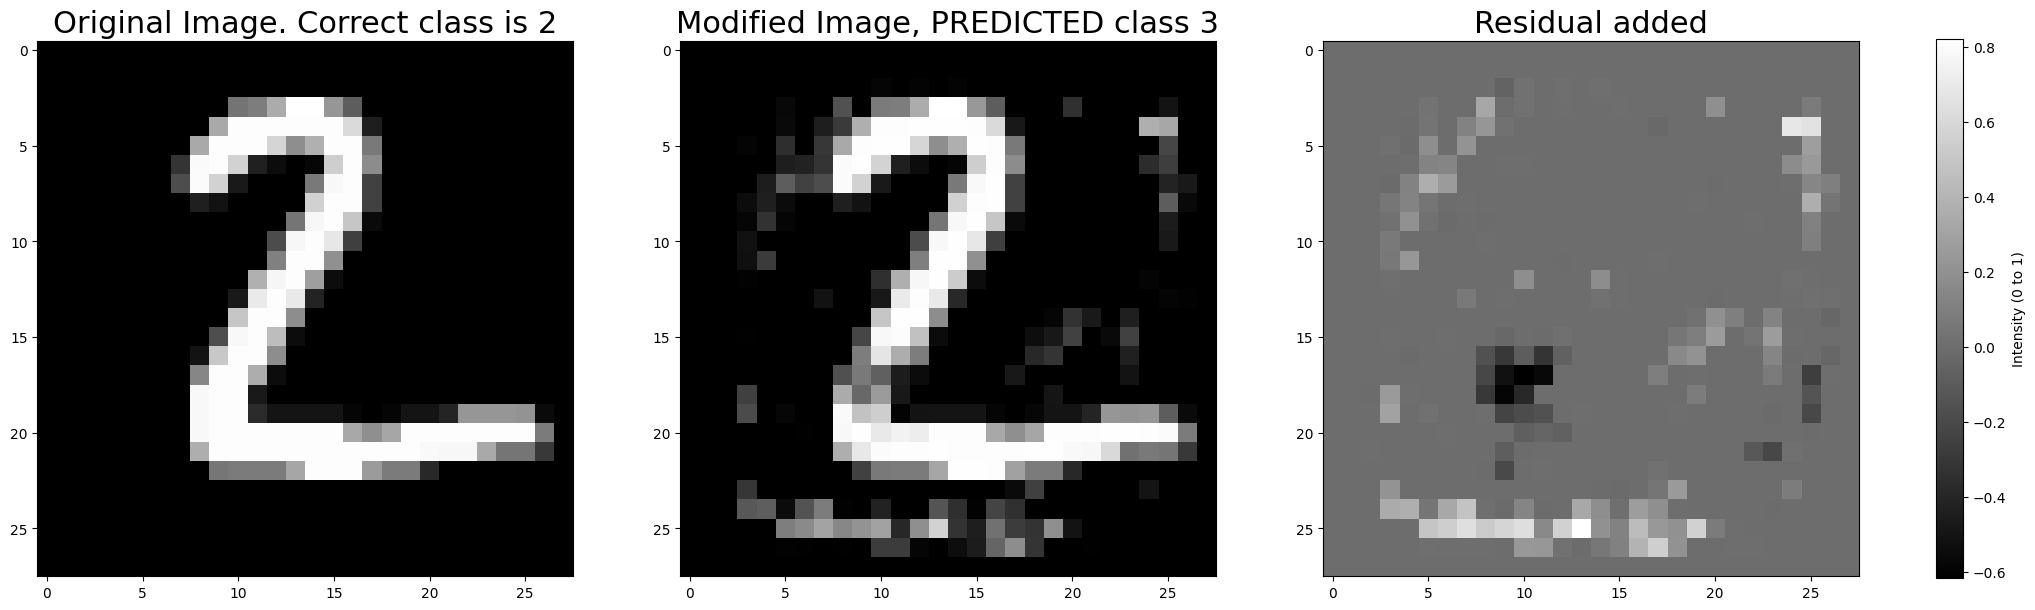

Model1 Prediction: 3
Model2 Prediction: 3


In [274]:
testI = testI.to(device)
r = torch.zeros_like(testI, requires_grad=True, device=device)  # Initialize r as zero

# Specify the target class label (choose a label different from the true class)
label = 3  # For example, let's choose label 3 as the target class
l = torch.tensor([label]).to(device)  # Target label
l = l.view(1)  # To have a batch size equal to 1 and work with CrossEntropy loss

print(f"The true class is {testY}, the new class will be {l[0]}")

# Define the loss function
def objective(c, r, x, l):
    # Compute the perturbed image
    x_r = torch.clamp(x + r, 0, 1)  # Ensure x + r ∈ [0, 1]^m

    # Compute the prediction for the perturbed image
    pred = model2(x_r)

    # Compute the loss
    loss = loss_model(pred, l) + c * torch.norm(r, p=1)

    return loss

# Line search to find the minimum c > 0
c = initial_c
iter = 0
while (c <= max_c) and (iter <= max_iter_search):    
    # Define the optimizer (Box-Constrained L-BFGS)
    optimizerLBFGS = optim.LBFGS([r], lr=lr_LBFGS, max_iter=max_iter_LBFGS, line_search_fn='strong_wolfe')

    def closure():
        optimizerLBFGS.zero_grad()
        loss = objective(c, r, testI, l)
        loss.backward()
        return loss

    # Perform optimization
    optimizerLBFGS.step(closure)

    # Evaluate the condition f(x + r) = l
    with torch.no_grad():
        x_r = torch.clamp(testI + r, 0, 1)  # Ensure x + r ∈ [0, 1]^m
        pred = model2(x_r)
        predicted_label = torch.argmax(pred, dim=1)

    # Check if the condition f(x + r) = l is satisfied
    if predicted_label == l:
        print(f"Found c = {c:.6f} satisfying f(x + r) = l")
        iter += 1
        break
    else:
        iter += 1

    # If not satisfied, increase c
    c *= mult_c
    if iter % 20 == 0:
        print(f'Iter {iter}/{max_iter_search}, Value of c: {c:.6f}')

if (c > max_c) or (iter > max_iter_search):
    print("Failed to find c satisfying f(x + r) = l within the maximum limit of c and max number of iter.")
    print(f"Norm Perturbation |r|: {torch.norm(r, p=1)}")
    plot_results(testI, r, x_r, testY, l, fail=True)
else:
    print(f"Optimization succeeded with c = {c:.6f} in {iter} iterations")
    print(f"Norm Perturbation |r|: {torch.norm(r, p=1)}")
    plot_results(testI, r, x_r, testY, l, fail=False)

# Evaluate adversarial example on model1 and model2
with torch.no_grad():
    # Evaluate on model1
    x_r = torch.clamp(testI + r, 0, 1)  # Ensure x + r ∈ [0, 1]^m
    pred1 = model1(x_r)
    predicted_label1 = torch.argmax(pred1, dim=1)
    print(f"Model1 Prediction: {predicted_label1.item()}")

    # Evaluate on model2
    pred2 = model2(x_r)
    predicted_label2 = torch.argmax(pred2, dim=1)
    print(f"Model2 Prediction: {predicted_label2.item()}")


> The results suggest that both models share a similar vulnerability to adversarial examples, as the perturbations generated for one model also fool the other, despite being trained independently. This indicates that the models may be learning similar decision boundaries or features, making them susceptible to the same types of adversarial perturbations.**

## ADAM 

Instead than using L-BFGS to find adversarial examples we could also use a backpropagation method such as Adam, where you could optimize only r or both r and c. 

**Question** Change the previous code to use Adam instead than L-BFGS for the optimization. This means that you don't do anymore a line-search to find the minimum $c$ (no more closure). You can either fix $c$ and estimate only $r$ or estimate both. Try these two solutions and comment on that. Does it work properly ? If not, try to change the loss function. Would you add a regularization term ? If yes, which one and why ? Does it work better ? Please comment on that.

### done on [100,50] model

#### Fixing c and Estimating Only r

The true class is 2, the new class will be 0
Iter 20/300
Iter 40/300
Iter 60/300
Iter 80/300
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 83 iterations
Norm Perturbation |r|: 34.036808013916016


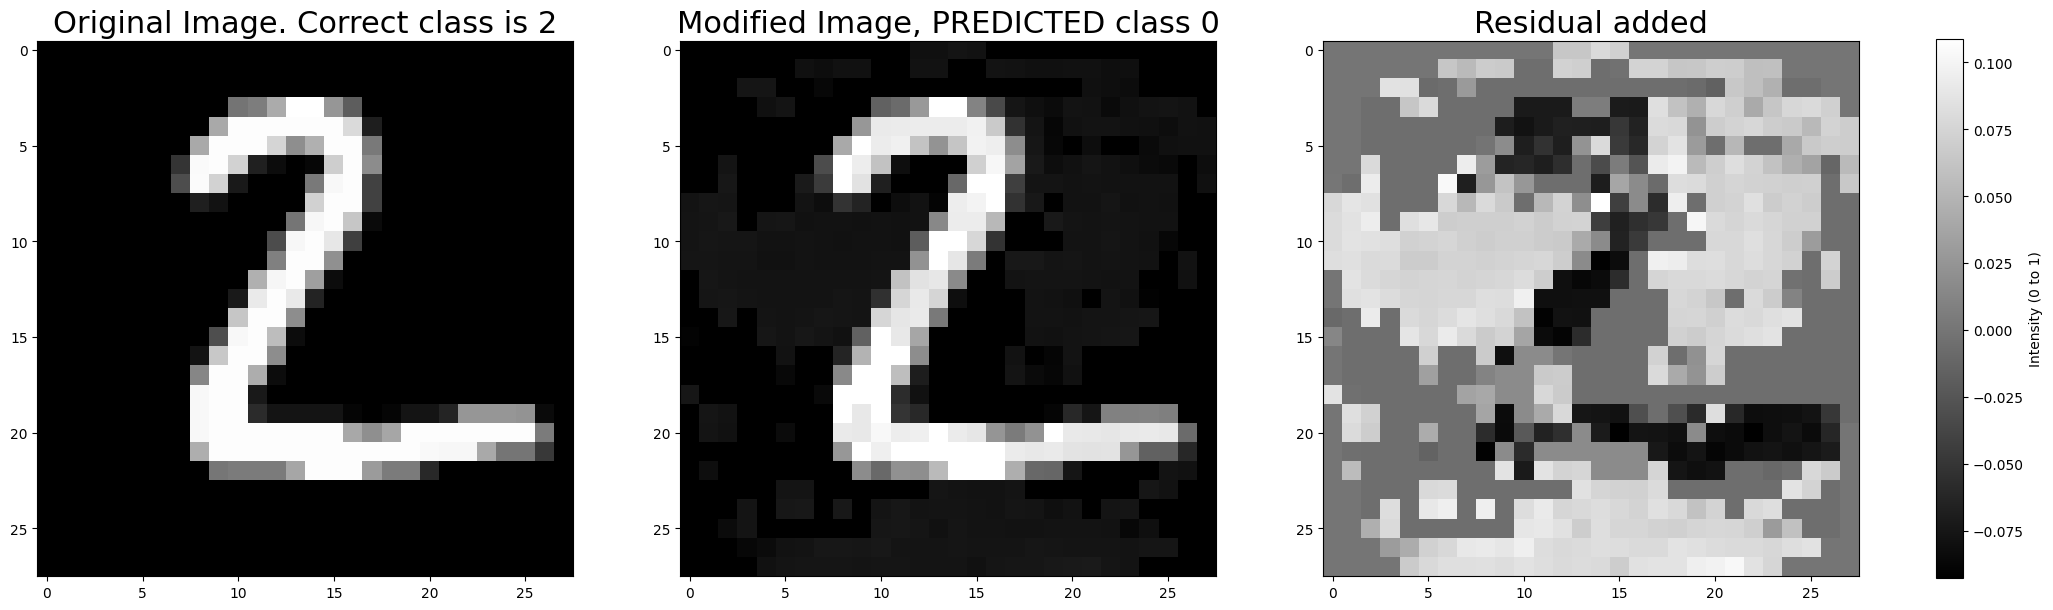

The true class is 2, the new class will be 1
Iter 20/300
Iter 40/300
Iter 60/300
Iter 80/300
Iter 100/300
Iter 120/300
Iter 140/300
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 145 iterations
Norm Perturbation |r|: 36.49699401855469


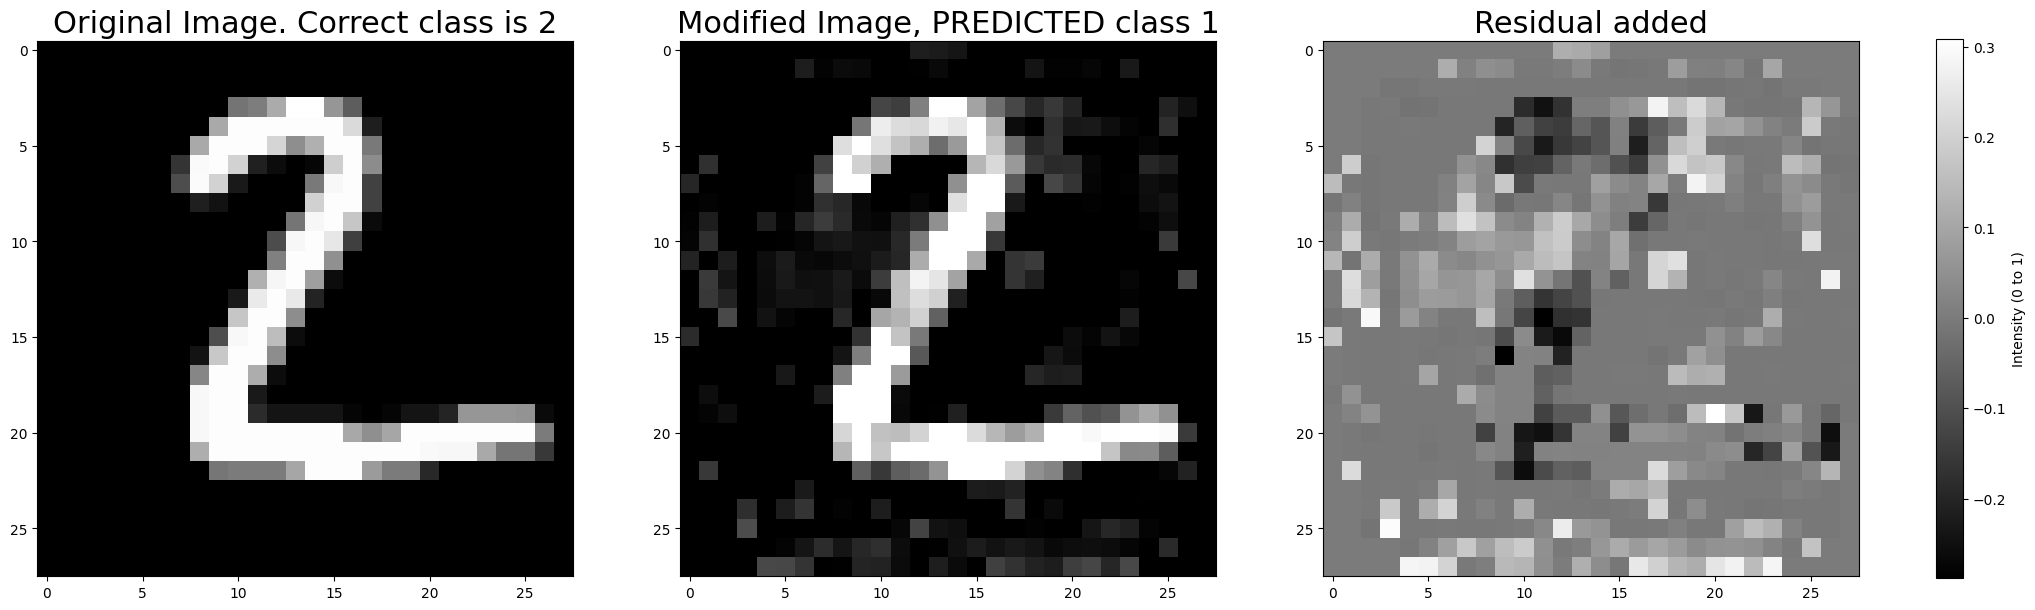

The true class is 2, the new class will be 2
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 9 iterations
Norm Perturbation |r|: 36.30800247192383


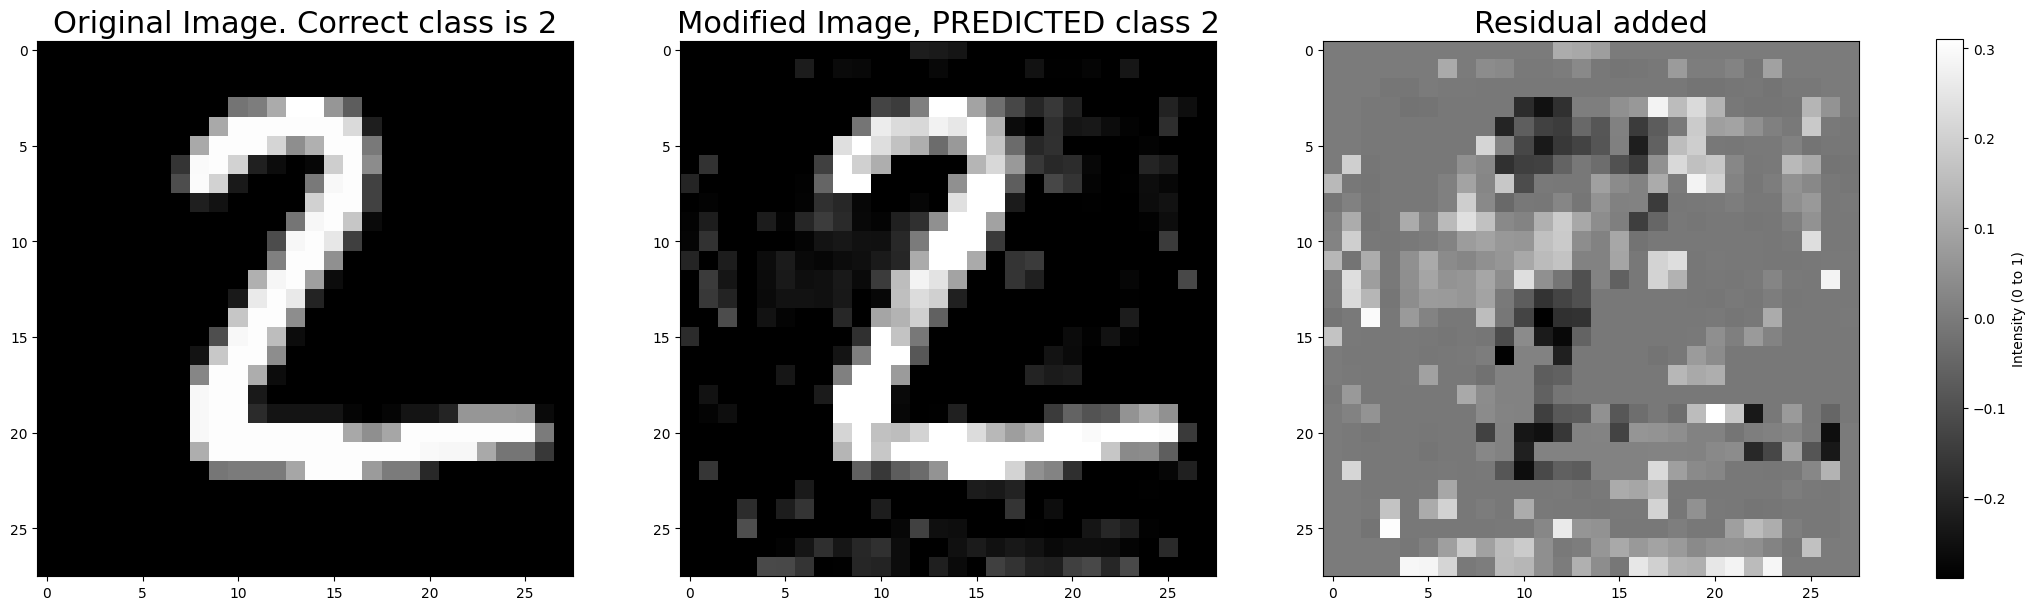

The true class is 2, the new class will be 3
Iter 20/300
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 23 iterations
Norm Perturbation |r|: 37.03444290161133


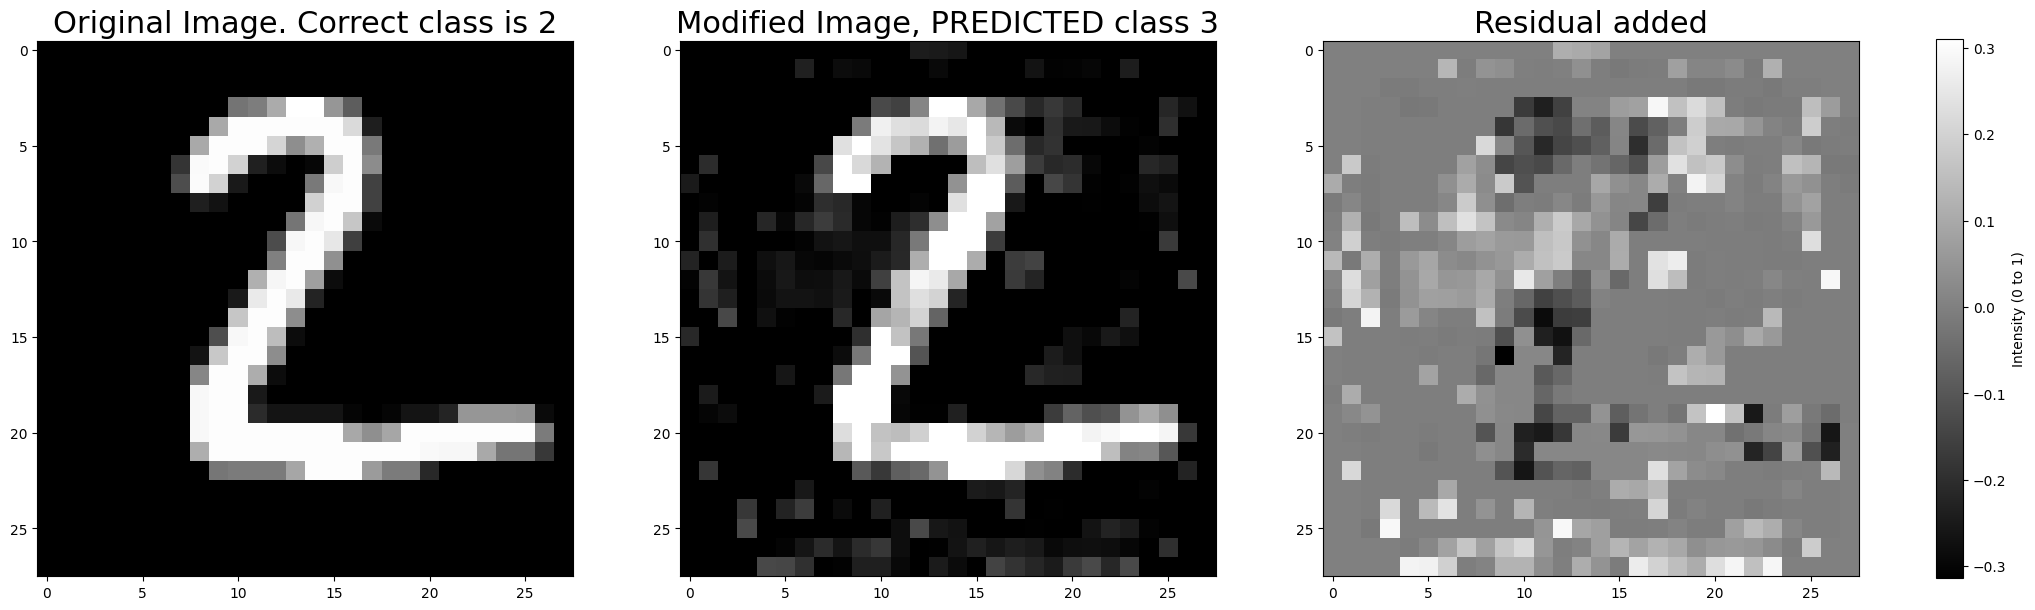

The true class is 2, the new class will be 4
Iter 20/300
Iter 40/300
Iter 60/300
Iter 80/300
Iter 100/300
Iter 120/300
Iter 140/300
Iter 160/300
Iter 180/300
Iter 200/300
Iter 220/300
Iter 240/300
Iter 260/300
Iter 280/300
Iter 300/300
Failed to find c satisfying f(x + r) = l within the maximum limit of iterations.
Norm Perturbation |r|: 58.615272521972656


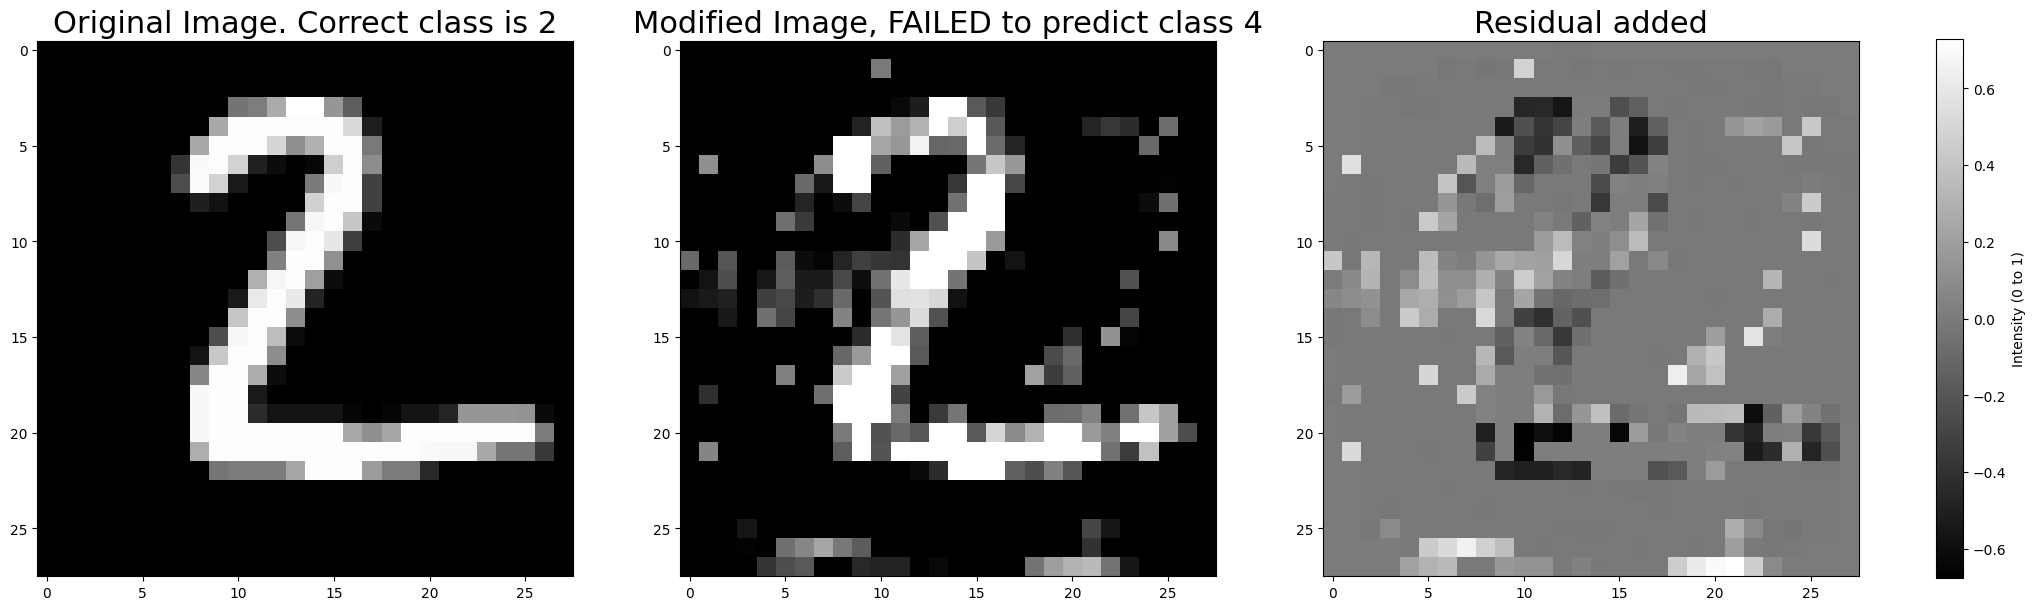

The true class is 2, the new class will be 5
Iter 20/300
Iter 40/300
Iter 60/300
Iter 80/300
Iter 100/300
Iter 120/300
Iter 140/300
Iter 160/300
Iter 180/300
Iter 200/300
Iter 220/300
Iter 240/300
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 259 iterations
Norm Perturbation |r|: 59.620689392089844


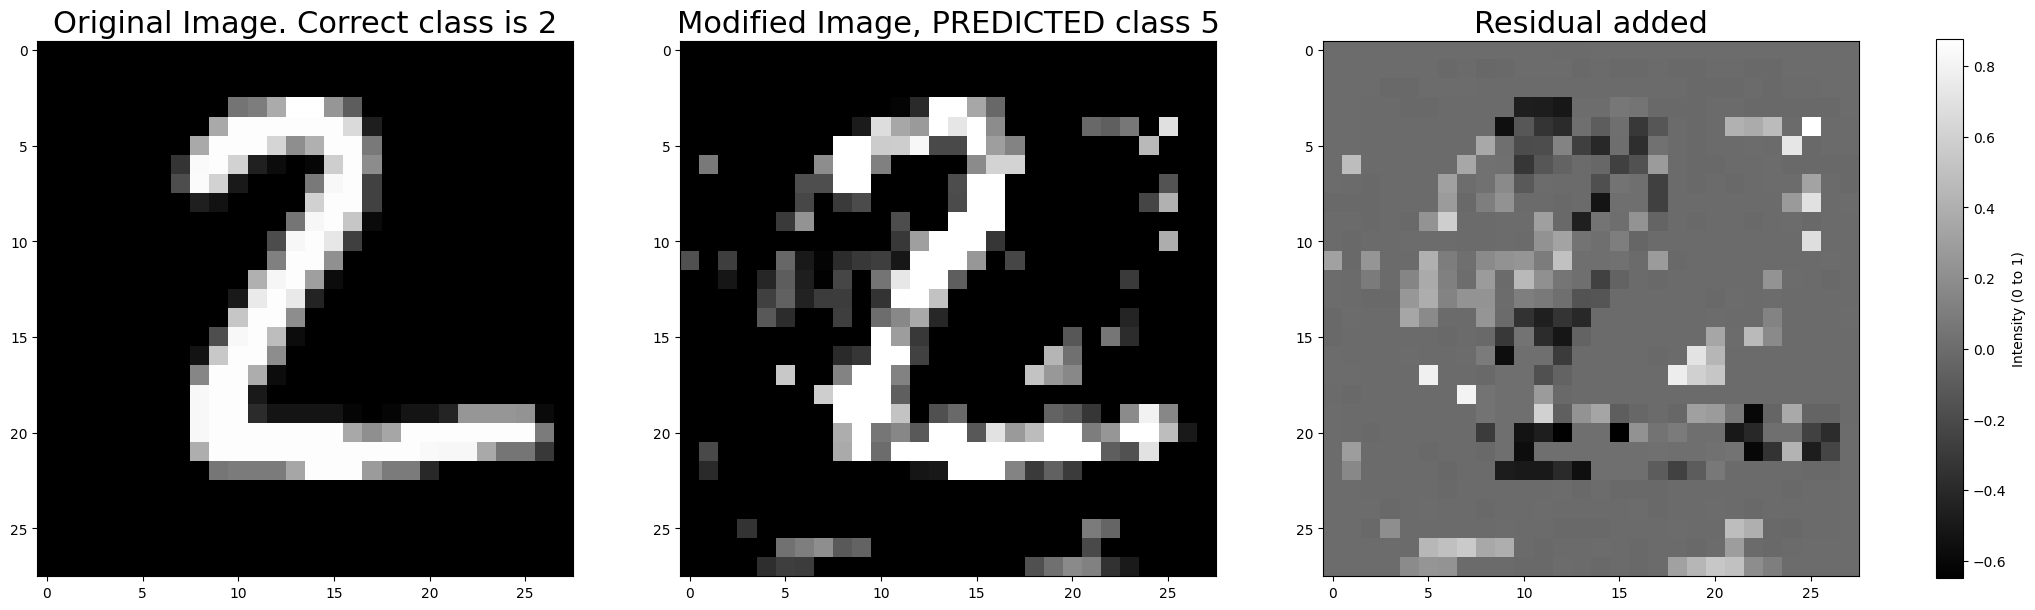

The true class is 2, the new class will be 6
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 6 iterations
Norm Perturbation |r|: 59.600379943847656


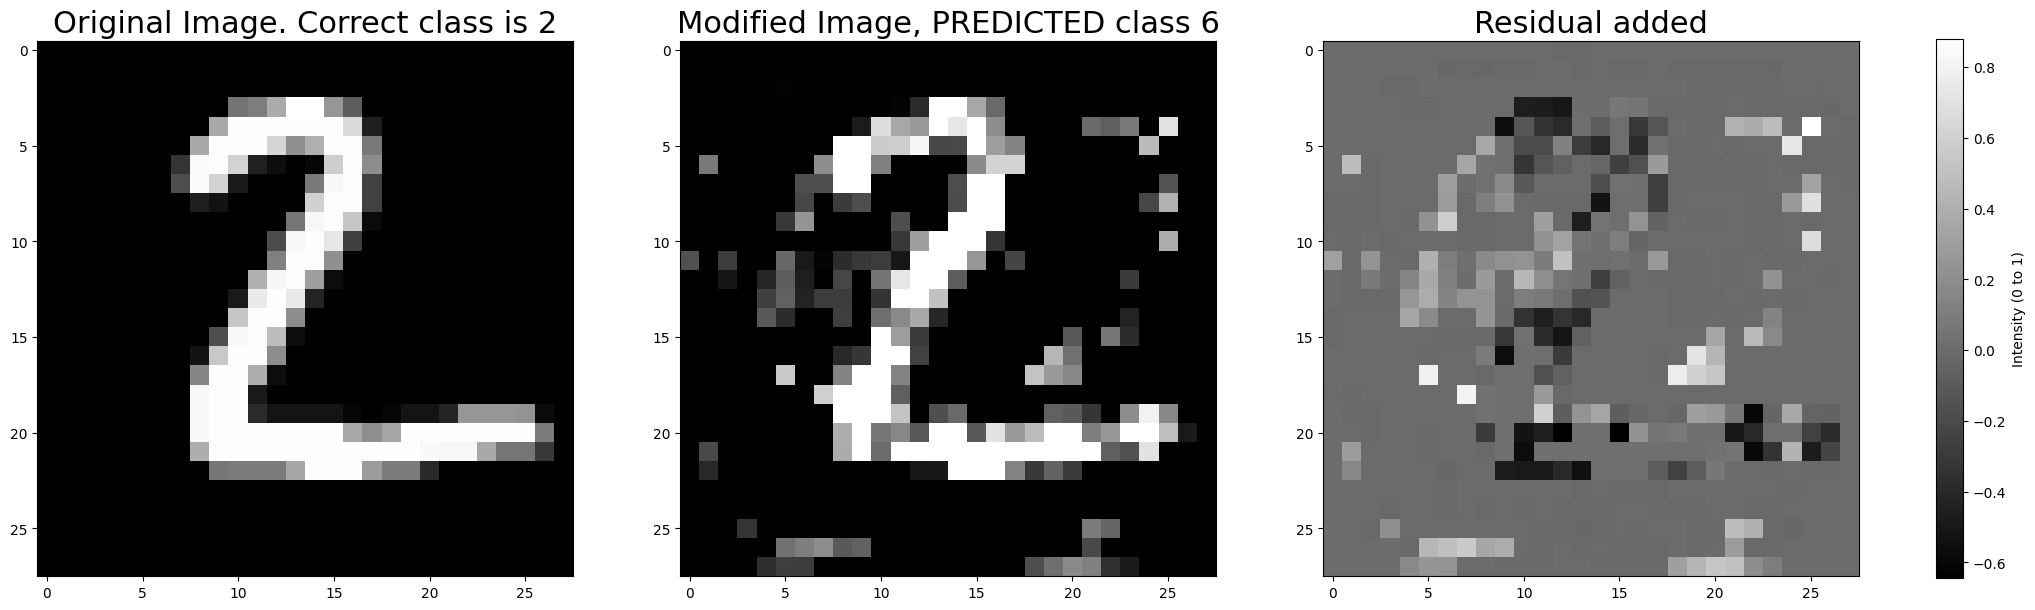

The true class is 2, the new class will be 7
Iter 20/300
Iter 40/300
Iter 60/300
Iter 80/300
Iter 100/300
Iter 120/300
Iter 140/300
Iter 160/300
Iter 180/300
Iter 200/300
Iter 220/300
Iter 240/300
Iter 260/300
Iter 280/300
Iter 300/300
Failed to find c satisfying f(x + r) = l within the maximum limit of iterations.
Norm Perturbation |r|: 77.94075775146484


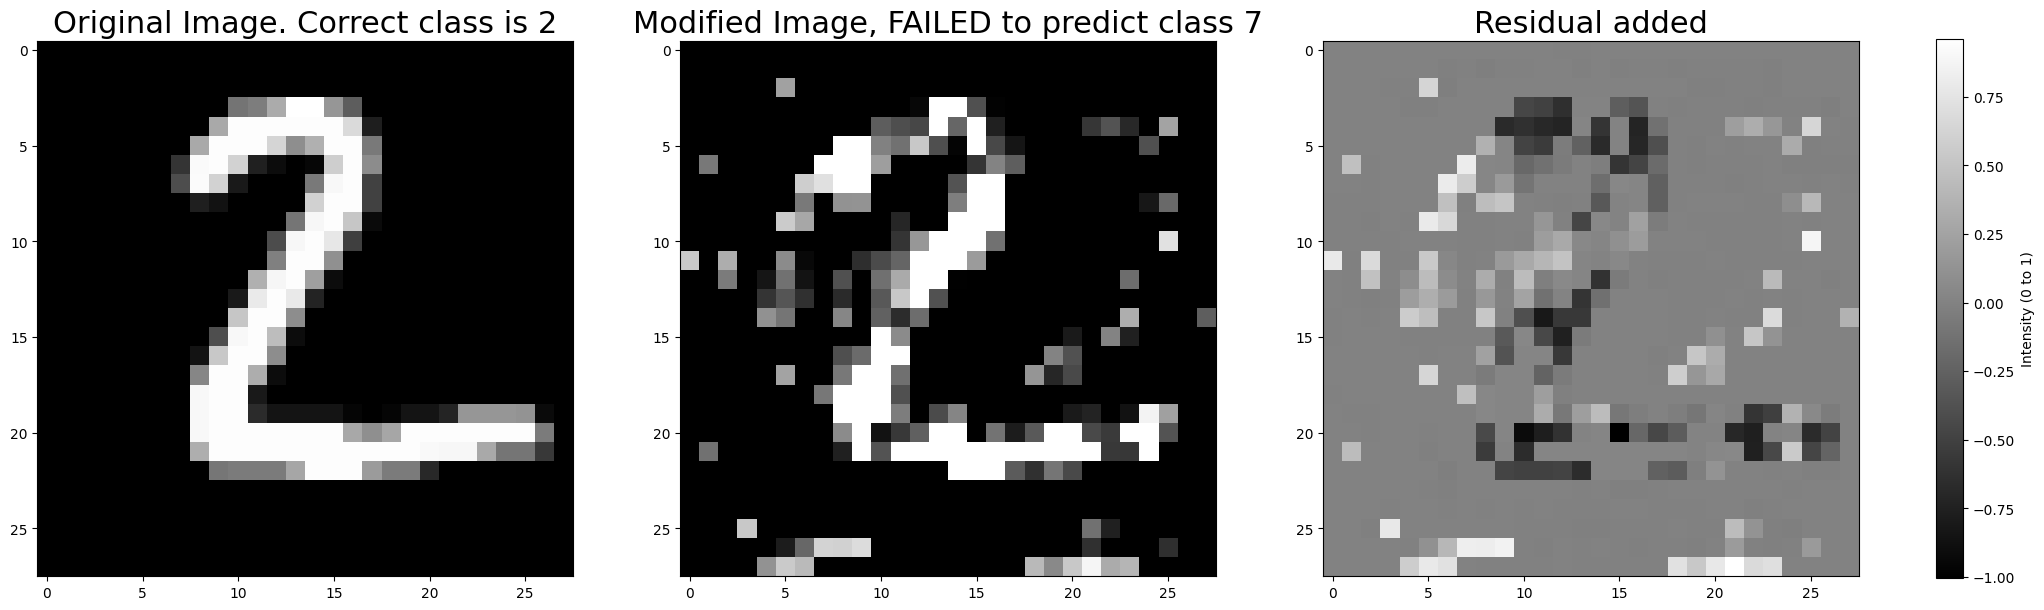

The true class is 2, the new class will be 8
Iter 20/300
Iter 40/300
Iter 60/300
Iter 80/300
Iter 100/300
Iter 120/300
Iter 140/300
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 154 iterations
Norm Perturbation |r|: 75.6915283203125


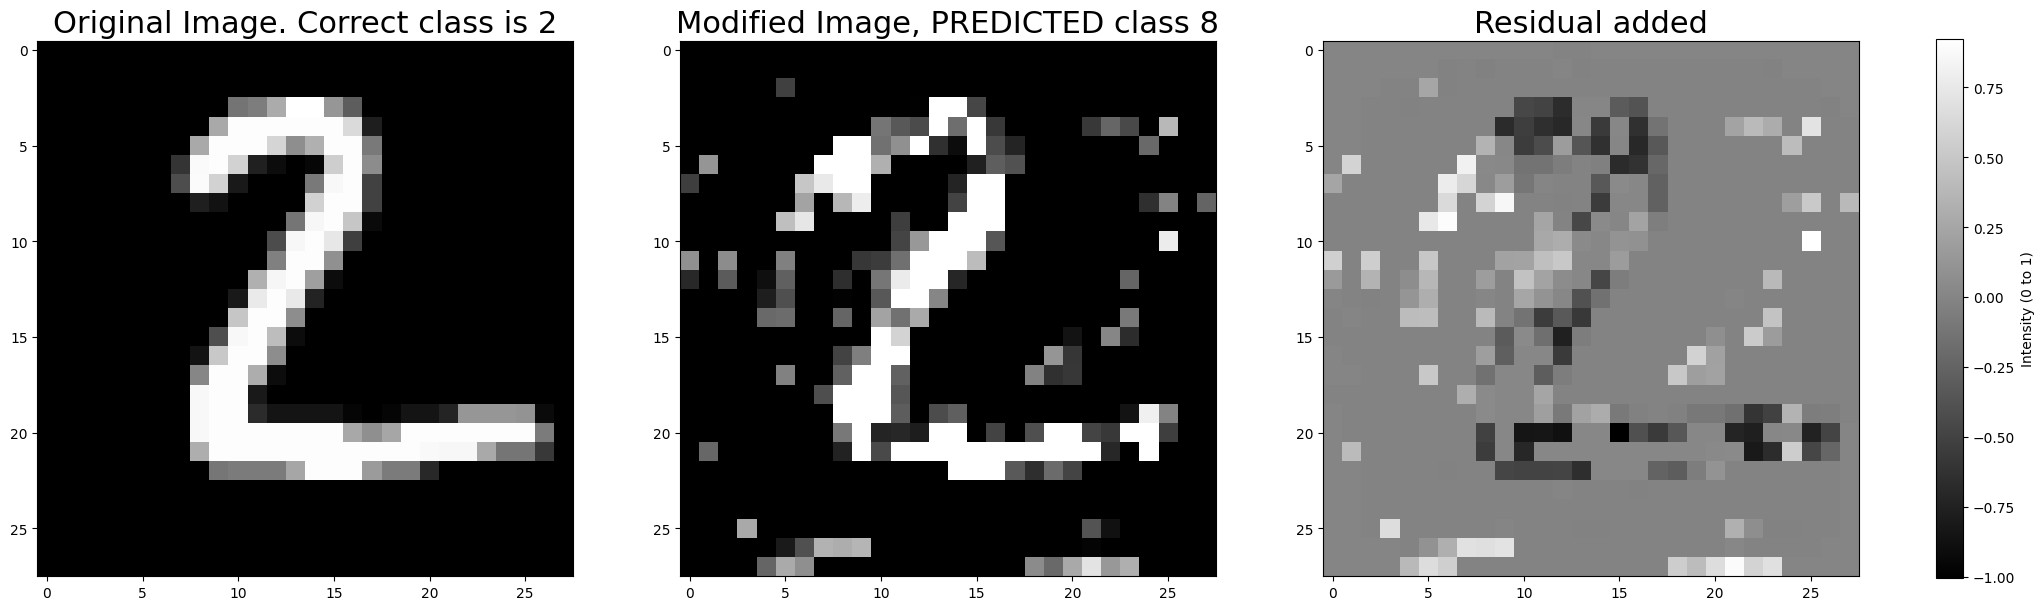

The true class is 2, the new class will be 9
Found c = 0.000001 satisfying f(x + r) = l
Optimization succeeded with c = 0.000001 in 11 iterations
Norm Perturbation |r|: 75.86316680908203


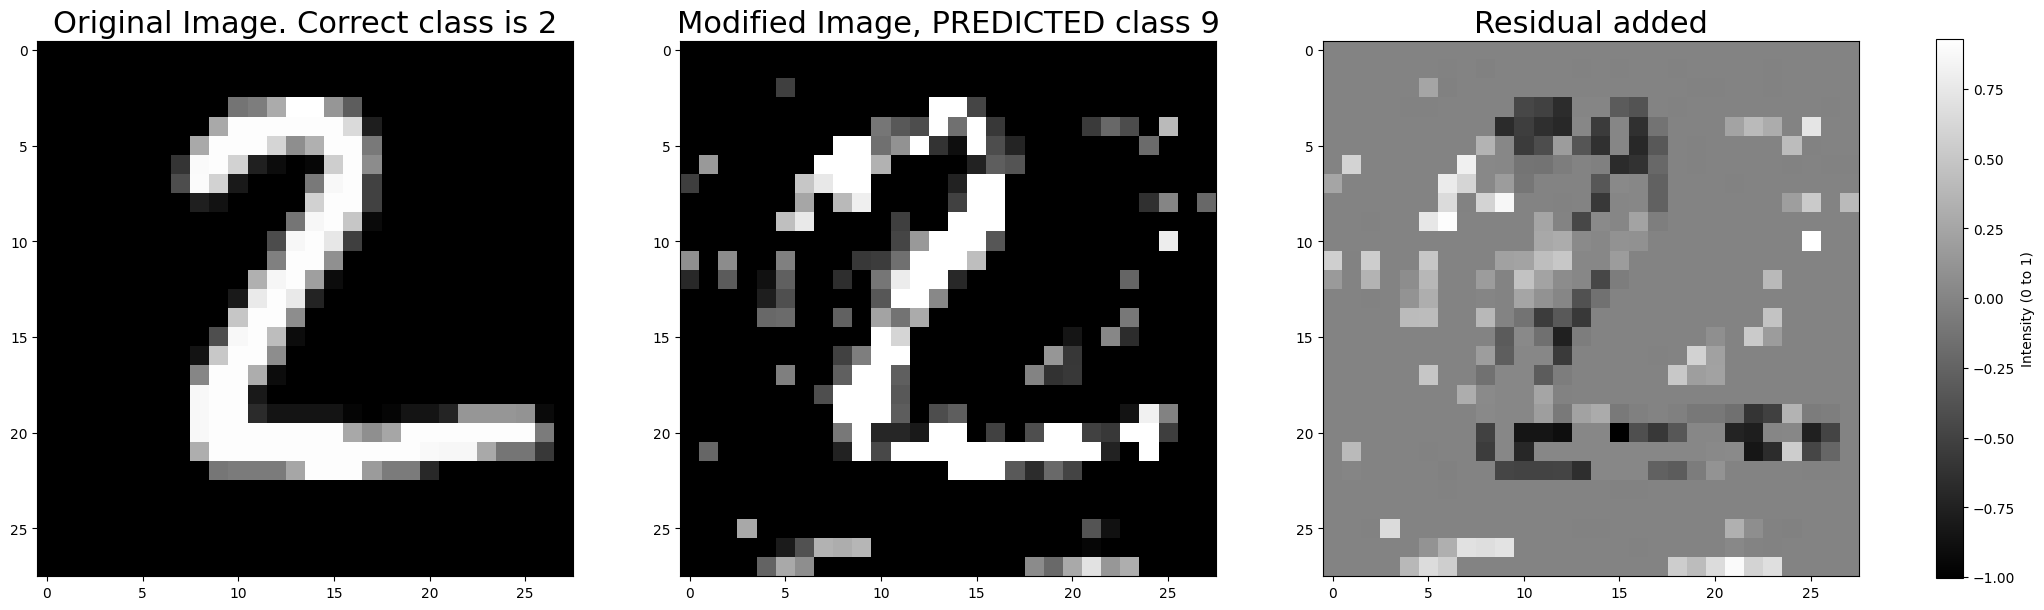

In [287]:
# Initialize r as zero
r = torch.zeros_like(testI, requires_grad=True, device=device)

# Define the optimizer (Adam)
lr_Adam = 0.001
optimizer = optim.Adam([r], lr=lr_Adam)

# Fix the value of c
c = initial_c

# Iterate over the target class labels
for o in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    label = o  # manually chosen target class label different from true one
    l = torch.tensor([label]).to(device)
    l = l.view(1)  # to have a batch size equal to 1 and work with CrossEntropy loss
    print(f"The true class is {testY}, the new class will be {l[0]}")

    # Define the loss function
    def objective(c, r, x, l):
        # Compute the perturbed image
        x_r = torch.clamp(x + r, 0, 1)  # Ensure x + r ∈ [0, 1]^m
    
        # Compute the prediction for the perturbed image
        pred = model(x_r)
    
        # Compute the loss
        loss = loss_model(pred, l) + c * torch.norm(r, p=1)
    
        return loss

    iter = 0
    while iter <= max_iter_search:
        optimizer.zero_grad()

        # Compute the objective loss
        loss = objective(c, r, testI, l)
        loss.backward()

        # Update r using Adam
        optimizer.step()

        # Evaluate the condition f(x + r) = l
        with torch.no_grad():
            x_r = torch.clamp(testI + r, 0, 1)  # Ensure x + r ∈ [0, 1]^m
            pred = model(x_r)
            predicted_label = torch.argmax(pred, dim=1)

        # Check if the condition f(x + r) = l is satisfied
        if predicted_label == l:
            print(f"Found c = {c:.6f} satisfying f(x + r) = l")
            break
        else:
            iter += 1

        if iter % 20 == 0:
            print(f'Iter {iter}/{max_iter_search}')

    if iter > max_iter_search:
        print("Failed to find c satisfying f(x + r) = l within the maximum limit of iterations.")
        print(f"Norm Perturbation |r|: {torch.norm(r, p=1)}")
        plot_results(testI, r, x_r, testY, l, fail=True)
    else:
        print(f"Optimization succeeded with c = {c:.6f} in {iter} iterations")
        print(f"Norm Perturbation |r|: {torch.norm(r, p=1)}")
        plot_results(testI, r, x_r, testY, l, fail=False)


#### Estimating Both c and r

The true class is 2, the new class will be 0
Iter 20/300
Iter 40/300
Iter 60/300
Iter 80/300
Found c = -0.010796 satisfying f(x + r) = l
Optimization succeeded with c = -0.010796 in 83 iterations
Norm Perturbation |r|: 49.157493591308594


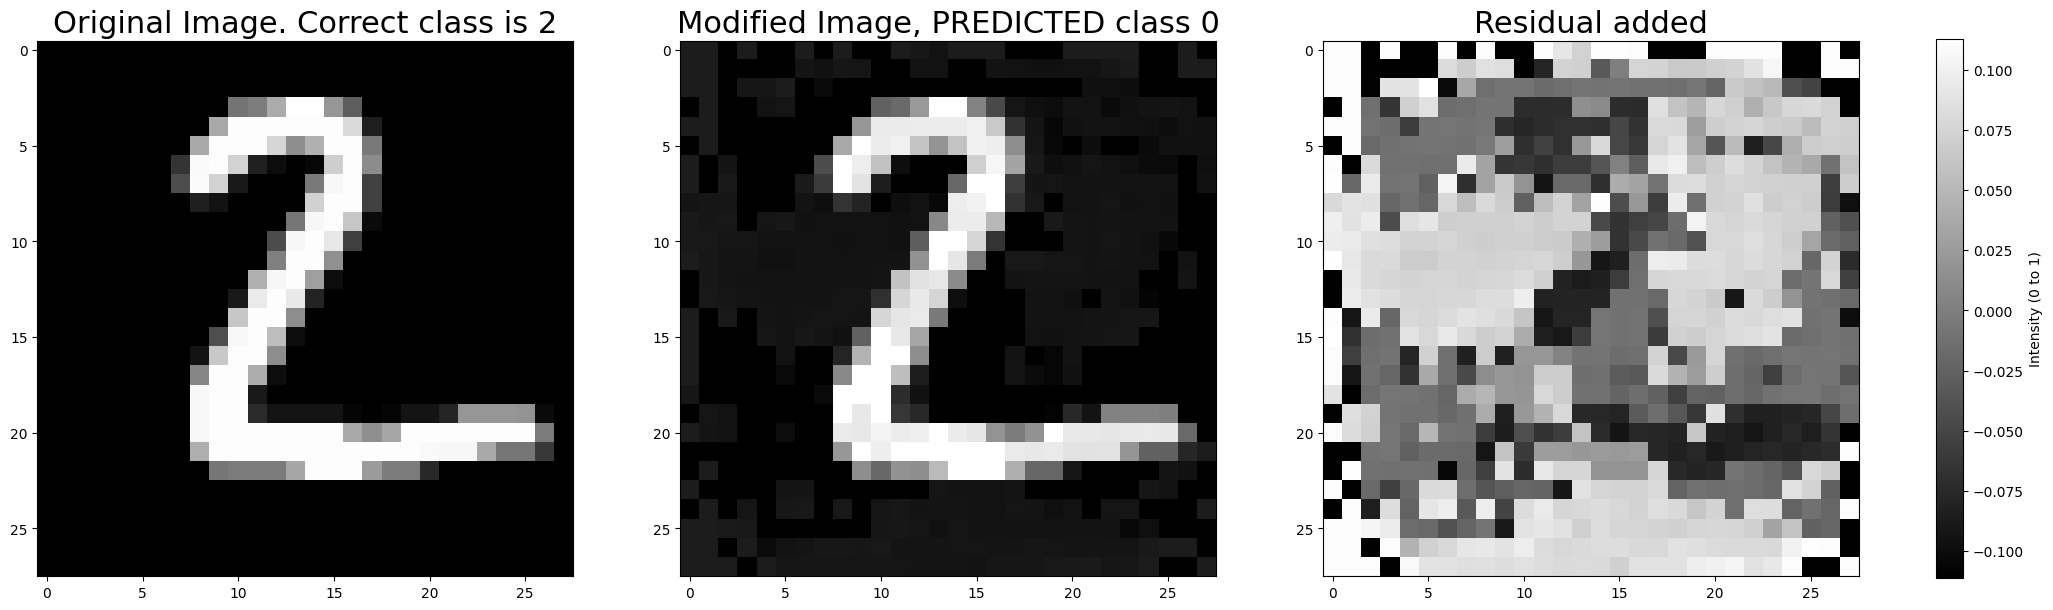

The true class is 2, the new class will be 1
Iter 20/300
Iter 40/300
Iter 60/300
Iter 80/300
Iter 100/300
Iter 120/300
Iter 140/300
Found c = -0.032294 satisfying f(x + r) = l
Optimization succeeded with c = -0.032294 in 143 iterations
Norm Perturbation |r|: 109.41167449951172


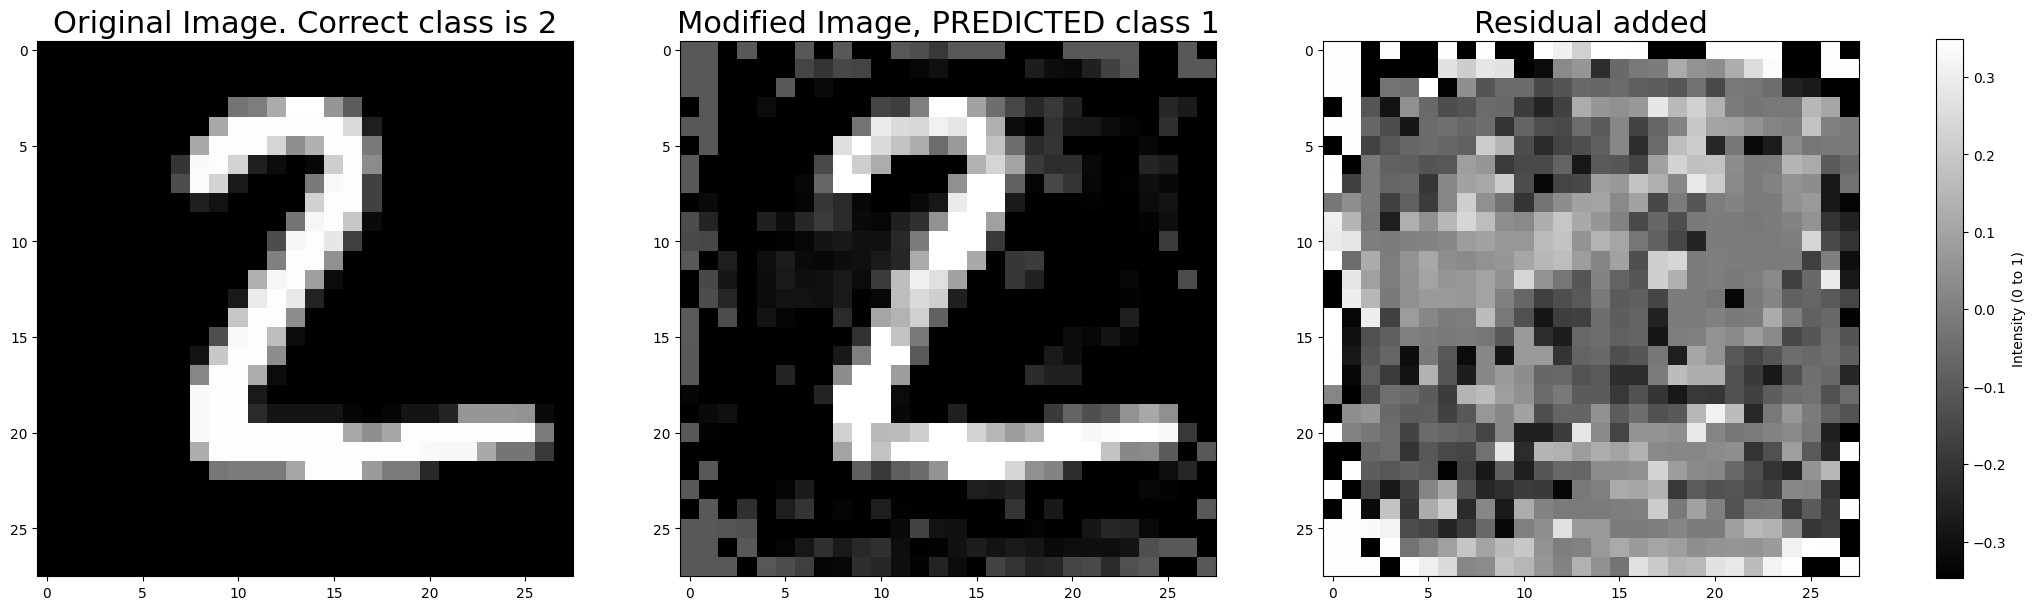

The true class is 2, the new class will be 2
Found c = -0.034233 satisfying f(x + r) = l
Optimization succeeded with c = -0.034233 in 11 iterations
Norm Perturbation |r|: 115.50662994384766


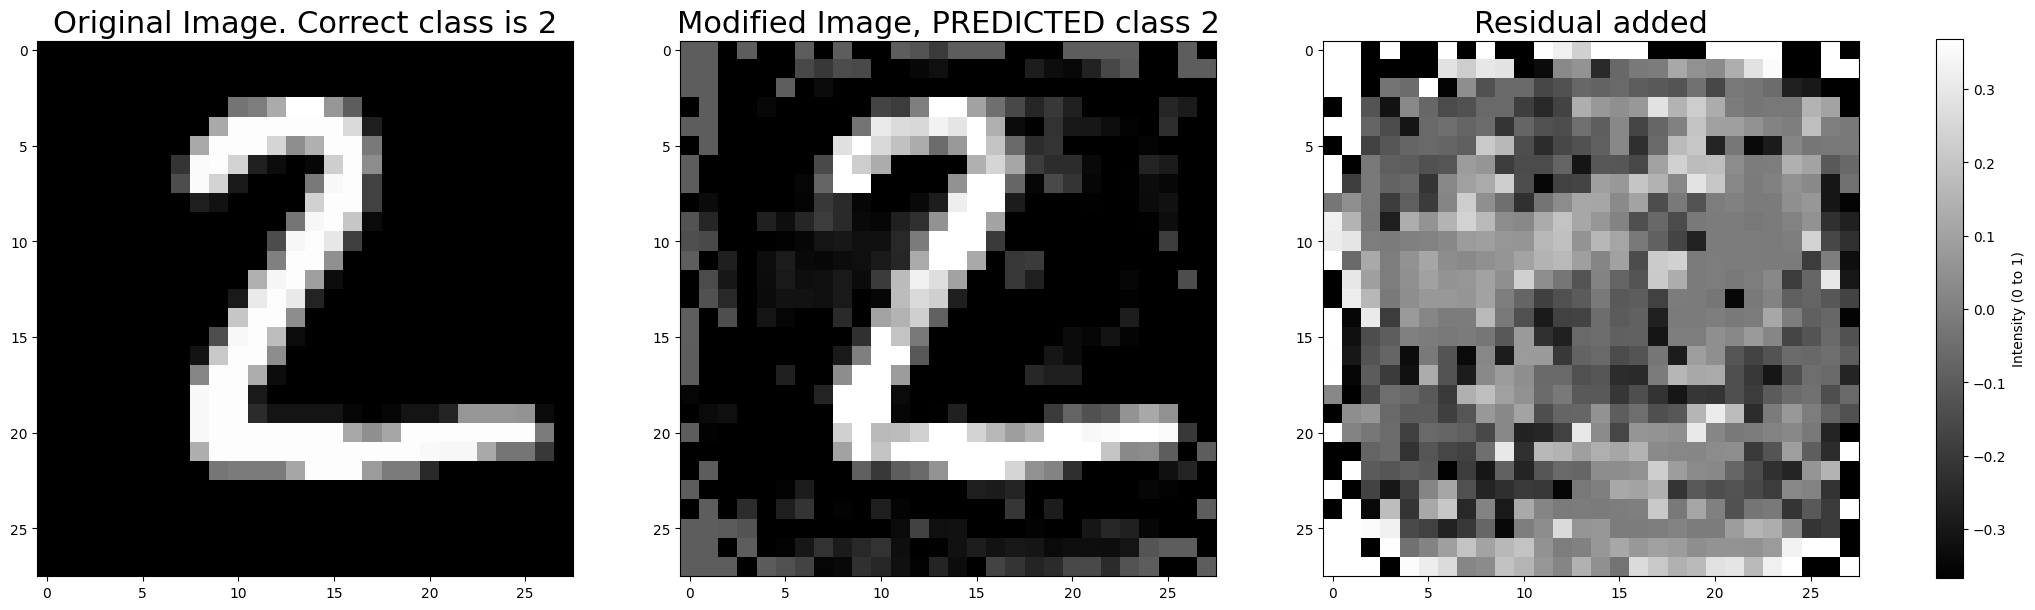

The true class is 2, the new class will be 3
Iter 20/300
Found c = -0.038309 satisfying f(x + r) = l
Optimization succeeded with c = -0.038309 in 24 iterations
Norm Perturbation |r|: 130.4135284423828


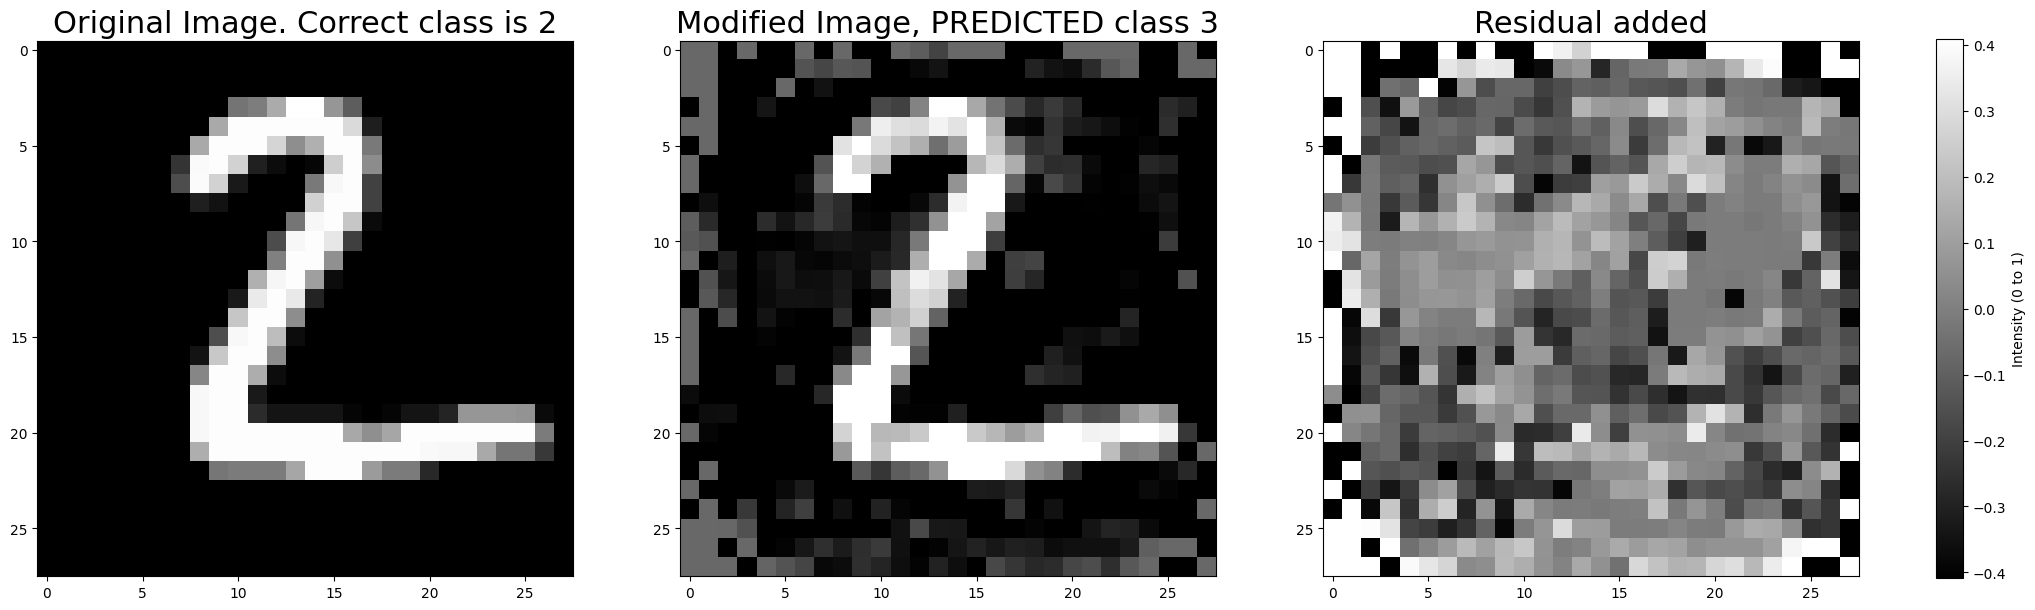

The true class is 2, the new class will be 4
Iter 20/300
Iter 40/300
Iter 60/300
Iter 80/300
Iter 100/300
Iter 120/300
Iter 140/300
Iter 160/300
Iter 180/300
Iter 200/300
Iter 220/300
Iter 240/300
Iter 260/300
Iter 280/300
Iter 300/300
Failed to find c satisfying f(x + r) = l within the maximum limit of iterations.
Norm Perturbation |r|: 349.33135986328125


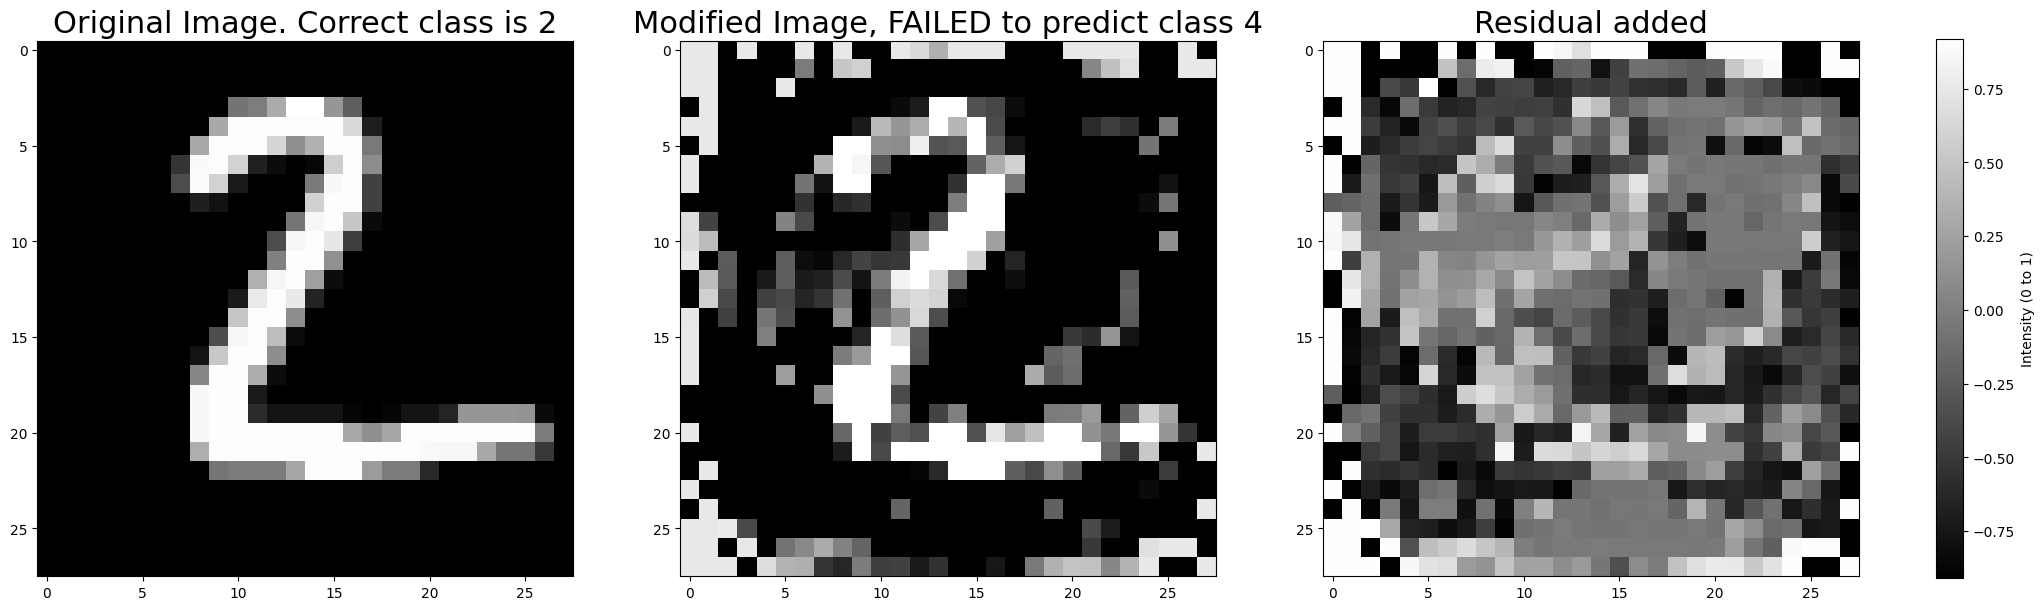

The true class is 2, the new class will be 5
Iter 20/300
Iter 40/300
Iter 60/300
Iter 80/300
Iter 100/300
Iter 120/300
Iter 140/300
Iter 160/300
Iter 180/300
Iter 200/300
Iter 220/300
Iter 240/300
Iter 260/300
Iter 280/300
Iter 300/300
Failed to find c satisfying f(x + r) = l within the maximum limit of iterations.
Norm Perturbation |r|: 596.8838500976562


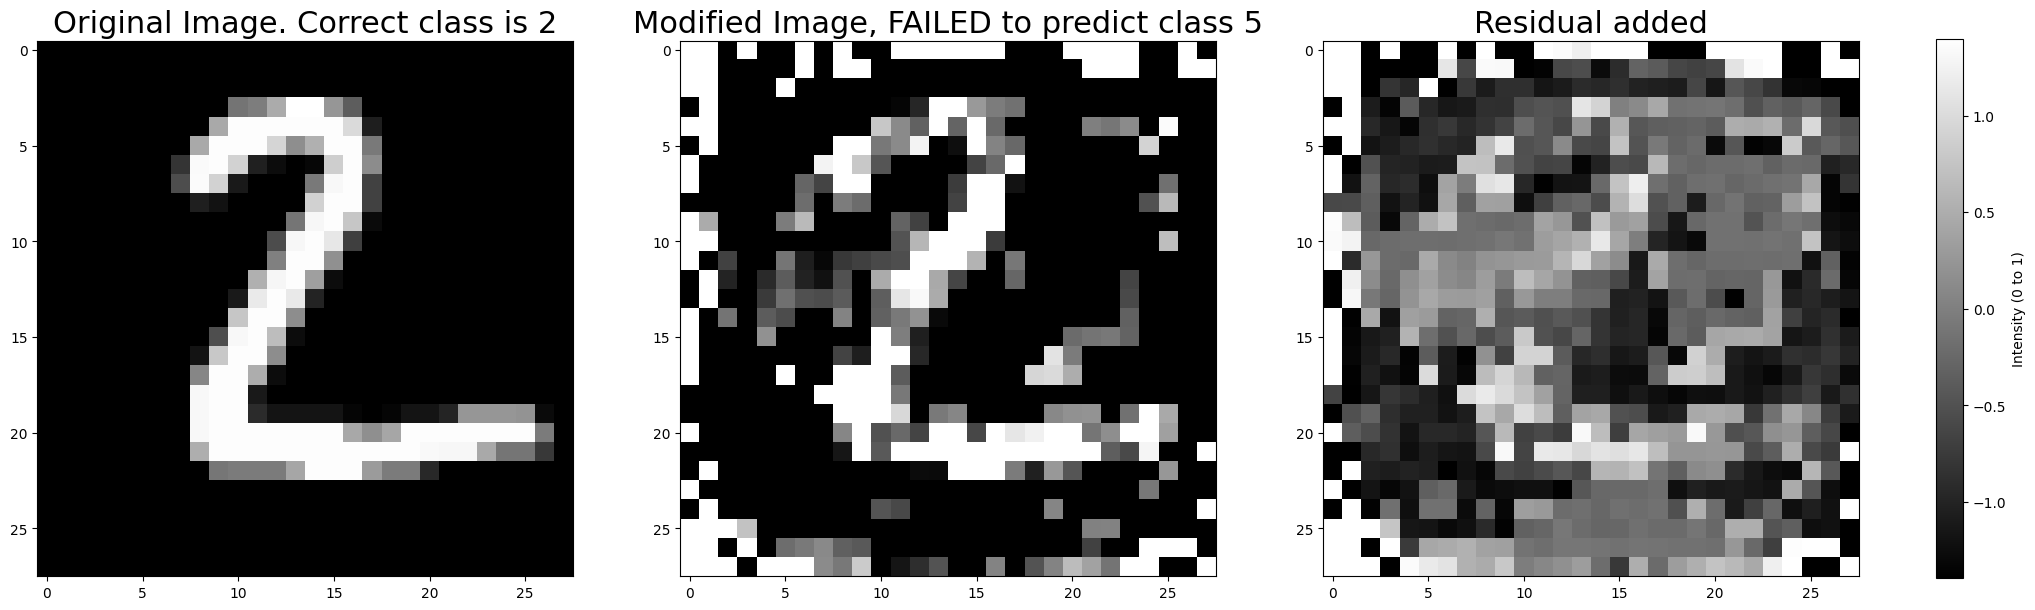

The true class is 2, the new class will be 6
Found c = -0.142681 satisfying f(x + r) = l
Optimization succeeded with c = -0.142681 in 12 iterations
Norm Perturbation |r|: 608.2720947265625


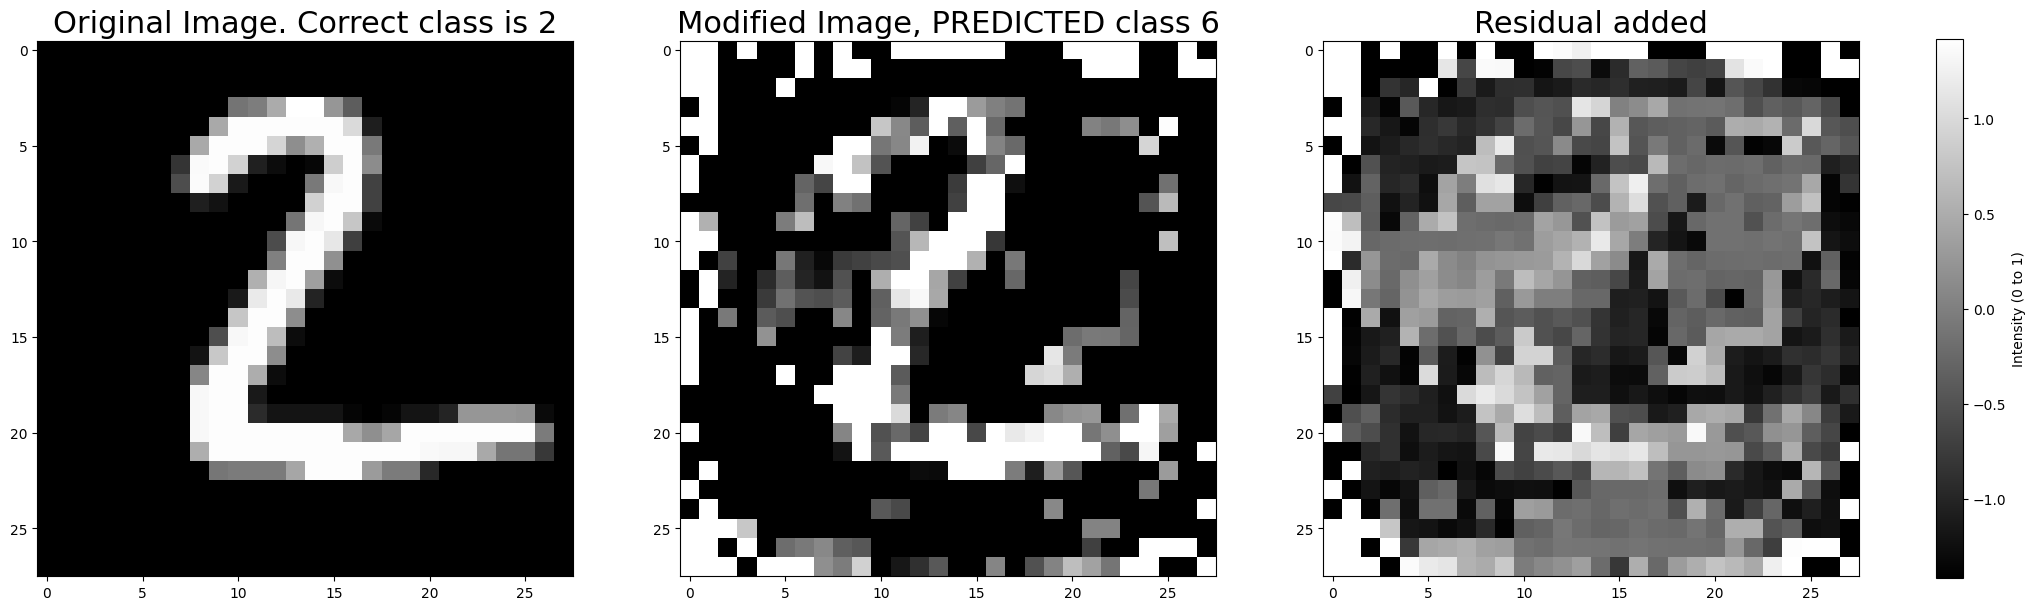

The true class is 2, the new class will be 7
Iter 20/300
Iter 40/300
Iter 60/300
Iter 80/300
Iter 100/300
Iter 120/300
Iter 140/300
Iter 160/300
Found c = -0.170968 satisfying f(x + r) = l
Optimization succeeded with c = -0.170968 in 170 iterations
Norm Perturbation |r|: 773.847900390625


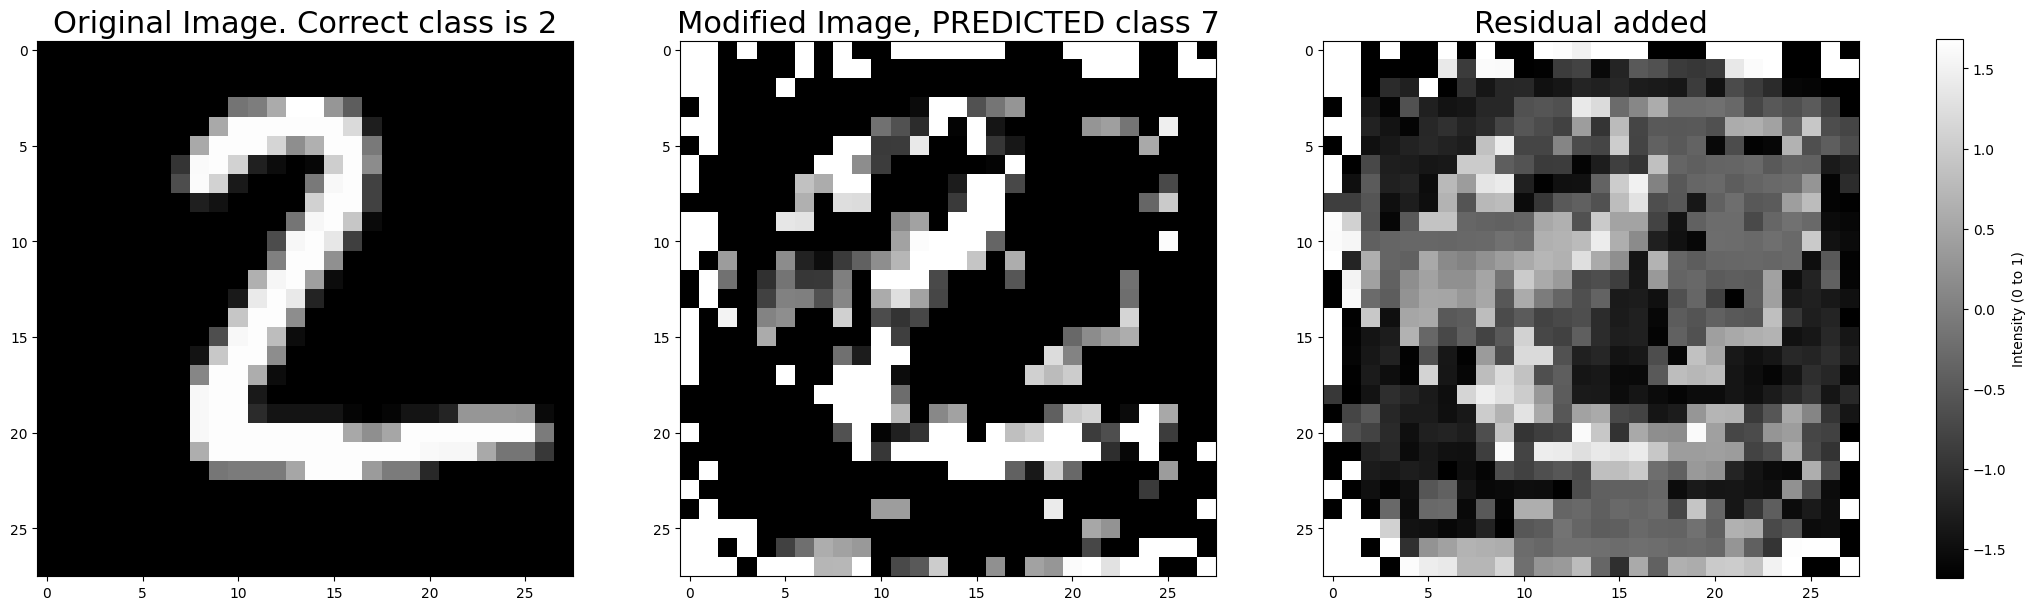

The true class is 2, the new class will be 8
Iter 20/300
Iter 40/300
Iter 60/300
Iter 80/300
Iter 100/300
Iter 120/300
Iter 140/300
Iter 160/300
Iter 180/300
Iter 200/300
Iter 220/300
Iter 240/300
Iter 260/300
Iter 280/300
Iter 300/300
Failed to find c satisfying f(x + r) = l within the maximum limit of iterations.
Norm Perturbation |r|: 1044.446533203125


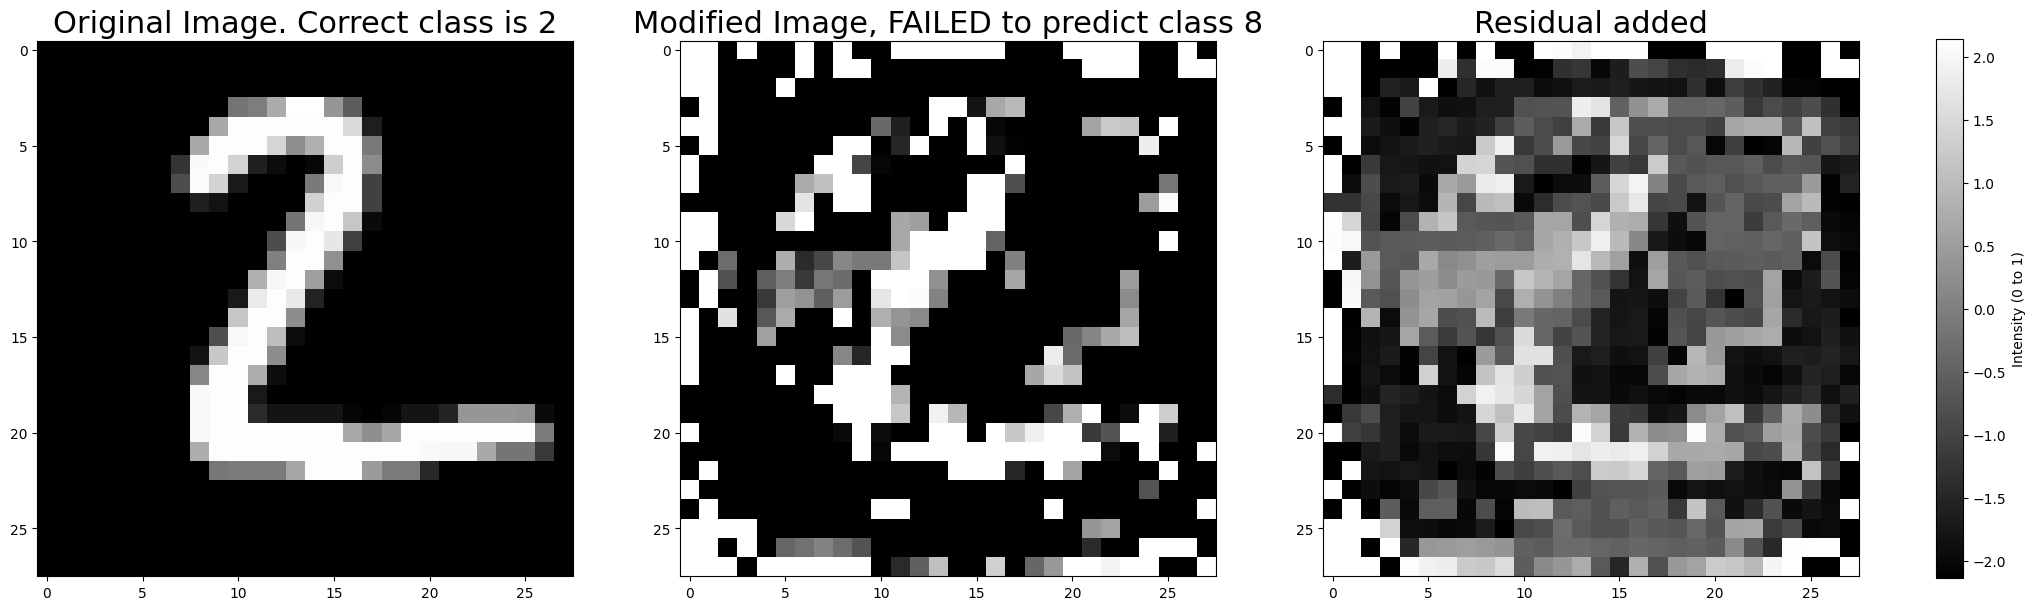

The true class is 2, the new class will be 9
Found c = -0.219405 satisfying f(x + r) = l
Optimization succeeded with c = -0.219405 in 0 iterations
Norm Perturbation |r|: 1045.377197265625


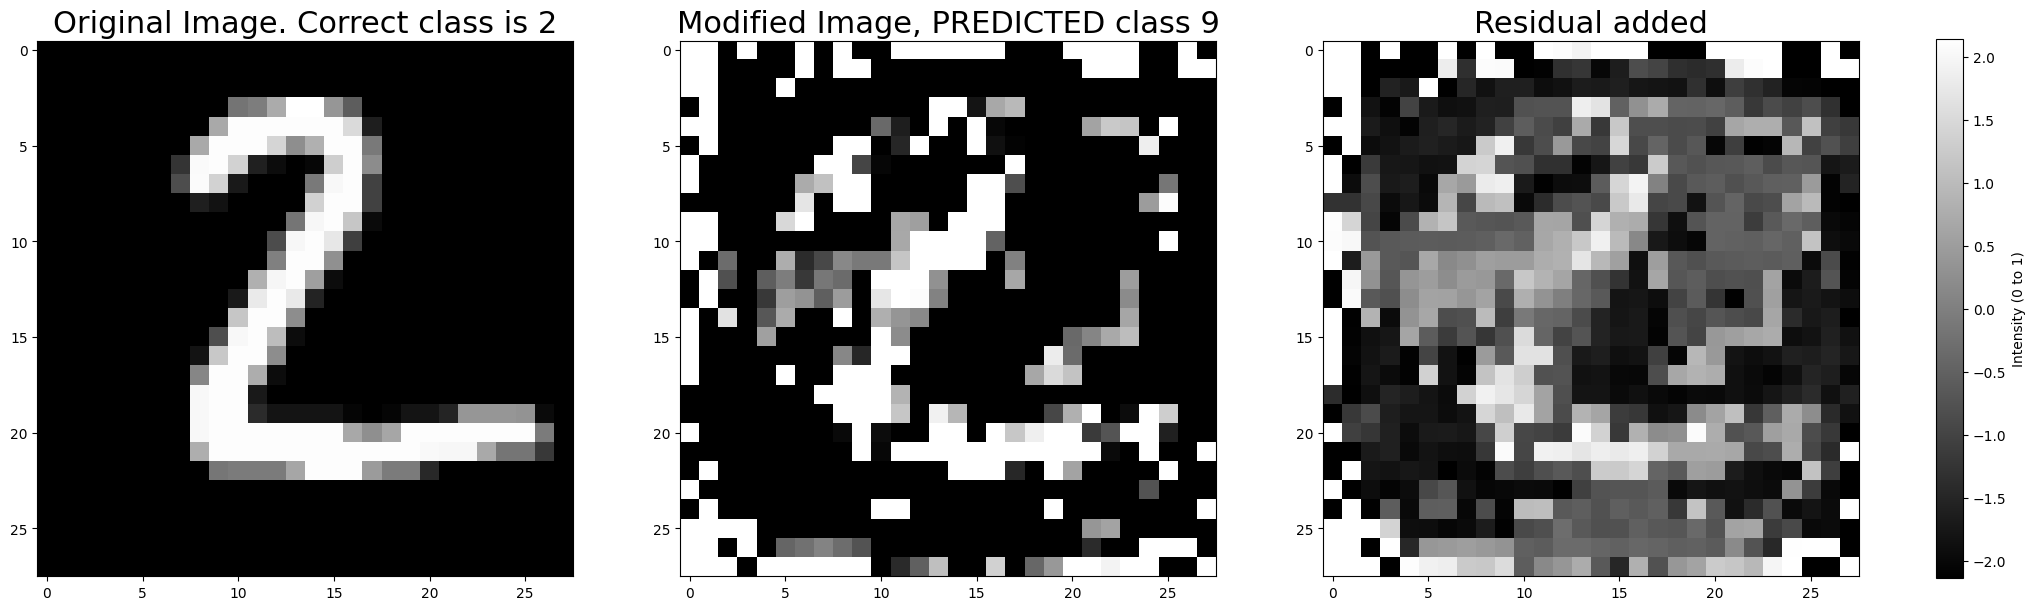

In [298]:
# Initialize r and c as trainable parameters
r = torch.zeros_like(testI, requires_grad=True, device=device)
c = torch.tensor(initial_c, requires_grad=True, device=device)

# Define the optimizer (Adam)
optimizer = optim.Adam([
    {'params': r, 'lr': 0.001},  # Learning rate for 'r'
    {'params': c, 'lr': 0.0001}  # Learning rate for 'c'
])


# Iterate over the target class labels
for o in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    label = o  # manually chosen target class label different from true one
    l = torch.tensor([label]).to(device)
    l = l.view(1)  # to have a batch size equal to 1 and work with CrossEntropy loss
    print(f"The true class is {testY}, the new class will be {l[0]}")

    # Define the loss function
    def objective(r, c, x, l):
        # Compute the perturbed image
        x_r = torch.clamp(x + r, 0, 1)  # Ensure x + r ∈ [0, 1]^m
    
        # Compute the prediction for the perturbed image
        pred = model(x_r)
    
        # Compute the loss
        loss = loss_model(pred, l) + c * torch.norm(r, p=1)
    
        return loss

    iter = 0
    while iter <= max_iter_search:
        optimizer.zero_grad()

        # Compute the objective loss
        loss = objective(r, c, testI, l)
        loss.backward()

        # Update r and c using Adam
        optimizer.step()

        # Evaluate the condition f(x + r) = l
        with torch.no_grad():
            x_r = torch.clamp(testI + r, 0, 1)  # Ensure x + r ∈ [0, 1]^m
            pred = model(x_r)
            predicted_label = torch.argmax(pred, dim=1)

        # Check if the condition f(x + r) = l is satisfied
        if predicted_label == l:
            print(f"Found c = {c.item():.6f} satisfying f(x + r) = l")
            break
        else:
            iter += 1

        if iter % 20 == 0:
            print(f'Iter {iter}/{max_iter_search}')

    if iter > max_iter_search:
        print("Failed to find c satisfying f(x + r) = l within the maximum limit of iterations.")
        print(f"Norm Perturbation |r|: {torch.norm(r, p=1)}")
        plot_results(testI, r, x_r, testY, l, fail=True)
    else:
        print(f"Optimization succeeded with c = {c.item():.6f} in {iter} iterations")
        print(f"Norm Perturbation |r|: {torch.norm(r, p=1)}")
        plot_results(testI, r, x_r, testY, l, fail=False)


> The first approach (fixing c) is simpler and works well, especially if the goal is to focus on the perturbation r while keeping c fixed. The second approach (optimizing both r and c) does not work all the time, but it introduces more complexity and could lead to unstable optimization because c is not well controlled. We can also see that with the first approach, the magnitude of r is smaller, which produces less noticeable adversarial effects compared to the second approach.

> Adding a regularization term to the loss function is essential to control the magnitude of c. A common choice is the L1 norm (torch.norm(r, p=1)) as it promotes sparsity in the perturbation, making it more interpretable.

#### regularization term  to control the magnitude of c

The true class is 2, the new class will be 0
Iter 20/300
Iter 40/300
Iter 60/300
Iter 80/300
Found c = -0.055823 satisfying f(x + r) = l
Optimization succeeded with c = -0.055823 in 84 iterations
Norm Perturbation |r|: 58.06818389892578


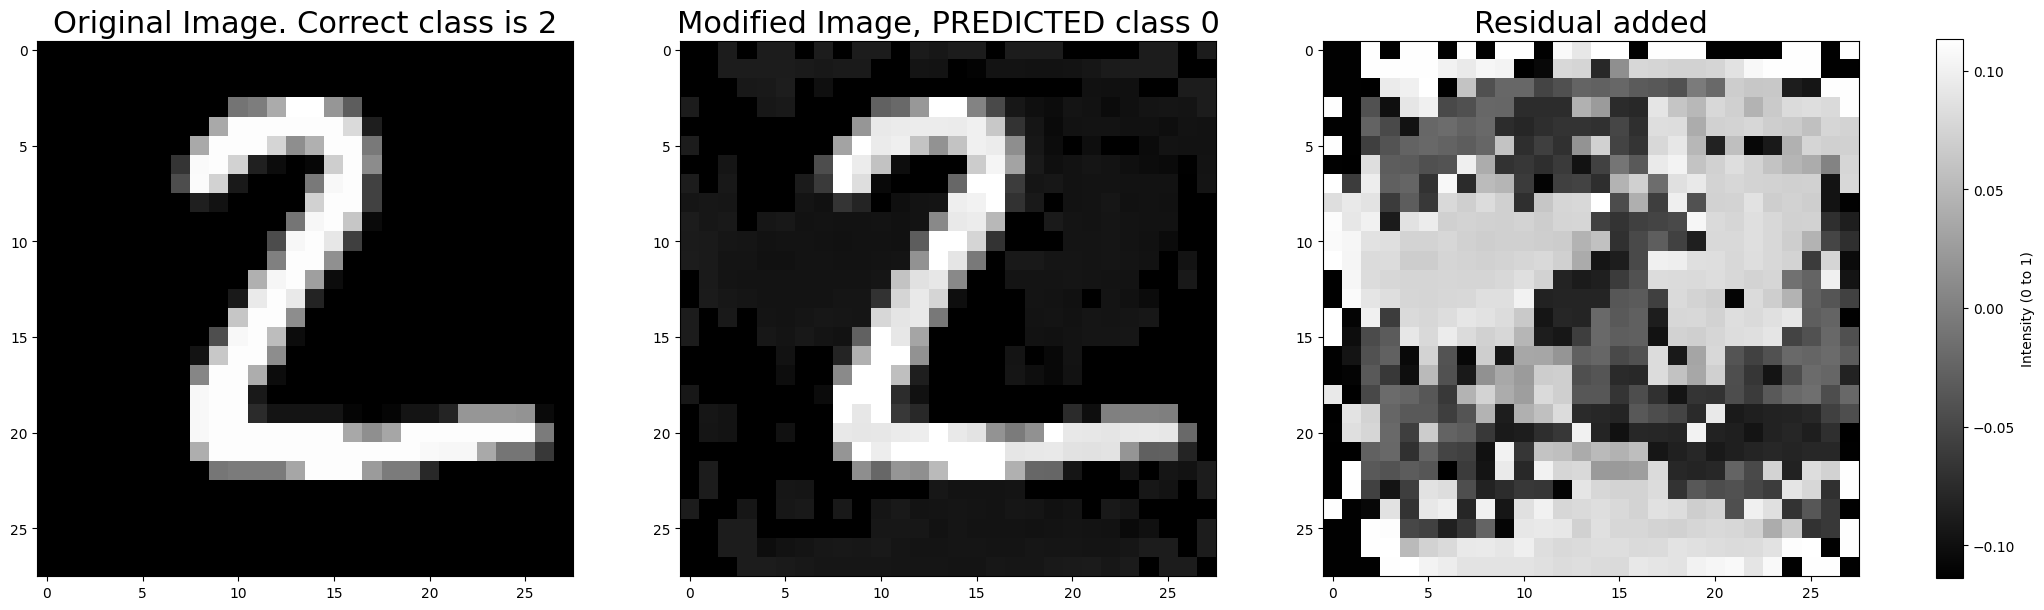

The true class is 2, the new class will be 1
Iter 20/300
Iter 40/300
Iter 60/300
Iter 80/300
Iter 100/300
Iter 120/300
Iter 140/300
Found c = -0.172674 satisfying f(x + r) = l
Optimization succeeded with c = -0.172674 in 148 iterations
Norm Perturbation |r|: 153.89682006835938


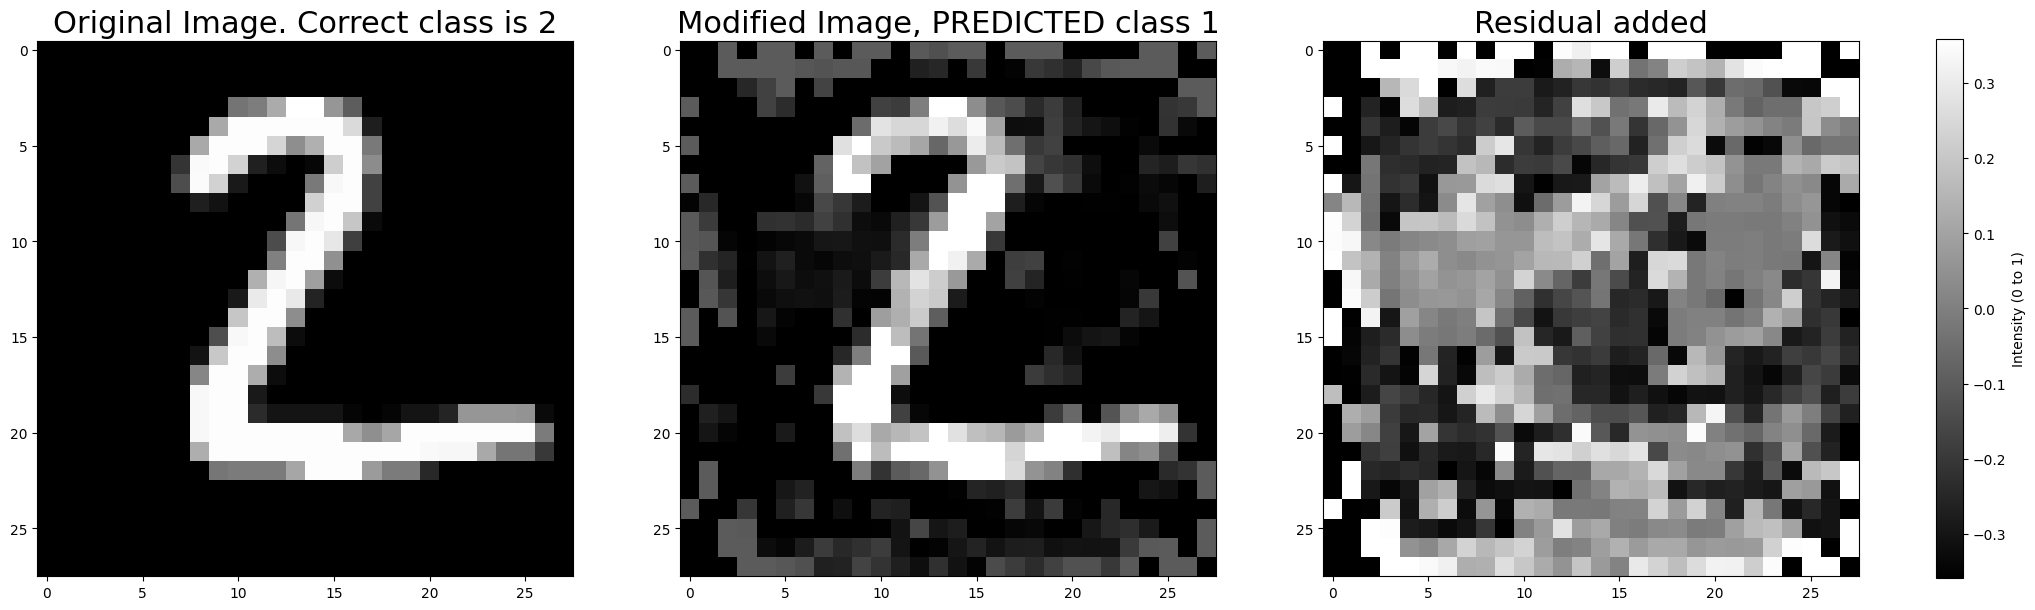

The true class is 2, the new class will be 2
Found c = -0.184351 satisfying f(x + r) = l
Optimization succeeded with c = -0.184351 in 13 iterations
Norm Perturbation |r|: 165.08331298828125


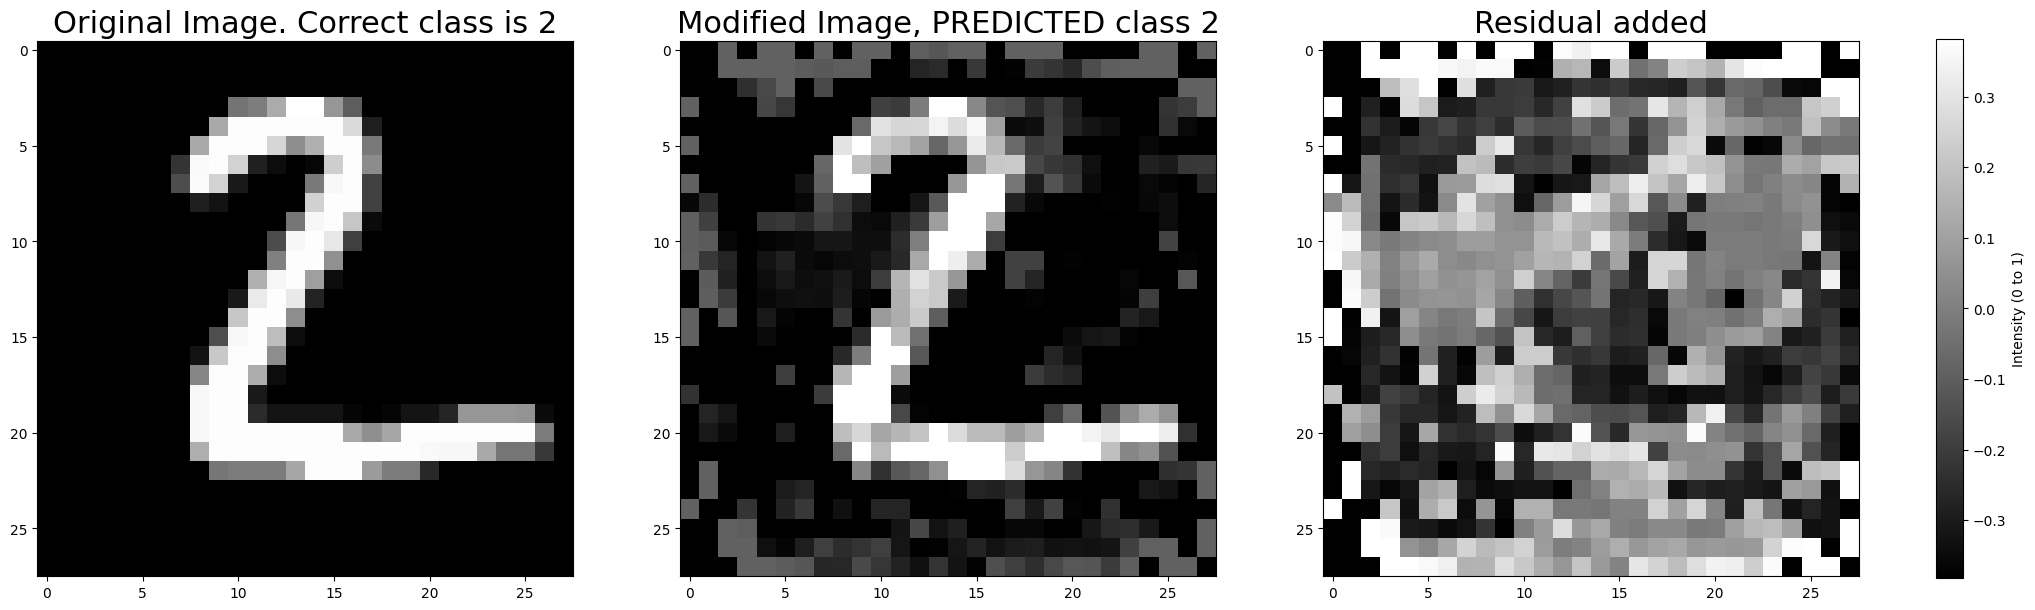

The true class is 2, the new class will be 3
Found c = -0.199472 satisfying f(x + r) = l
Optimization succeeded with c = -0.199472 in 17 iterations
Norm Perturbation |r|: 181.14341735839844


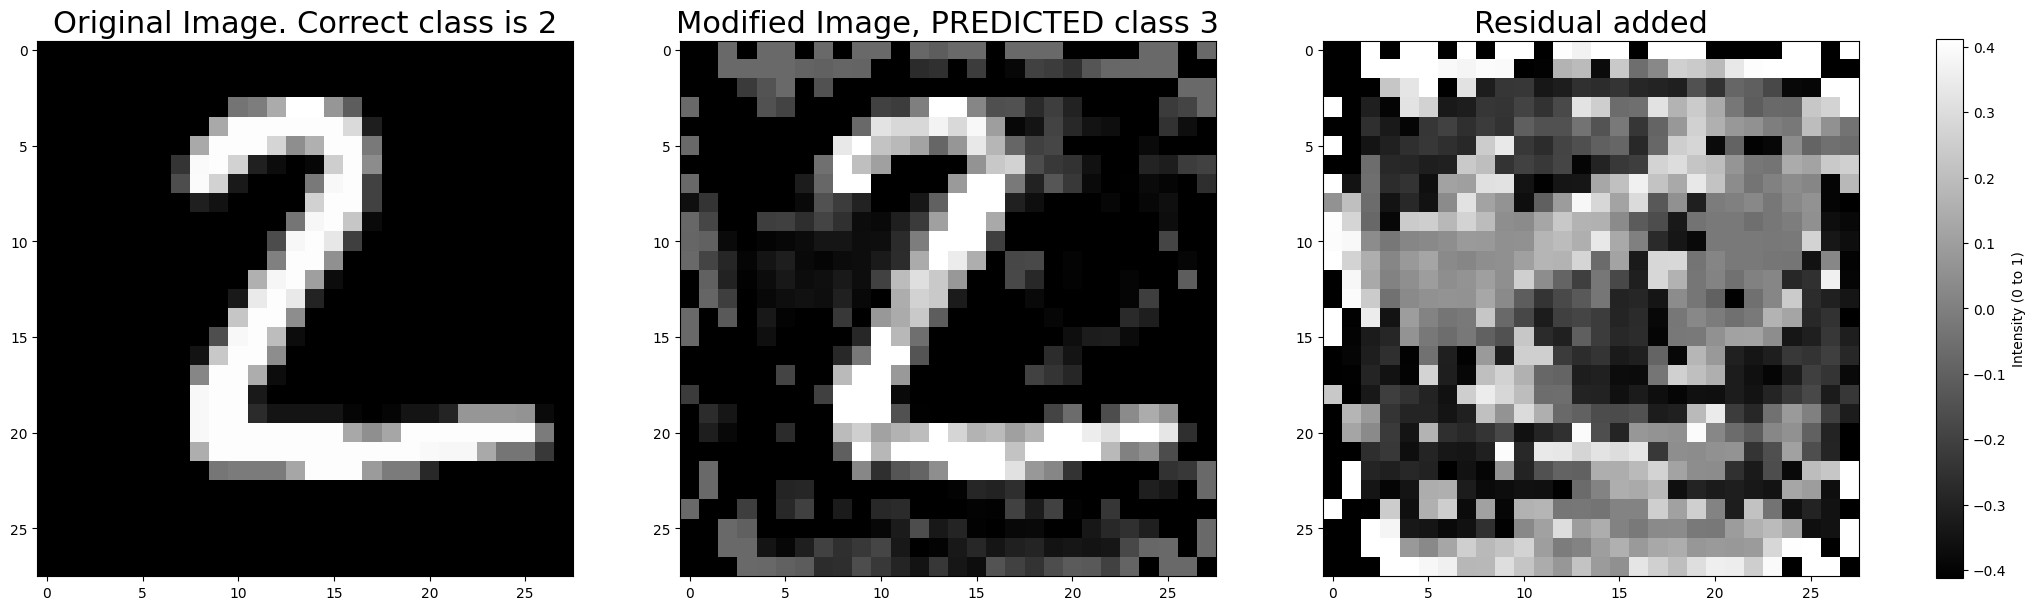

The true class is 2, the new class will be 4
Iter 20/300
Iter 40/300
Iter 60/300
Iter 80/300
Iter 100/300
Iter 120/300
Iter 140/300
Iter 160/300
Iter 180/300
Iter 200/300
Iter 220/300
Iter 240/300
Iter 260/300
Iter 280/300
Iter 300/300
Failed to find c satisfying f(x + r) = l within the maximum limit of iterations.
Norm Perturbation |r|: 474.04205322265625


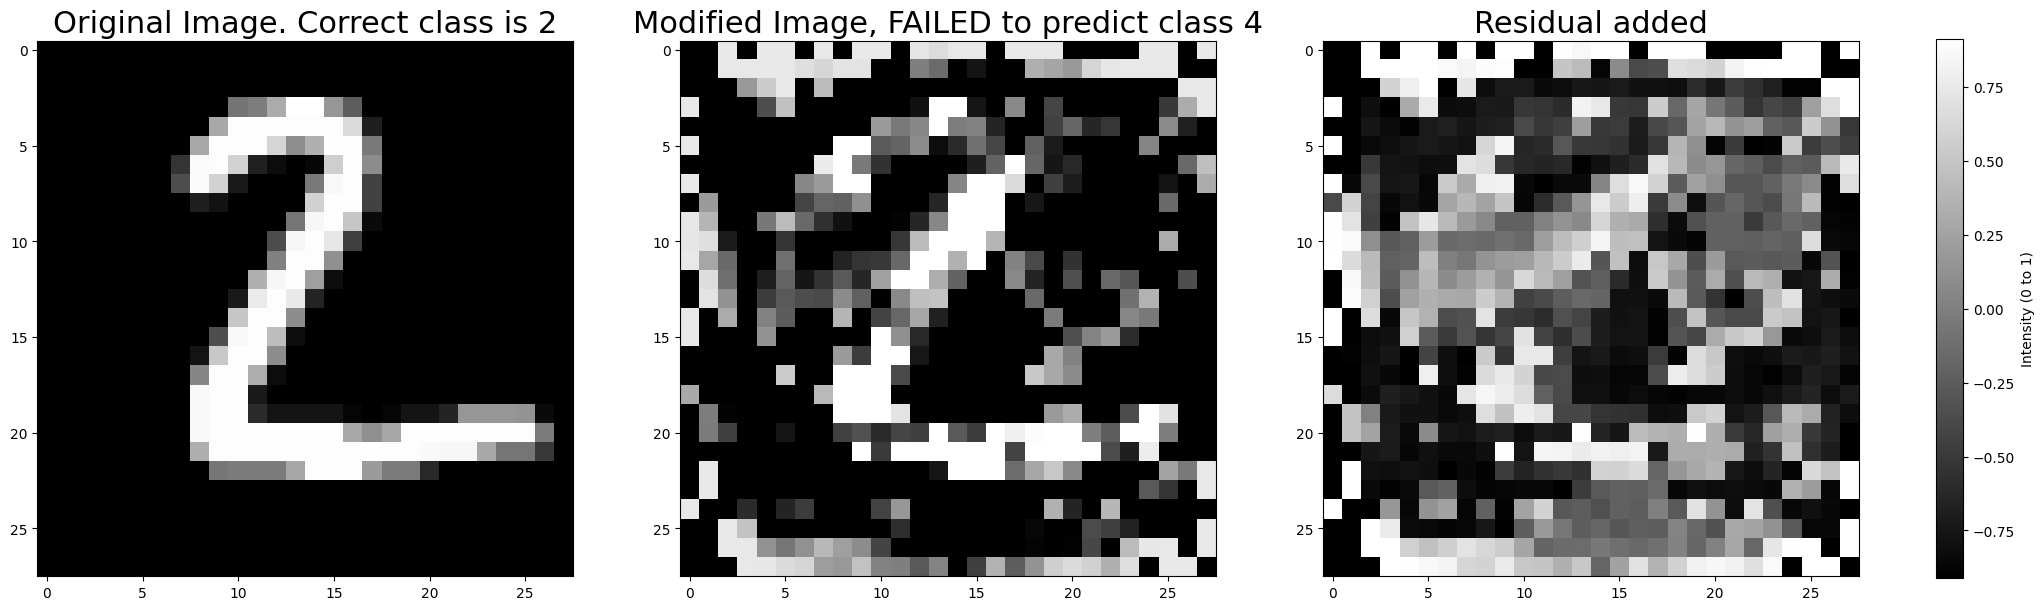

The true class is 2, the new class will be 5
Iter 20/300
Iter 40/300
Iter 60/300
Found c = -0.513030 satisfying f(x + r) = l
Optimization succeeded with c = -0.513030 in 64 iterations
Norm Perturbation |r|: 551.4691162109375


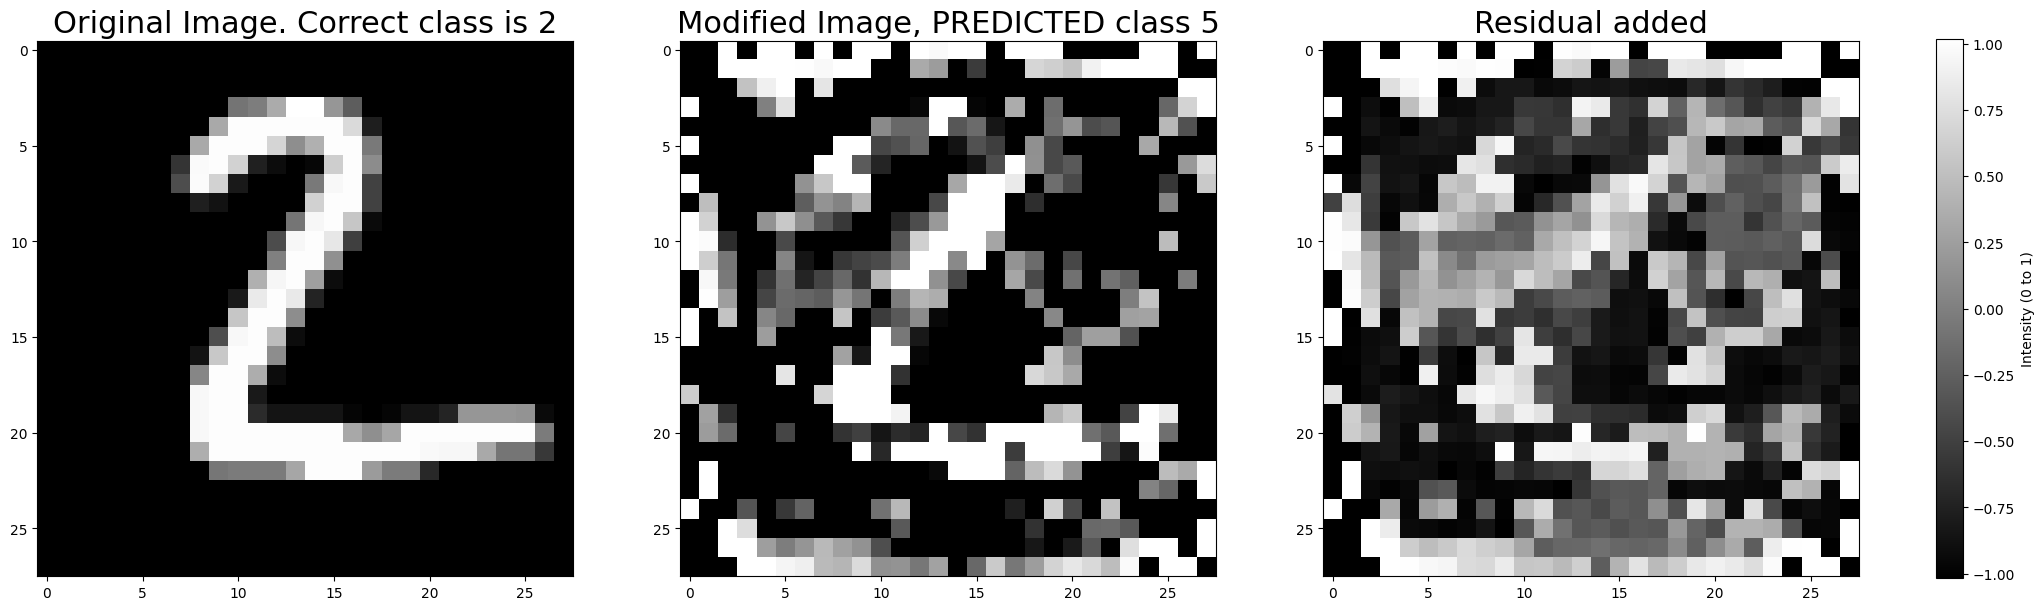

The true class is 2, the new class will be 6
Iter 20/300
Iter 40/300
Iter 60/300
Iter 80/300
Iter 100/300
Iter 120/300
Iter 140/300
Iter 160/300
Iter 180/300
Iter 200/300
Iter 220/300
Iter 240/300
Iter 260/300
Iter 280/300
Iter 300/300
Failed to find c satisfying f(x + r) = l within the maximum limit of iterations.
Norm Perturbation |r|: 881.7518920898438


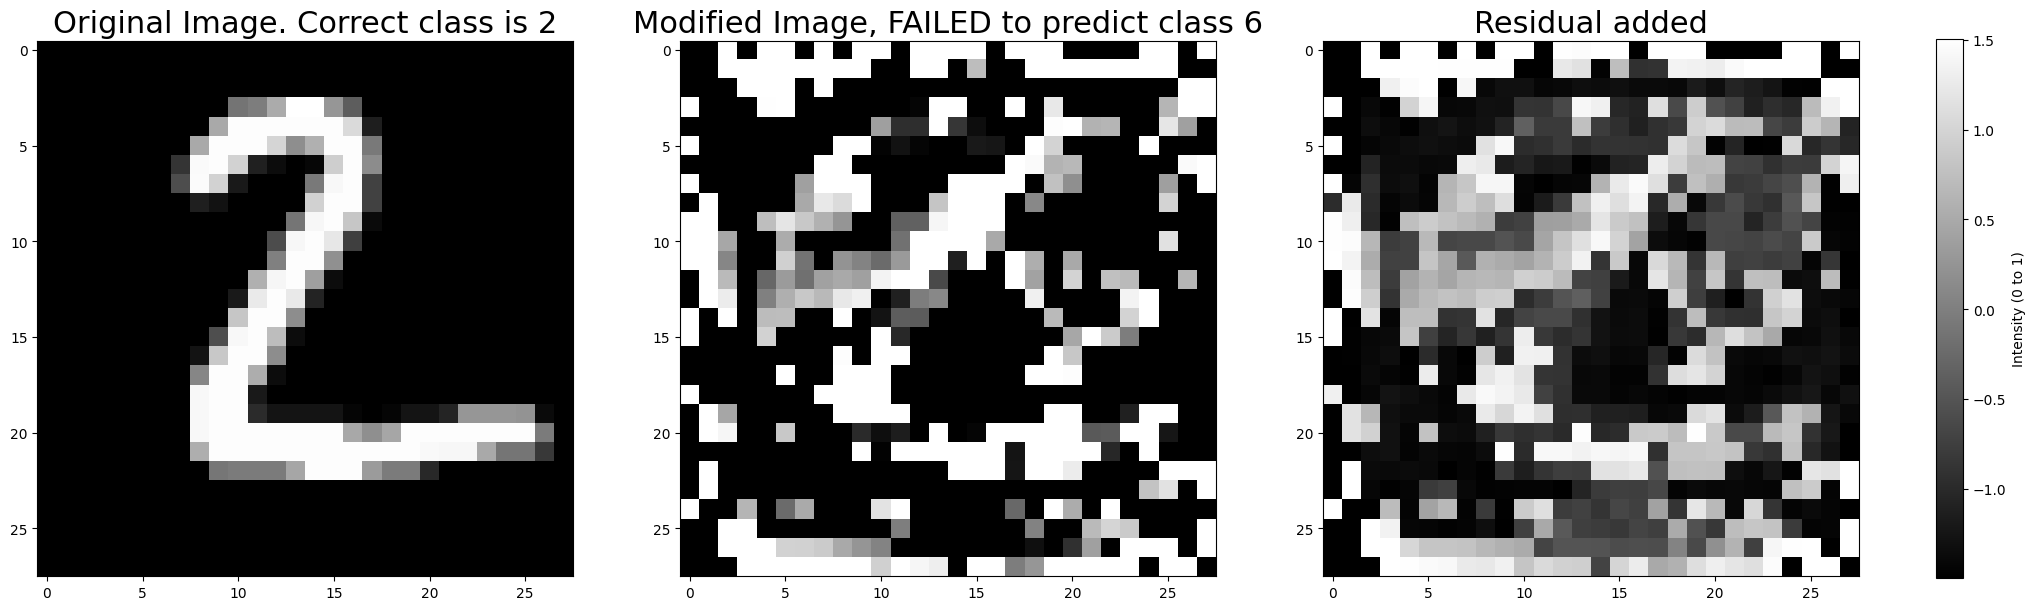

The true class is 2, the new class will be 7
Found c = -0.765645 satisfying f(x + r) = l
Optimization succeeded with c = -0.765645 in 0 iterations
Norm Perturbation |r|: 882.876708984375


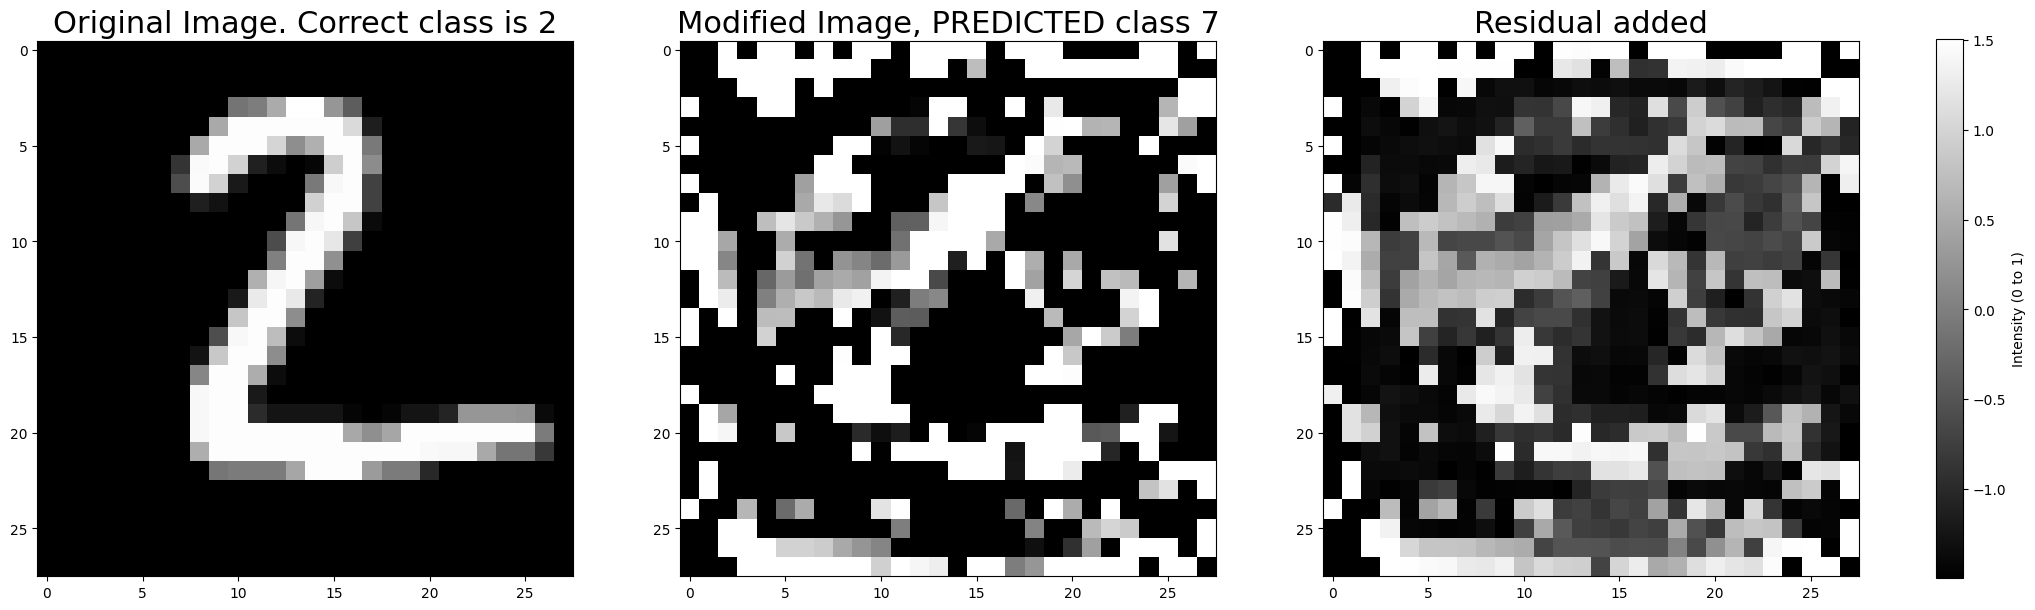

The true class is 2, the new class will be 8
Iter 20/300
Iter 40/300
Iter 60/300
Iter 80/300
Iter 100/300
Iter 120/300
Iter 140/300
Iter 160/300
Iter 180/300
Iter 200/300
Iter 220/300
Iter 240/300
Iter 260/300
Iter 280/300
Iter 300/300
Failed to find c satisfying f(x + r) = l within the maximum limit of iterations.
Norm Perturbation |r|: 1227.0458984375


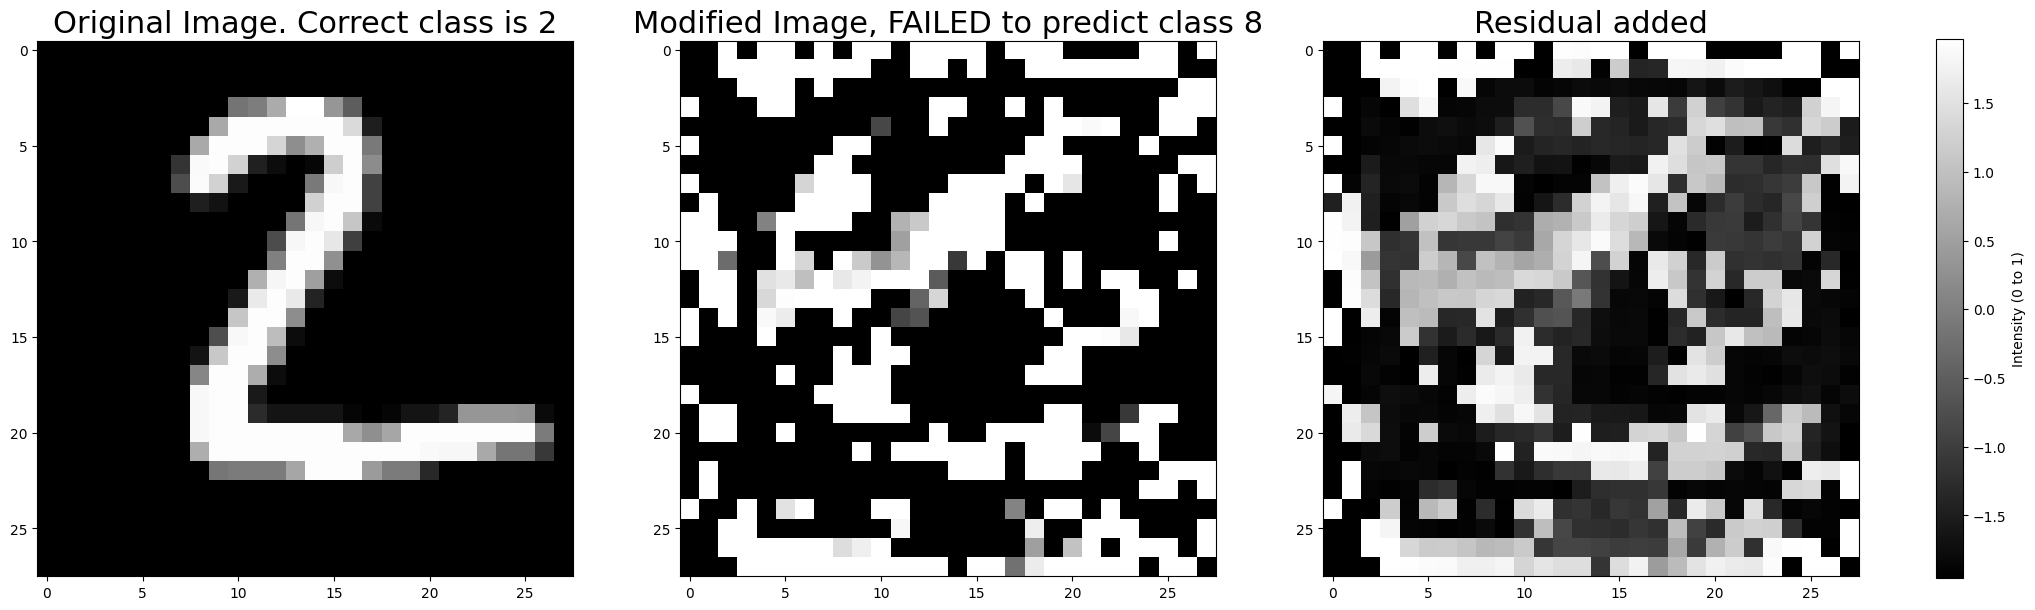

The true class is 2, the new class will be 9
Iter 20/300
Iter 40/300
Iter 60/300
Iter 80/300
Iter 100/300
Iter 120/300
Iter 140/300
Iter 160/300
Iter 180/300
Iter 200/300
Iter 220/300
Iter 240/300
Iter 260/300
Iter 280/300
Iter 300/300
Failed to find c satisfying f(x + r) = l within the maximum limit of iterations.
Norm Perturbation |r|: 1575.039794921875


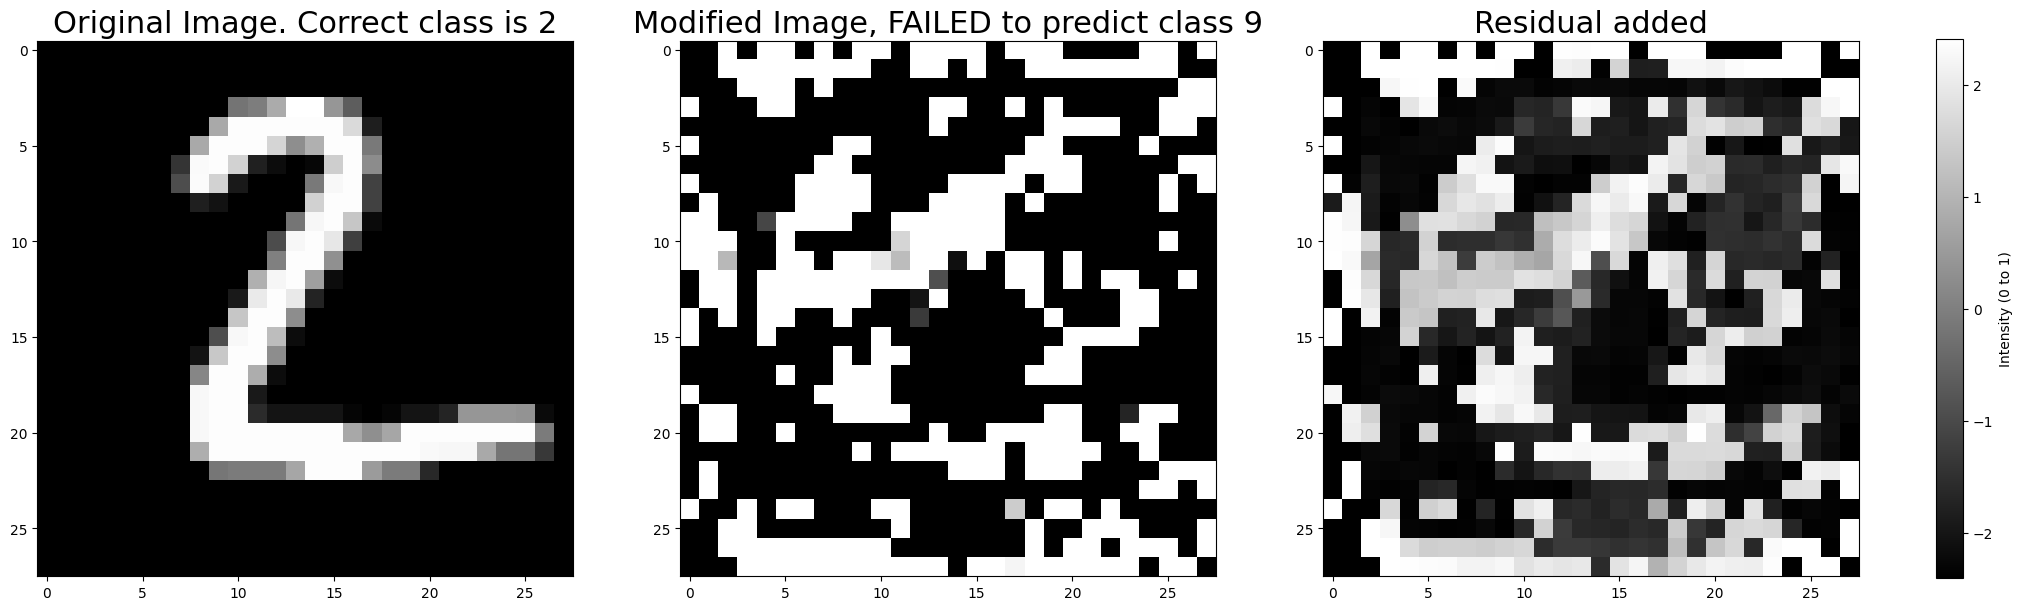

In [297]:
# Initialize r and c as trainable parameters
r = torch.zeros_like(testI, requires_grad=True, device=device)
c = torch.tensor(initial_c, requires_grad=True, device=device)

# Define the optimizer (Adam)
optimizer = optim.Adam([
    {'params': r, 'lr': 0.001},  # Learning rate for 'r'
    {'params': c, 'lr': 0.0005}  # Learning rate for 'c'
])


# Define regularization term
lambda_c = 0.1  # Regularization strength for c 

# Iterate over the target class labels
for o in [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]:
    label = o  # manually chosen target class label different from true one
    l = torch.tensor([label]).to(device)
    l = l.view(1)  # to have a batch size equal to 1 and work with CrossEntropy loss
    print(f"The true class is {testY}, the new class will be {l[0]}")

    # Define the loss function with regularization
    def objective(r, c, x, l):
        # Compute the perturbed image
        x_r = torch.clamp(x + r, 0, 1)  # Ensure x + r ∈ [0, 1]^m
    
        # Compute the prediction for the perturbed image
        pred = model(x_r)
    
        # Compute the loss with the regularization terms
        loss = loss_model(pred, l) + c * torch.norm(r, p=1)  # L1 regularization on r
        loss += lambda_c * torch.norm(c, p=1)  # L2 regularization on c
    
        return loss

    iter = 0
    while iter <= max_iter_search:
        optimizer.zero_grad()

        # Compute the objective loss
        loss = objective(r, c, testI, l)
        loss.backward()

        # Update r and c using Adam
        optimizer.step()

        # Evaluate the condition f(x + r) = l
        with torch.no_grad():
            x_r = torch.clamp(testI + r, 0, 1)  # Ensure x + r ∈ [0, 1]^m
            pred = model(x_r)
            predicted_label = torch.argmax(pred, dim=1)

        # Check if the condition f(x + r) = l is satisfied
        if predicted_label == l:
            print(f"Found c = {c.item():.6f} satisfying f(x + r) = l")
            break
        else:
            iter += 1

        if iter % 20 == 0:
            print(f'Iter {iter}/{max_iter_search}')

    if iter > max_iter_search:
        print("Failed to find c satisfying f(x + r) = l within the maximum limit of iterations.")
        print(f"Norm Perturbation |r|: {torch.norm(r, p=1)}")
        plot_results(testI, r, x_r, testY, l, fail=True)
    else:
        print(f"Optimization succeeded with c = {c.item():.6f} in {iter} iterations")
        print(f"Norm Perturbation |r|: {torch.norm(r, p=1)}")
        plot_results(testI, r, x_r, testY, l, fail=False)


Unfortunately, it did not improve with the regularization term on \( c \).

# Fast Gradient Sign Attack (FGSM)

Another famous method to create adversarial examples is Fast Gradient Sign Attack (FGSM). Let $\theta$ be the parameters of a model, x the input image to the model, y its class and J(θ, x, y) the cost used to train the neural network. Usually, when training a model, we compute the gradient of the cost function with respect to the parameters of the model and update them based on the oppositve (i.e., negative) direction of the gradient to decrease the loss. Here, we can replicate the same reasoning but using the pixel values of the input image instead than the model's parameters and using the gradient direction (i.e., positve) to actually maximize the loss. The idea is thus to modify the pixel values so that the loss is maximized and not minimized. In this way, the perturbation should change the image so that it will be misclassified by the model. In order to keep the changes small, possibly imperceptible to naked eye, we only use the sign of the gradient and multiply it by a small $\epsilon$ value. Mathematically, the adversarial example is estimated using:
 $$x_r =x + \epsilon \text{sign}(\Delta_x J(\theta, x, y))$$

 The gradient can easily be computed using backpropagation (Adam).


[*]` Ian J. Goodfellow, Jonathon Shlens & Christian Szegedy Explaining and harnessing adversarial examples. ICLR. 2015`

Let's load an image.

In [304]:
# Parameters
index=100
testI, testY = mnist_test.__getitem__(index)
X = testI.unsqueeze(0).to(device)
print(X.shape)
X.requires_grad = True # Important for attack
Y=torch.tensor([testY]).to(device)

torch.Size([1, 1, 28, 28])


And plot it.

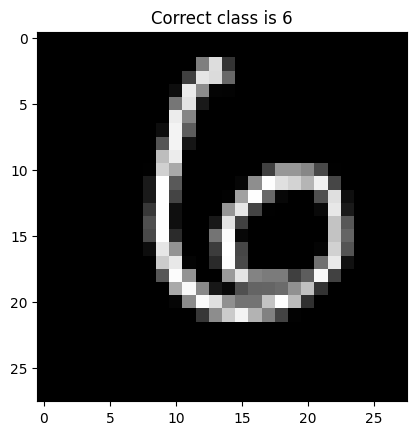

In [305]:
fig = plt.imshow(testI.squeeze(), interpolation='nearest', cmap=plt.cm.gray)
plt.title(f"Correct class is {testY}")
plt.show()

Complete the code by fixing a `eps`value.

Original Class: 6, Perturbed Class: 3
Optimization successful
Norm Perturbation |r|: 195.75


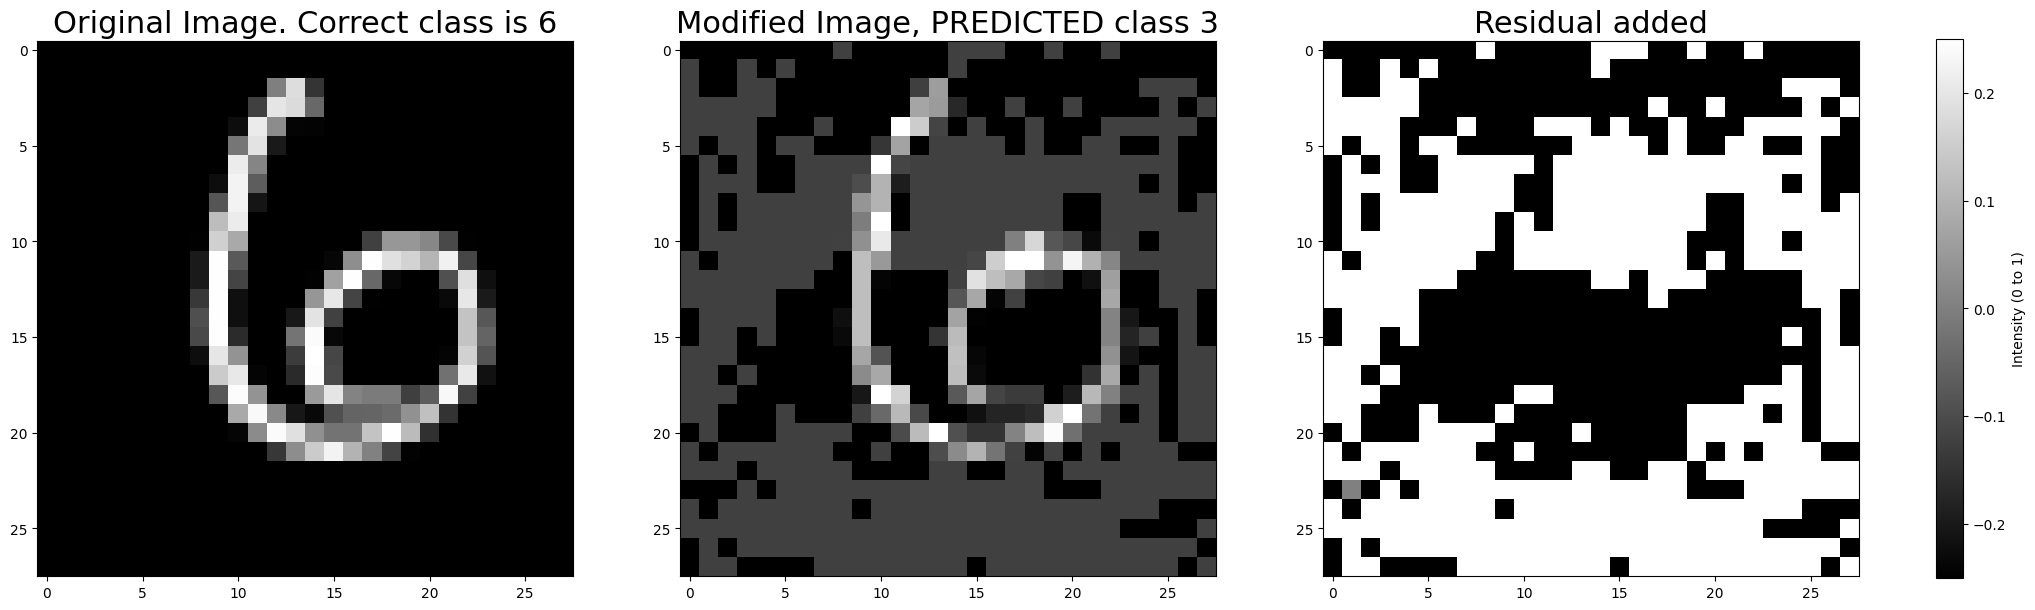

In [311]:

eps = 0.25  # You can adjust this value to control the strength of the attack

# Forward pass of X through the model
pred_original = model(X)
original_class = pred_original.argmax(dim=1)  # Get the predicted class

# Compute loss using cross-entropy
cost = F.cross_entropy(pred_original, Y)

# Zero existing (previous) gradients
model.zero_grad()

# Compute gradients
cost.backward()

# FGSM attack code
# Generate perturbation
r = eps * X.grad.data.sign()
# Create adversarial example
Xr = X + r
# Ensure pixel values stay in valid range [0, 1]
Xr = torch.clamp(Xr, 0, 1)

# Re-classify the perturbed image
pred_perturbed = model(Xr)
perturbed_class = pred_perturbed.argmax(dim=1)

# Print results
print(f"Original Class: {original_class.item()}, Perturbed Class: {perturbed_class.item()}")

r = eps * X.grad.data.sign()
if original_class.item() == perturbed_class.item():
    print(f"Optimization failed")
    print(f"Norm Perturbation |r|: {torch.norm(r, p=1)}")
    plot_results(X, r, Xr, testY, perturbed_class, fail=True)
else:
    print(f"Optimization successful")
    print(f"Norm Perturbation |r|: {torch.norm(r, p=1)}")
    plot_results(X, r, Xr, testY, perturbed_class, fail=False)

Now, to find the best `eps`value, you will code a function and evalute the successful rate for each `eps`value (number of images where an adversarial examples has been successfully created). 

**Question**: What's the best `eps`value ? Are the changes imperceptible to a naked human eye ?


Testing epsilon: 0.01
Epsilon: 0.010, Success Rate: 2.04%


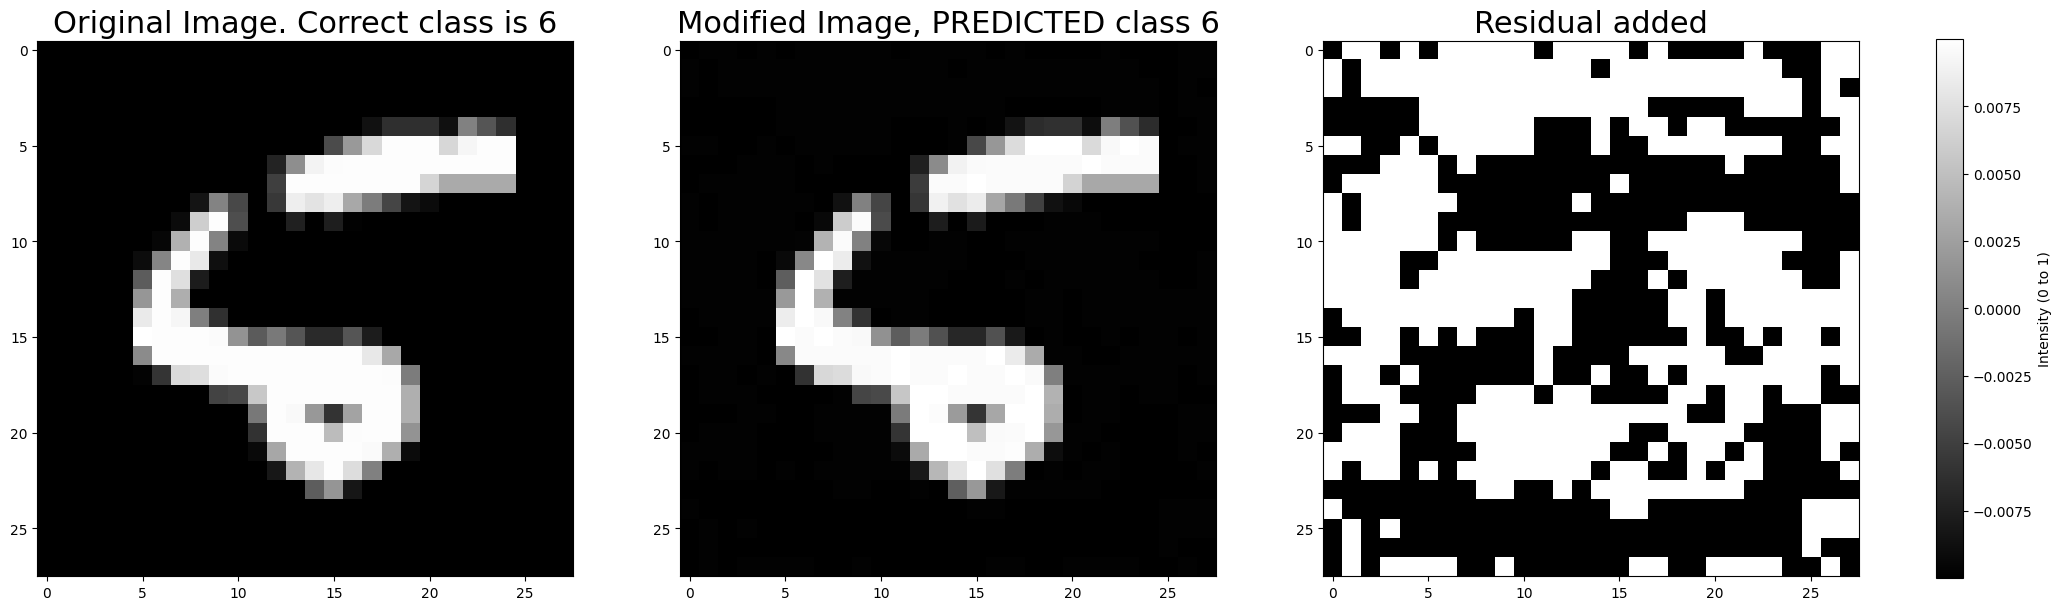


Testing epsilon: 0.05
Epsilon: 0.050, Success Rate: 35.00%


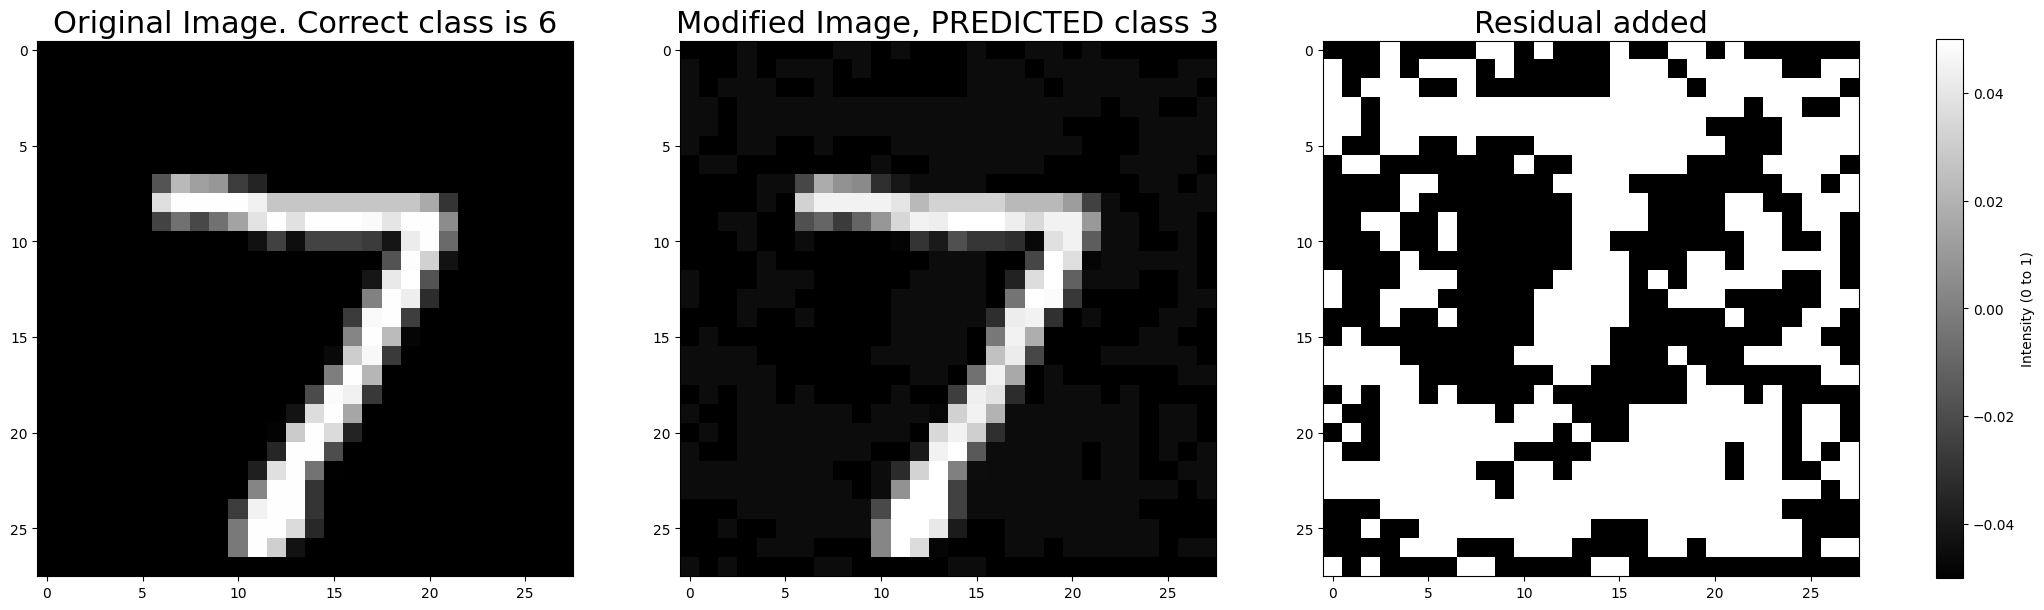


Testing epsilon: 0.1
Epsilon: 0.100, Success Rate: 83.01%


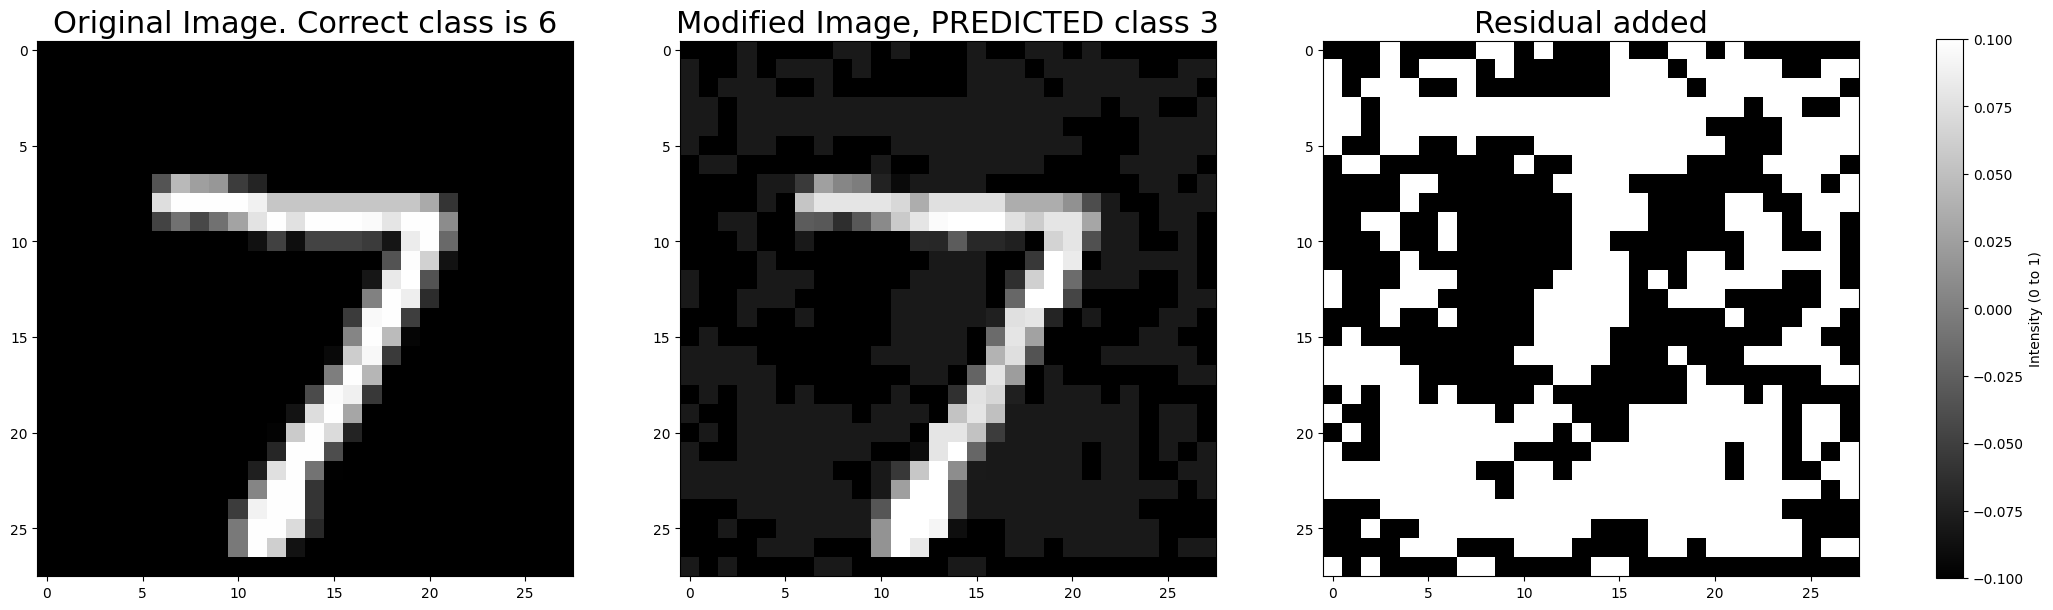


Testing epsilon: 0.15
Epsilon: 0.150, Success Rate: 93.08%


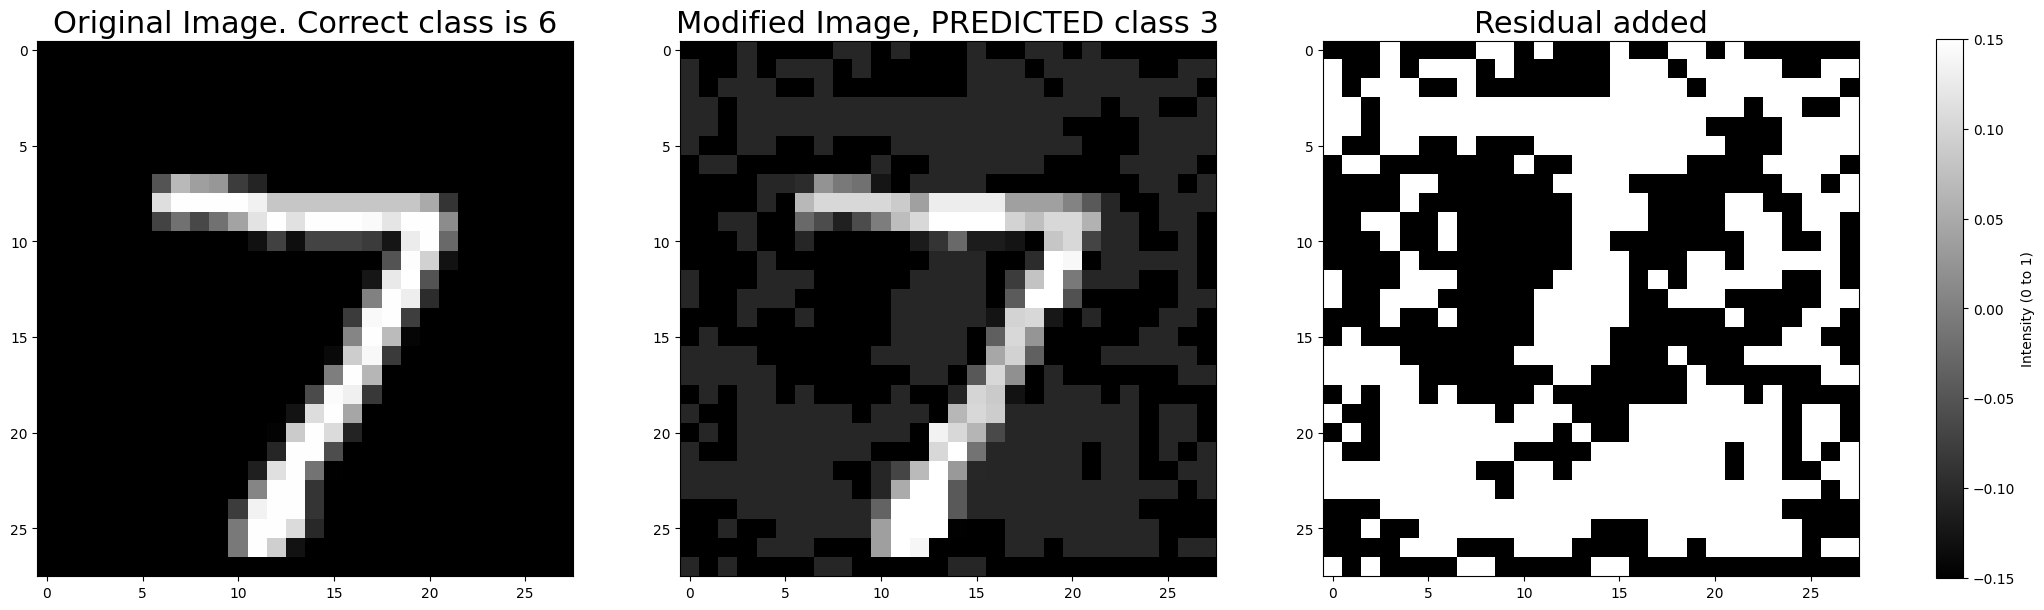


Testing epsilon: 0.2
Epsilon: 0.200, Success Rate: 95.78%


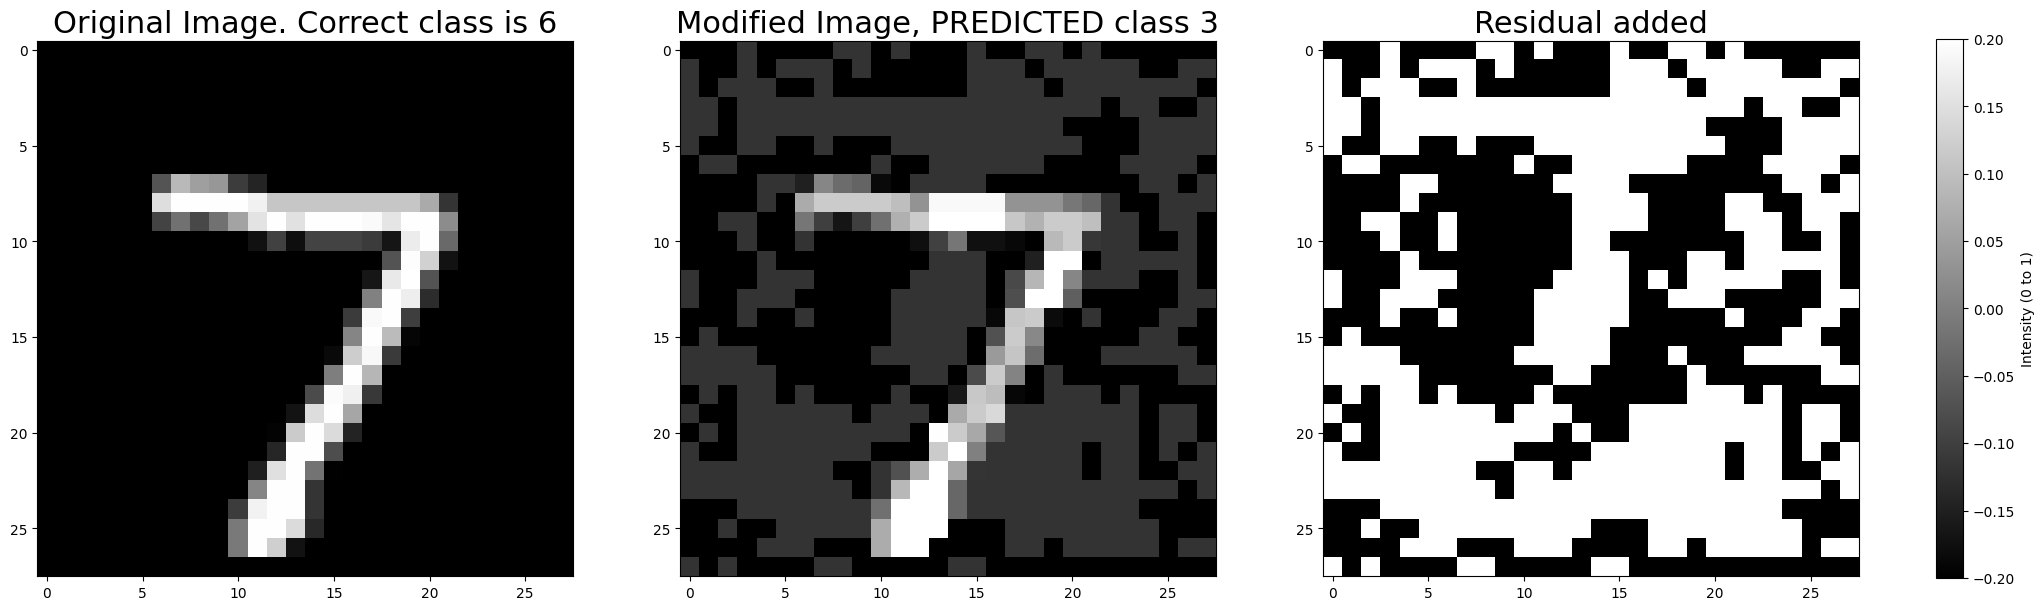


Testing epsilon: 0.25
Epsilon: 0.250, Success Rate: 96.90%


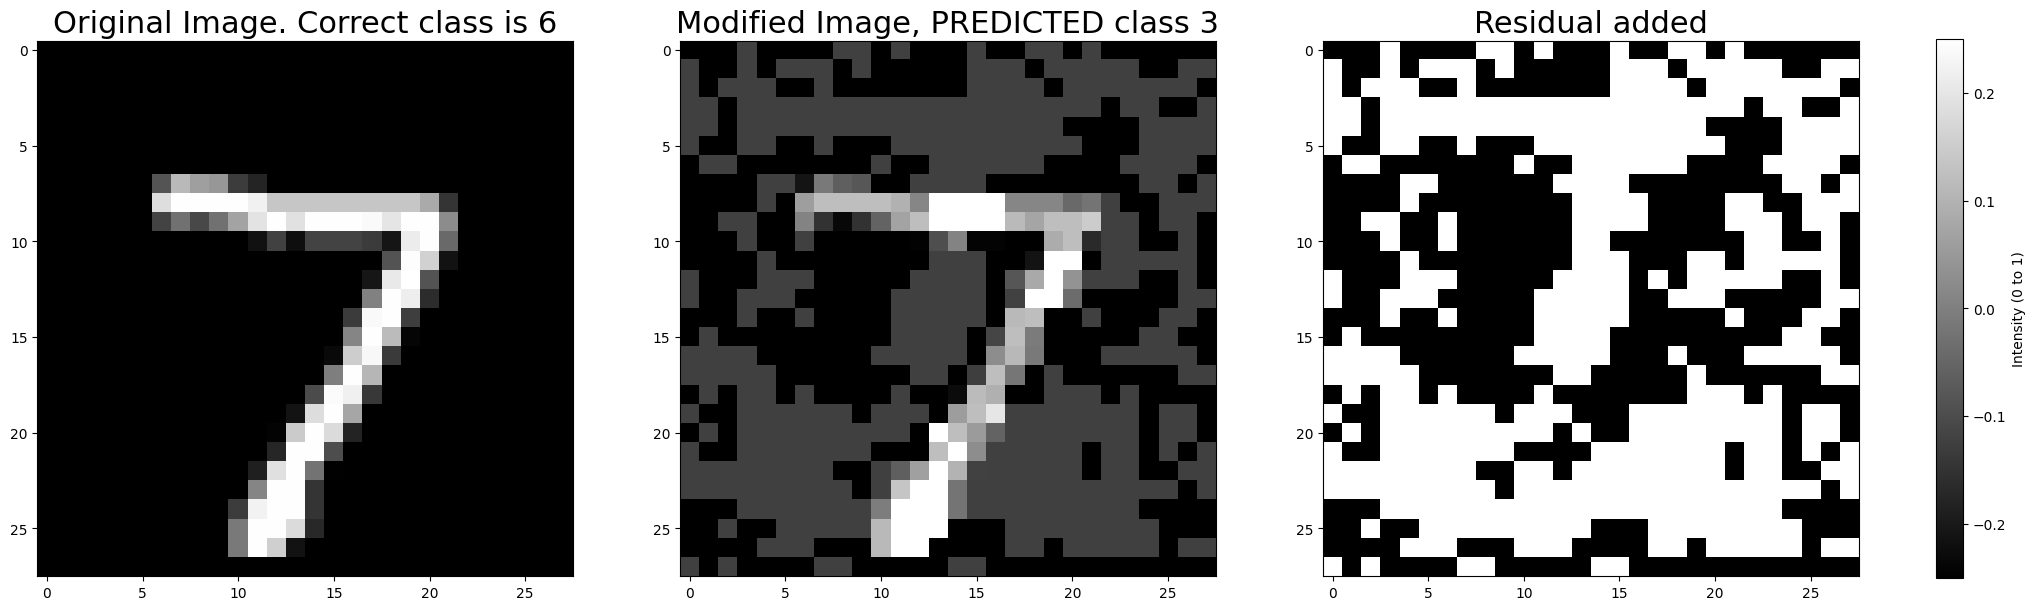


Testing epsilon: 0.3
Epsilon: 0.300, Success Rate: 97.54%


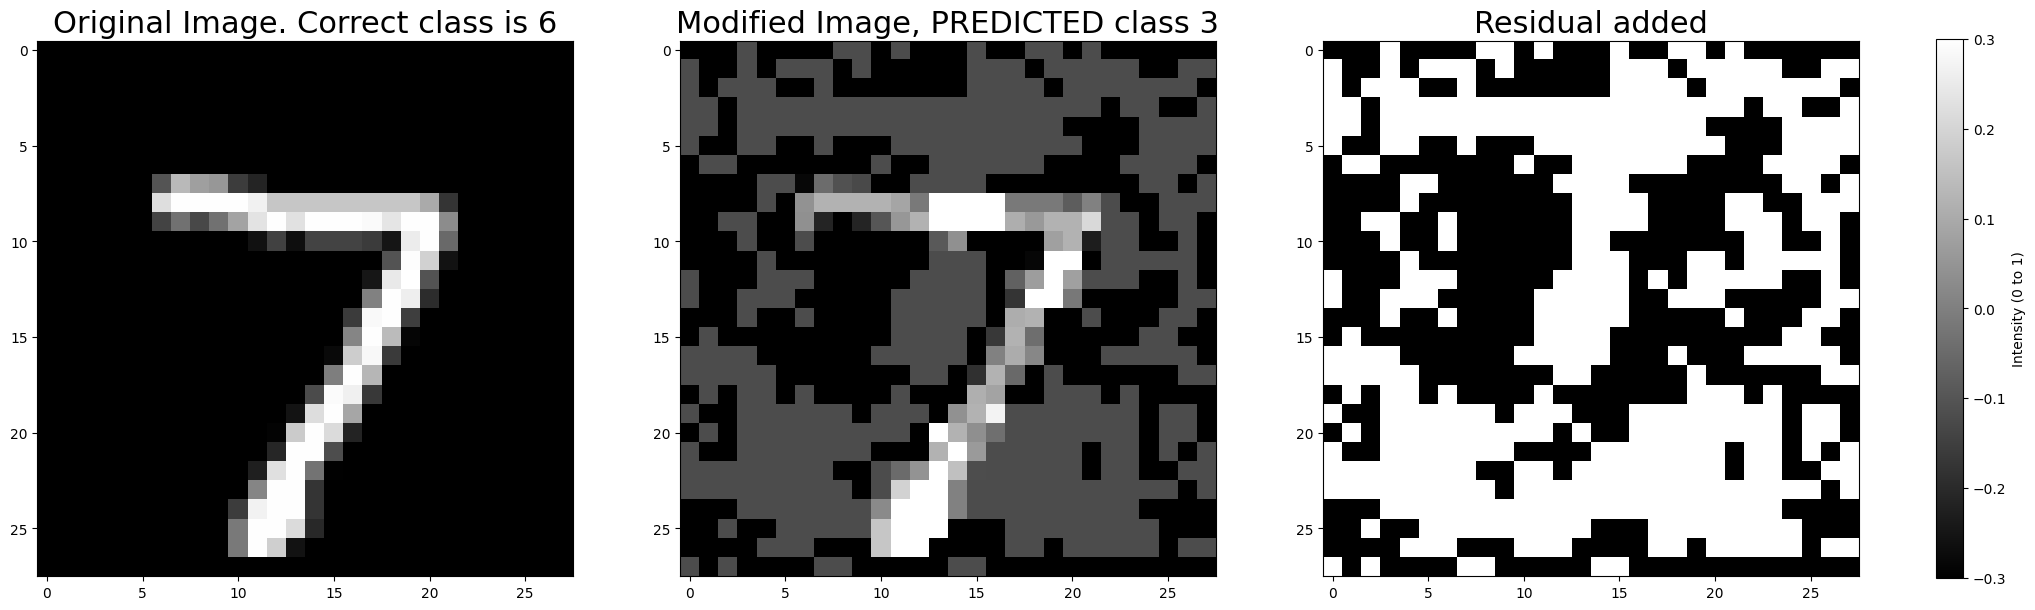

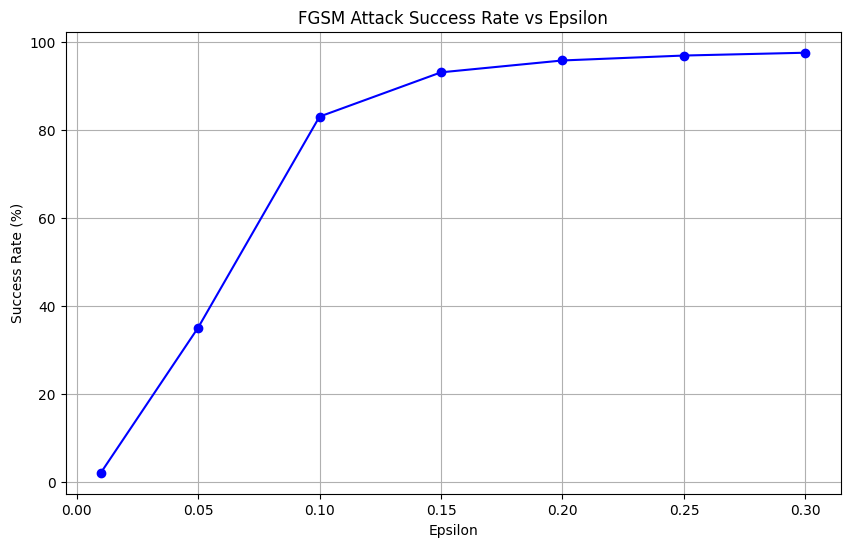


Best epsilon: 0.300 with success rate: 97.54%


In [313]:
def fgsm_attack(X, Y, model, loss_model, eps):
    # Ensure input requires gradient
    X = X.unsqueeze(0).to(device)
    X.requires_grad = True
    Y = torch.tensor([Y]).to(device)
    
    # Forward pass
    pred_original = model(X)
    original_class = pred_original.argmax(dim=1)
    
    # Calculate loss
    cost = loss_model(pred_original, Y)
    
    # Zero gradients
    model.zero_grad()
    
    # Backward pass
    cost.backward()
    
    # Create perturbation
    r = eps * X.grad.data.sign()
    # Generate adversarial example
    Xr = X + r
    # Ensure valid pixel range
    Xr = torch.clamp(Xr, 0, 1)
    
    # Classify perturbed image
    pred_perturbed = model(Xr)
    perturbed_class = pred_perturbed.argmax(dim=1)
    
    return Xr, original_class, perturbed_class, r

# Test different epsilon values
epsilons = [0.01, 0.05, 0.1, 0.15, 0.2, 0.25, 0.3]
results = []

for eps in epsilons:
    print(f"\nTesting epsilon: {eps}")
    adv_examples = []
    success = 0
    total = 0
    
    # Loop over test set
    for X_batch, Y_batch in test_loader:
        for X, Y in zip(X_batch, Y_batch):
            total += 1
            # Generate adversarial example
            Xr, original_class, perturbed_class, r = fgsm_attack(X, Y, model, F.cross_entropy, eps)
            
            # Check if attack was successful
            if original_class.item() != perturbed_class.item():
                success += 1
                # Store the first successful example for each epsilon
                if len(adv_examples) < 1:
                    adv_examples.append((X, Xr.squeeze(), r.squeeze(), original_class, perturbed_class))
    
    # Calculate success rate
    success_rate = (success / total) * 100
    results.append((eps, success_rate))
    print(f"Epsilon: {eps:.3f}, Success Rate: {success_rate:.2f}%")
    
    # Plot one example if available
    if len(adv_examples) > 0:
        X, Xr, r, orig_class, perturbed_class = adv_examples[0]
        # Now we're passing the tensor directly instead of the integer value
        plot_results(X.unsqueeze(0), r.unsqueeze(0), Xr.unsqueeze(0), Y, perturbed_class, fail=(orig_class.item() == perturbed_class.item()))

# Plot success rates
plt.figure(figsize=(10, 6))
eps_values, success_rates = zip(*results)
plt.plot(eps_values, success_rates, 'bo-')
plt.xlabel('Epsilon')
plt.ylabel('Success Rate (%)')
plt.title('FGSM Attack Success Rate vs Epsilon')
plt.grid(True)
plt.show()

# Find best epsilon (highest success rate)
best_eps, best_rate = max(results, key=lambda x: x[1])
print(f"\nBest epsilon: {best_eps:.3f} with success rate: {best_rate:.2f}%")


- Changes with epsilon ≤ 0.1 are challenging to perceive with the naked eye, resulting in a low success rate.
- Changes with 0.1 < epsilon ≤ 0.15 are somewhat noticeable upon close inspection and demonstrate a good success rate.
- Changes with epsilon > 0.15 are more apparent and are associated with a higher success rate.
